# 06_Reinforcement_Learning_Flight_Optimization.ipynb

## Havacılık Veri Bilimcileri için Optimizasyon

### Takviyeli Öğrenme ile Uçuş Optimizasyonu

In [39]:
# Gerekli kütüphaneleri içe aktarın
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

# Matplotlib ve Seaborn için görsel ayarlar
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Necessary libraries imported and plotting settings applied.")

Necessary libraries imported and plotting settings applied.


## Bölüm 1 – Giriş

Havacılıkta uçuş operasyonlarını optimize etmek, yakıt tüketimini azaltmak, uçuş süresini kısaltmak ve emisyonları en aza indirmek gibi hem çevresel hem de ekonomik açıdan büyük faydalar sağlar. Geleneksel optimizasyon yöntemleri, belirli koşullar altında oldukça etkili olsa da, genellikle karmaşık, dinamik ve belirsiz ortamlarda yetersiz kalabilir.

### Neden Geleneksel Optimizasyon Yetersiz Kalabilir?

*   **Dinamik Ortamlar:** Hava koşulları, trafik yoğunluğu ve uçağın ağırlığı gibi faktörler sürekli değişir. Geleneksel yöntemler genellikle bu tür dinamik değişimlere gerçek zamanlı olarak adapte olmakta zorlanır.
*   **Belirsizlik:** Uçuş sırasında ortaya çıkabilecek öngörülemeyen olaylar (türbülans, hava sahası kısıtlamaları vb.) geleneksel, önceden tanımlanmış çözümlerin etkinliğini azaltır.
*   **Karmaşık Etkileşimler:** Uçak performansı üzerinde birçok değişken (irtifa, hız, motor gücü, yakıt tüketimi) birbirini karmaşık şekillerde etkiler. Bu etkileşimlerin tam olarak modellenmesi ve analitik olarak çözülmesi güçtür..

### Uçuş Optimizasyonunu Ardışık Karar Problemi Yapan Nedir?

Bir uçağın kalkıştan inişe kadar olan yolculuğu, bir dizi ardışık karardan oluşur. Her bir kararın (örneğin, irtifa değiştirme, hızı ayarlama) mevcut durumu (yakıt seviyesi, konum, hız) üzerinde anlık bir etkisi vardır ve aynı zamanda gelecekteki olası durumları ve alınabilecek kararları da etkiler. Bu, bir satranç oyununa benzer: şimdiki hamle, oyunun gidişatını belirler ve gelecekteki hamleler için seçenekleri şekillendirir.

### Takviyeli Öğrenmenin Faydaları

Takviyeli Öğrenme (Reinforcement Learning - RL), bir ajanın bir ortamda etkileşim kurarak ve deneme yanılma yoluyla en uygun eylemleri öğrenmesini sağlayan güçlü bir yapay zeka paradigmaları kümesidir. Uçuş optimizasyonu bağlamında RL:

*   **Adaptasyon Yeteneği:** Ajan, değişen koşullara (hava, trafik) adapte olarak dinamik optimizasyon kararları alabilir.
*   **Belirsizlikle Başa Çıkma:** Ortamın tam bir modeline ihtiyaç duymadan, deneyim yoluyla belirsizlikleri yönetmeyi öğrenir.
*   **Öğrenilen Sezgiler:** Uzun vadeli hedeflere (minimum yakıt, minimum süre) ulaşmak için kısa vadeli kararların nasıl optimize edileceğini öğrenir.

### Tahmin ve Karar Verme Arasındaki Fark

*   **Tahmin (Prediction):** Genellikle gelecekte ne olacağını belirlemekle ilgilidir. Örneğin, "Belirli bir irtifada ve hızda yakıt tüketimi ne kadar olacak?" sorusuna cevap arar.
*   **Karar Verme (Decision Making):** Belirli bir hedefe ulaşmak için hangi eylemin yapılması gerektiğini belirlemekle ilgilidir. Örneğin, "Yakıtı minimize etmek için şimdi irtifa mı değiştirmeliyim yoksa hızı mı ayarlamalıyım?" sorusuna cevap arar. RL, ajanları en iyi kararları almaları için eğiterek tahminin ötesine geçer.

### Optimizasyondan Öğrenmeye

#### Klasik Optimizasyon → En İyi Çözüm

Klasik optimizasyon teknikleri (örneğin, kalkülüs tabanlı yöntemler, doğrusal programlama), iyi tanımlanmış bir amaç fonksiyonu ve kısıtlamalar dahilinde **tek bir en iyi çözümü** bulmaya çalışır. Bu çözüm, belirli bir durum için idealdir ancak koşullar değiştiğinde yeniden hesaplanması gerekebilir.

#### Takviyeli Öğrenme → En İyi Politika

Takviyeli öğrenme ise, **en iyi politikayı** öğrenmeye odaklanır. Politika, bir ajanın karşılaştığı her olası durumda hangi eylemi yapması gerektiğini belirleyen bir haritalamadır. Bu, ajanın dinamik olarak değişen ortamlara genelleştirilebilen ve adapte olabilen kararlar almasını sağlar. Bir RL ajanı, farklı durumlar için en uygun eylem dizisini (politikayı) öğrenerek, sürekli olarak 'en iyi çözümü' aramaktansa, 'en iyi kararı' verme yeteneğini kazanır.

## Bölüm 2 – Uçuş Optimizasyon Problemi

Uçuş optimizasyonu problemini, bir uçağın belirli bir başlangıç noktasından varış noktasına kadar olan yolculuğu olarak basitleştirilmiş bir misyon üzerinden tanımlayalım.

### Basitleştirilmiş Uçak Misyonu

Bir uçağın hedefi, belirli bir mesafeyi en uygun şekilde kat etmektir. Misyonu kolaylaştırmak için ana uçuş fazlarını tanımlıyoruz:

#### Misyon Fazları:

*   **Tırmanma (Climb):** Kalkıştan sonra uçağın seyir irtifasına yükseldiği faz.
*   **Seyir (Cruise):** Uçağın sabit bir irtifada ve genellikle sabit bir hızda yol kat ettiği faz.
*   **İniş (Descent):** Uçağın varış noktasına yaklaşırken irtifa kaybettiği ve iniş için hazırlandığı faz.

#### Durum Değişkenleri (State Variables):

Ajanın ortamdaki mevcut durumunu tanımlayan ve karar verme sürecini etkileyen değişkenlerdir:

*   **İrtifa (Altitude):** Uçağın deniz seviyesinden yüksekliği (metre veya fit).
*   **Uçak Ağırlığı (Aircraft Weight):** Uçağın kalan yakıt dahil toplam ağırlığı (kg).
*   **Kalan Yakıt (Remaining Fuel):** Uçakta kalan yakıt miktarı (kg).
*   **Hedefe Kalan Mesafe (Distance To Destination):** Varış noktasına kalan doğrusal mesafe (km).

#### Eylem Değişkenleri (Action Variables):

Ajanın her zaman adımında alabileceği ayrı kararları temsil eder:

*   **Tırmanma (Climb):** İrtifayı artırma.
*   **İniş (Descend):** İrtifayı azaltma.
*   **İrtifayı Koruma (Maintain Altitude):** Mevcut irtifada kalma.
*   **Hızı Artırma (Increase Speed):** İleri hızı artırma.
*   **Hızı Azaltma (Reduce Speed):** İleri hızı azaltma.

#### Amaçlar (Objectives):

Optimizasyon probleminin hedefleri, ajanın öğrenme sürecini yönlendiren kriterlerdir. Genellikle birleştirilmiş bir ödül fonksiyonu olarak formüle edilirler:

*   **Yakıt Tüketimini Minimize Etme (Minimize Fuel Burn):** En az yakıtla misyonu tamamlama.
*   **Uçuş Süresini Minimize Etme (Minimize Flight Time):** En kısa sürede varış noktasına ulaşma.
*   **Misyonu Başarıyla Tamamlama (Successfully Complete Mission):** Belirlenen hedefe ulaşma (örneğin, varış noktasına güvenli bir şekilde inme).

### Optimizasyon Probleminin Matematiksel Gösterimi

Uçuş optimizasyon problemini bir **Markov Karar Süreci (MDP)** olarak formüle edebiliriz. Bir MDP, ajan ile ortam arasındaki etkileşimi matematiksel olarak modellemek için kullanılan bir çerçevedir. Bu, Takviyeli Öğrenmenin temelini oluşturur.

Bir durum $s_t$, bir eylem $a_t$ ve bir ödül $r_t$ ile tanımlanır.

**Durum (State):** $s_t = (altitude_t, weight_t, fuel_t, distance_{to_dest_t})$

**Eylem (Action):** $a_t \in \{\text{Climb, Descend, Maintain Altitude, Increase Speed, Reduce Speed}\}$

**Geçiş Fonksiyonu (Transition Function):** $P(s_{t+1}|s_t, a_t)$

Bu fonksiyon, mevcut durum $s_t$ ve alınan eylem $a_t$ göz önüne alındığında, bir sonraki durum $s_{t+1}$'e geçme olasılığını tanımlar. Basitleştirilmiş modelimizde deterministik bir geçişi varsayabiliriz: $s_{t+1} = f(s_t, a_t)$.

**Ödül Fonksiyonu (Reward Function):** $R(s_t, a_t, s_{t+1})$

Bu fonksiyon, $s_t$ durumunda $a_t$ eylemini alıp $s_{t+1}$ durumuna geçildiğinde ajana verilen anlık ödülü tanımlar. Amaç fonksiyonlarımıza göre ödül şöyle olabilir:

$R(s_t, a_t, s_{t+1}) = - \alpha \cdot \Delta fuel - \beta \cdot \Delta time + \gamma \cdot \text{mission_completion_bonus}$

Burada:
*   $\Delta fuel$: Yakıt tüketimi (negatif terim, minimize etmek için)
*   $\Delta time$: Geçen süre (negatif terim, minimize etmek için)
*   $\text{mission_completion_bonus}$: Misyon başarıyla tamamlandığında verilen pozitif ödül
*   $\alpha, \beta, \gamma$: Amaçların göreceli önemini dengeleyen ağırlık faktörleri.

**Hedef (Goal):** Ajanın, uzun vadeli beklenen kümülatif ödülü maksimize edecek bir politika $\pi(a|s)$ öğrenmesidir:

$\max_{\pi} E[\sum_{k=0}^{T} \gamma^k R(s_k, a_k, s_{k+1})]$

Burada:
*   $\gamma$: İndirim faktörü (gelecekteki ödüllerin şimdiki değerini azaltır)
*   $T$: Misyonun veya bölümün sonu

### Neden Ardışık Karar Problemi?

Bu, bir ardışık karar problemidir çünkü:

1.  **Her Eylem Geleceği Etkiler:** Herhangi bir zaman adımında alınan bir eylem (örneğin, hız artırma), sadece anlık yakıt tüketimi veya hız üzerinde değil, aynı zamanda uçağın gelecekteki konumunu, kalan yakıtını ve potansiyel olarak alabileceği diğer eylemleri de etkiler.
2.  **Kararlar Birbirine Bağımlıdır:** Bir tırmanma eylemi, daha yüksek irtifada seyir için daha az yakıt tüketimine yol açabilirken, bu da iniş fazındaki kararları etkileyecektir. Optimal bir uçuş yolu, bir dizi birbirine bağlı kararın sonucu olarak ortaya çıkar.
3.  **Uzun Vadeli Hedefler:** Amaç, anlık ödülleri değil, misyonun tamamı boyunca kümülatif ödülü maksimize etmektir. Bu, ajanın gelecekteki sonuçları dikkate alarak kararlar almasını gerektirir, bu da ardışık planlama ve karar verme ile karakterize edilen bir özelliktir.

## Bölüm 3 – Ortam Modeli

Gerçek bir uçuş ortamının karmaşıklığını modellemek çok zordur. Takviyeli öğrenme ajanı geliştirmek için basitleştirilmiş ancak yeterince temsili bir model oluşturacağız. Bu model, ajanımızın kararlarının temel fiziksel sonuçlarını anlamasına olanak tanıyacak.

### Varsayımlar ve Basitleştirmeler

Modelimizi oluştururken aşağıdaki basitleştirmeleri ve varsayımları yapıyoruz:

*   **Basit Aerodinamik:** Kaldırma ve sürükleme kuvvetleri için basitleştirilmiş denklemler kullanacağız. Gerçek aerodinamik karmaşıklıklar göz ardı edilecektir.
*   **Sabit Güç Ayarları:** Her hız ve irtifa seviyesi için sabit bir itme gücü ayarının mevcut olduğunu varsayıyoruz. Motor performansı detaylarına girmiyoruz.
*   **Düz Dünya Modeli:** Dünya'nın yuvarlaklığı ve Coriolis etkisi gibi faktörler göz ardı edilir.
*   **Anlık Eylem Etkisi:** Her zaman adımında alınan eylemin (örn. irtifa değiştirme) anlık olarak gerçekleştiği varsayılır. Geçiş dinamikleri basitleştirilmiştir.
*   **Tek Tip Yakıt Tüketimi:** Belirli bir irtifa ve hız için yakıt tüketim oranının sabit olduğunu varsayacağız.
*   **Rüzgarsız Ortam:** Rüzgarın etkisi modelimize dahil edilmeyecektir.
*   **Ayrık Zaman Adımları:** Sürekli zaman yerine ayrık zaman adımlarında ilerleyeceğiz.
*   **Varsayılan Uçak Parametreleri:** Uçak tipi için genel kabul görmüş bazı sabit parametreler kullanacağız.

### Çevre Parametreleri ve Uçak Sabitleri

Çevre modelimizde kullanacağımız bazı temel parametreler ve bir uçağın genel özelliklerini temsil eden sabitler:

In [40]:
# Environment parameters and aircraft constants
GRAVITY = 9.81  # m/s^2
AIR_DENSITY_SEA_LEVEL = 1.225  # kg/m^3
TEMP_SEA_LEVEL = 288.15  # Kelvin
TEMP_LAPSE_RATE = 0.0065  # K/m
GAS_CONSTANT = 287.05  # J/(kg*K)

# Simplified aircraft parameters (for a medium-sized aircraft, e.g., Boeing 737 class)
# These are highly simplified and for illustrative purposes only.
REFERENCE_AREA = 125.0  # m^2 (wing area)
DRAG_COEFFICIENT_0 = 0.025  # Zero-lift drag coefficient
DRAG_COEFFICIENT_K = 0.045  # Induced drag coefficient factor (related to aspect ratio and Oswald efficiency)
FUEL_BURN_FACTOR = 0.00015  # Simplified factor for fuel consumption per unit thrust/power
MAX_THRUST = 150000.0  # Newtons (total for all engines, simplified)

# Mission parameters
INITIAL_AIRCRAFT_WEIGHT = 70000.0  # kg (including initial fuel)
INITIAL_FUEL_WEIGHT = 20000.0  # kg
MAX_ALTITUDE = 12000.0  # meters
MIN_ALTITUDE = 150.0  # meters (above ground for safety)
MAX_SPEED = 250.0  # m/s (approx 0.75 Mach at cruise altitude)
MIN_SPEED = 80.0  # m/s (stall speed for simplified model)

print("Environment parameters and aircraft constants defined.")

Environment parameters and aircraft constants defined.


### Yeniden Kullanılabilir Fonksiyonlar

Uçuş dinamiklerini modellemek için temel fonksiyonları tanımlayacağız. Bu fonksiyonlar, uçağın mevcut durumuna ve alınan eylemlere göre bir sonraki durumunu ve anlık yakıt tüketimini hesaplayacaktır.

In [41]:
def get_air_density(altitude: float) -> float:
    """
    Calculate air density at a given altitude using the International Standard Atmosphere (ISA) model.
    Assumes troposphere conditions up to 11,000 meters.

    Args:
        altitude (float): Altitude in meters.

    Returns:
        float: Air density in kg/m^3.
    """
    if altitude < 0: # Ensure altitude is non-negative
        altitude = 0.0

    # Only considering troposphere for simplicity
    temperature_at_altitude = TEMP_SEA_LEVEL - (TEMP_LAPSE_RATE * altitude)

    # Pressure ratio calculation for simplicity (assuming constant lapse rate)
    # More accurate would involve specific pressure calculation, but this is a simplification.
    pressure_ratio = (temperature_at_altitude / TEMP_SEA_LEVEL)**(GRAVITY / (TEMP_LAPSE_RATE * GAS_CONSTANT))

    # Density calculation
    density = AIR_DENSITY_SEA_LEVEL * pressure_ratio * (TEMP_SEA_LEVEL / temperature_at_altitude)
    return density

def calculate_drag(speed: float, altitude: float, aircraft_weight: float) -> float:
    """
    Calculate total drag force on the aircraft.
    Drag = 0.5 * rho * V^2 * S * Cd
    Cd = Cd0 + K * Cl^2, where Cl = (2 * Weight * g) / (rho * V^2 * S)

    Args:
        speed (float): Aircraft true airspeed in m/s.
        altitude (float): Altitude in meters.
        aircraft_weight (float): Current aircraft total weight in kg.

    Returns:
        float: Total drag force in Newtons.
    """
    if speed <= 0:
        return 0.0 # No drag if not moving

    rho = get_air_density(altitude)

    # Lift Coefficient (Cl) required to maintain level flight (approximate)
    # Assuming lift equals weight in level flight or near-level flight conditions.
    # This is a simplification; actual Cl depends on angle of attack.
    lift_coefficient = (2 * aircraft_weight * GRAVITY) / (rho * speed**2 * REFERENCE_AREA)

    # Total Drag Coefficient (Cd)
    total_drag_coefficient = DRAG_COEFFICIENT_0 + DRAG_COEFFICIENT_K * lift_coefficient**2

    # Total Drag Force
    drag_force = 0.5 * rho * speed**2 * REFERENCE_AREA * total_drag_coefficient
    return drag_force

def calculate_fuel_burn_rate(speed: float, altitude: float, aircraft_weight: float) -> float:
    """
    Calculate the instantaneous fuel burn rate.
    Simplified model: Fuel burn is proportional to the required thrust (equal to drag in steady flight).

    Args:
        speed (float): Aircraft true airspeed in m/s.
        altitude (float): Altitude in meters.
        aircraft_weight (float): Current aircraft total weight in kg.

    Returns:
        float: Fuel burn rate in kg/second.
    """
    required_thrust = calculate_drag(speed, altitude, aircraft_weight)
    # Ensure required thrust does not exceed max thrust for realistic fuel burn
    required_thrust = min(required_thrust, MAX_THRUST)
    fuel_burn_rate = required_thrust * FUEL_BURN_FACTOR
    return fuel_burn_rate


def update_flight_state(current_state: tuple, action: str, time_step: float) -> tuple:
    """
    Updates the flight state based on the taken action over a time step.

    Args:
        current_state (tuple): (altitude, aircraft_weight, remaining_fuel, distance_to_destination, current_speed, total_distance_flown, total_time_elapsed).
        action (str): One of the defined action variables.
        time_step (float): Duration of the time step in seconds.

    Returns:
        tuple: new_state (altitude, aircraft_weight, remaining_fuel, distance_to_destination, current_speed, total_distance_flown, total_time_elapsed),
               fuel_consumed (kg),
               distance_covered (m)
    """
    altitude, aircraft_weight, remaining_fuel, dist_to_dest, current_speed, total_dist_flown, total_time_elapsed = current_state

    # Default changes based on action
    delta_altitude = 0.0
    delta_speed = 0.0

    # Define action effects (simplified)
    if action == 'Climb':
        delta_altitude = 10.0 * time_step  # 10 m/s climb rate
    elif action == 'Descend':
        delta_altitude = -5.0 * time_step # 5 m/s descent rate
    elif action == 'Increase Speed':
        delta_speed = 5.0 # m/s increase
    elif action == 'Reduce Speed':
        delta_speed = -5.0 # m/s decrease

    # Update speed
    new_speed = current_speed + delta_speed
    new_speed = max(MIN_SPEED, min(new_speed, MAX_SPEED))

    # Update altitude
    new_altitude = altitude + delta_altitude
    new_altitude = max(MIN_ALTITUDE, min(new_altitude, MAX_ALTITUDE))

    # Calculate fuel burn for the current time step based on *new* (or current) state
    fuel_burn_rate = calculate_fuel_burn_rate(new_speed, new_altitude, aircraft_weight)
    fuel_consumed = fuel_burn_rate * time_step

    # Update fuel and weight
    new_remaining_fuel = remaining_fuel - fuel_consumed
    if new_remaining_fuel < 0:
        fuel_consumed += new_remaining_fuel # only consume what's left
        new_remaining_fuel = 0.0
        # This can be considered a 'mission failure' in the reward system

    new_aircraft_weight = INITIAL_AIRCRAFT_WEIGHT - (INITIAL_FUEL_WEIGHT - new_remaining_fuel)

    # Distance traveled
    distance_covered = new_speed * time_step # Assuming speed is roughly constant over small time_step
    new_dist_to_dest = dist_to_dest - distance_covered
    if new_dist_to_dest < 0: # Cannot go past destination
        distance_covered += new_dist_to_dest
        new_dist_to_dest = 0.0

    new_total_dist_flown = total_dist_flown + distance_covered
    new_total_time_elapsed = total_time_elapsed + time_step

    new_state = (new_altitude, new_aircraft_weight, new_remaining_fuel,
                 new_dist_to_dest, new_speed, new_total_dist_flown, new_total_time_elapsed)

    return new_state, fuel_consumed, distance_covered


print("Reusable functions for flight dynamics defined.")

Reusable functions for flight dynamics defined.


### Örnek Simülasyonlar

Şimdi tanımladığımız fonksiyonları kullanarak basit bir uçuş senaryosunu simüle edelim. Bu, modelimizin nasıl çalıştığını ve durum değişkenlerinin zaman içinde nasıl değiştiğini görmemizi sağlayacaktır.


Running sample simulation for 500 km mission over 1000 steps...
Mission ended at step 51. Remaining distance: 32000.00m, Remaining fuel: 0.00kg
Sample simulation results:
   step action  altitude_m  aircraft_weight_kg  remaining_fuel_kg  \
0     0  Climb      1000.0        70000.000000       20000.000000   
1     1  Climb      1600.0        69538.910113       19538.910113   
2     2  Climb      2200.0        69090.949310       19090.949310   
3     3  Climb      2800.0        68654.774816       18654.774816   
4     4  Climb      3400.0        68229.034177       18229.034177   

   distance_to_dest_m  current_speed_m_s  total_distance_flown_m  \
0            500000.0              150.0                     0.0   
1            491000.0              150.0                  9000.0   
2            482000.0              150.0                 18000.0   
3            473000.0              150.0                 27000.0   
4            464000.0              150.0                 36000.0   

   t

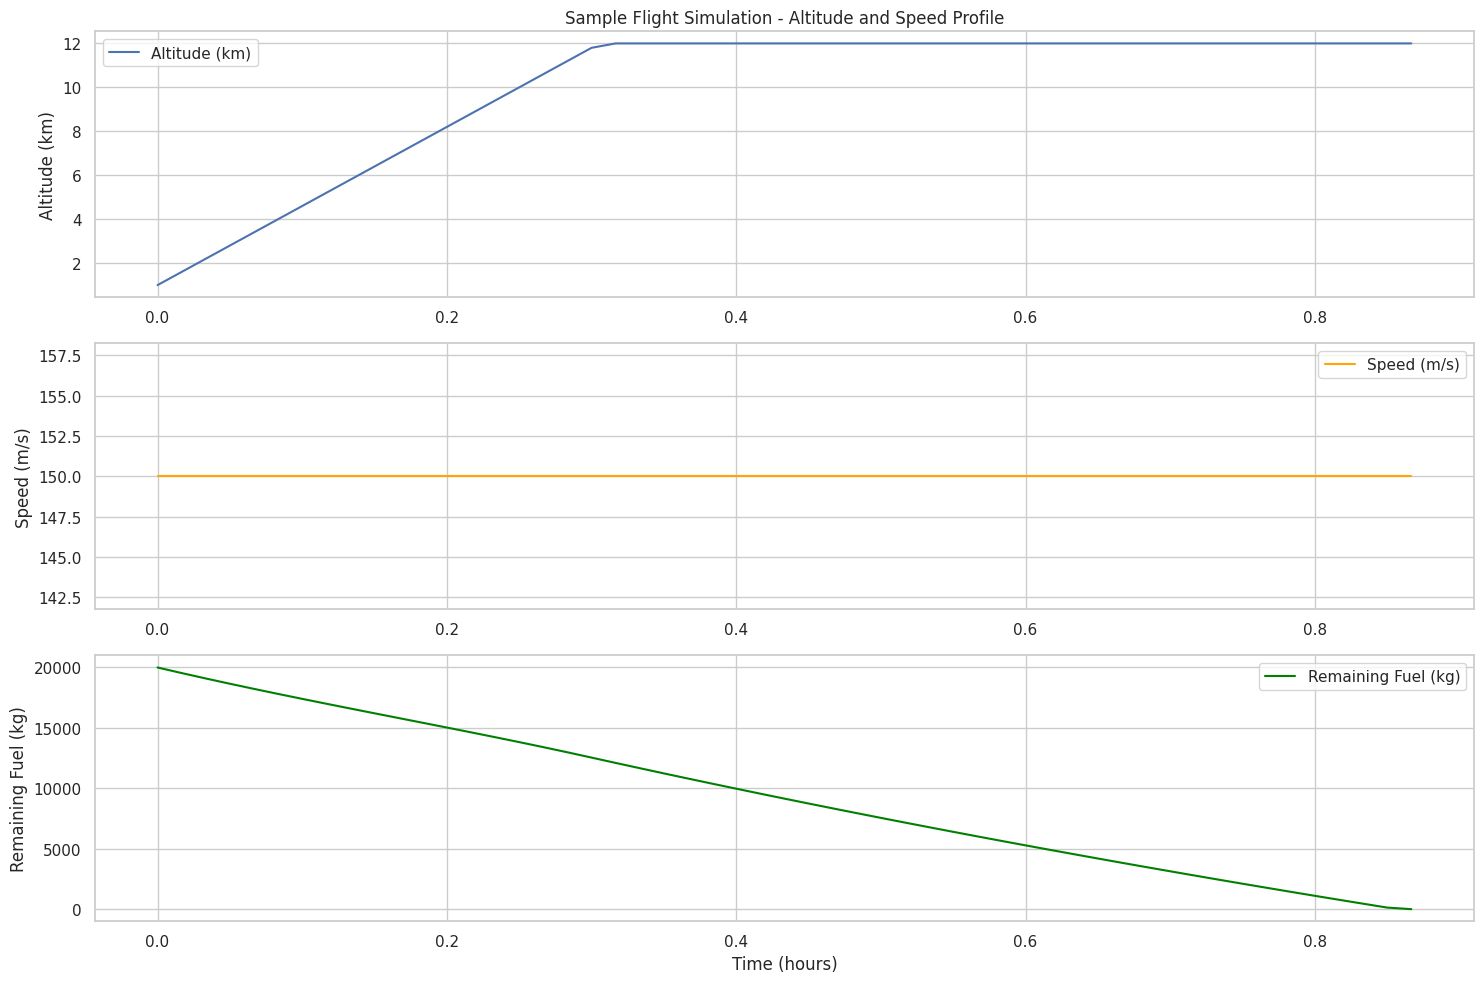

Sample simulation visualization complete.


In [42]:
def run_sample_simulation(initial_altitude: float, initial_speed: float, mission_distance: float, total_steps: int, time_step: float) -> pd.DataFrame:
    """
    Runs a sample flight simulation with a predefined sequence of actions.

    Args:
        initial_altitude (float): Starting altitude in meters.
        initial_speed (float): Starting speed in m/s.
        mission_distance (float): Total mission distance in meters.
        total_steps (int): Number of simulation steps.
        time_step (float): Duration of each time step in seconds.

    Returns:
        pd.DataFrame: A DataFrame containing the flight path history.
    """
    print(f"\nRunning sample simulation for {mission_distance/1000:.0f} km mission over {total_steps} steps...")

    # Initial state: (altitude, aircraft_weight, remaining_fuel, distance_to_destination, current_speed, total_distance_flown, total_time_elapsed)
    current_state = (
        initial_altitude,
        INITIAL_AIRCRAFT_WEIGHT,
        INITIAL_FUEL_WEIGHT,
        mission_distance,
        initial_speed,
        0.0, # total_distance_flown
        0.0  # total_time_elapsed
    )

    history = []

    # Simple action sequence for demonstration
    # Climb for 1/3 of steps, Cruise for 1/3, Descend for 1/3
    climb_steps = total_steps // 3
    cruise_steps = total_steps // 3
    descent_steps = total_steps - climb_steps - cruise_steps

    actions = (['Climb'] * climb_steps +
               ['Maintain Altitude'] * cruise_steps +
               ['Descend'] * descent_steps)
    # Also vary speed during cruise and descent for more dynamic simulation
    actions[climb_steps + cruise_steps // 2 : climb_steps + cruise_steps] = ['Reduce Speed'] * (cruise_steps - cruise_steps // 2)
    actions[climb_steps + cruise_steps:] = ['Reduce Speed'] * descent_steps

    for step in range(total_steps):
        action = actions[step]

        # Append current state to history before update
        history.append({
            'step': step,
            'action': action,
            'altitude_m': current_state[0],
            'aircraft_weight_kg': current_state[1],
            'remaining_fuel_kg': current_state[2],
            'distance_to_dest_m': current_state[3],
            'current_speed_m_s': current_state[4],
            'total_distance_flown_m': current_state[5],
            'total_time_elapsed_s': current_state[6]
        })

        # Update state
        current_state, fuel_consumed, distance_covered = update_flight_state(current_state, action, time_step)

        # Break if mission completed or fuel ran out
        if current_state[3] <= 0 or current_state[2] <= 0:
            print(f"Mission ended at step {step}. Remaining distance: {current_state[3]:.2f}m, Remaining fuel: {current_state[2]:.2f}kg")
            break

    # Append final state if loop broke early
    if step < total_steps - 1 or current_state[3] <= 0 or current_state[2] <= 0:
        history.append({
            'step': step + 1,
            'action': 'Final State',
            'altitude_m': current_state[0],
            'aircraft_weight_kg': current_state[1],
            'remaining_fuel_kg': current_state[2],
            'distance_to_dest_m': current_state[3],
            'current_speed_m_s': current_state[4],
            'total_distance_flown_m': current_state[5],
            'total_time_elapsed_s': current_state[6]
        })

    return pd.DataFrame(history)

# Run a simulation
simulation_results_df = run_sample_simulation(
    initial_altitude=1000.0,
    initial_speed=150.0,
    mission_distance=500_000.0, # 500 km
    total_steps=1000,
    time_step=60.0 # 1 minute time step
)

print("Sample simulation results:")
print(simulation_results_df.head())
print(simulation_results_df.tail())

# Visualize simulation results
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(simulation_results_df['total_time_elapsed_s'] / 3600, simulation_results_df['altitude_m'] / 1000, label='Altitude (km)')
plt.ylabel('Altitude (km)')
plt.title('Sample Flight Simulation - Altitude and Speed Profile')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(simulation_results_df['total_time_elapsed_s'] / 3600, simulation_results_df['current_speed_m_s'], label='Speed (m/s)', color='orange')
plt.ylabel('Speed (m/s)')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(simulation_results_df['total_time_elapsed_s'] / 3600, simulation_results_df['remaining_fuel_kg'], label='Remaining Fuel (kg)', color='green')
plt.xlabel('Time (hours)')
plt.ylabel('Remaining Fuel (kg)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Sample simulation visualization complete.")

## Bölüm 4 – Keşifçi Veri Analizi (EDA)

Takviyeli öğrenme ajanı eğitmeden önce, ortamımızın davranışını ve farklı uçuş parametrelerinin (irtifa, hız, yakıt tüketimi) birbirini nasıl etkilediğini anlamak önemlidir. Bu bölüm, çok sayıda rastgele uçuş senaryosu üreterek ve toplanan verileri analiz ederek gerçekleştirilecektir.

### Rastgele Uçuşlar Oluşturma

Farklı başlangıç koşulları ve rastgele eylem dizileriyle birden fazla uçuş simülasyonu çalıştıracağız. Bu, ortamın durum uzayının daha geniş bir kapsamını keşfetmemizi ve bu keşiften değerli bilgiler çıkarmamızı sağlayacaktır.

In [43]:
def generate_random_flight_data(num_flights: int, max_steps_per_flight: int, time_step: float) -> pd.DataFrame:
    """
    Generates data from multiple random flights by taking random actions.

    Args:
        num_flights (int): Number of random flights to simulate.
        max_steps_per_flight (int): Maximum number of steps for each flight.
        time_step (float): Duration of each time step in seconds.

    Returns:
        pd.DataFrame: A DataFrame containing data from all simulated flights.
    """
    all_flight_data = []
    possible_actions = ['Climb', 'Descend', 'Maintain Altitude', 'Increase Speed', 'Reduce Speed']

    print(f"Generating {num_flights} random flight simulations...")

    for i in range(num_flights):
        # Random initial conditions for more varied data
        initial_altitude = np.random.uniform(MIN_ALTITUDE, MAX_ALTITUDE * 0.5) # Start lower
        initial_speed = np.random.uniform(MIN_SPEED, MAX_SPEED * 0.8) # Start mid-range
        mission_distance = np.random.uniform(200_000, 1_000_000) # 200 km to 1000 km

        current_state = (
            initial_altitude,
            INITIAL_AIRCRAFT_WEIGHT,
            INITIAL_FUEL_WEIGHT,
            mission_distance,
            initial_speed,
            0.0, # total_distance_flown
            0.0  # total_time_elapsed
        )

        flight_history = []
        total_fuel_burn_this_flight = 0.0

        for step in range(max_steps_per_flight):
            action = np.random.choice(possible_actions)

            # Store state before action for analysis
            flight_history.append({
                'flight_id': i,
                'step': step,
                'action_taken': action,
                'initial_altitude_m': initial_altitude,
                'initial_speed_m_s': initial_speed,
                'mission_distance_m': mission_distance,
                'altitude_m': current_state[0],
                'aircraft_weight_kg': current_state[1],
                'remaining_fuel_kg': current_state[2],
                'distance_to_dest_m': current_state[3],
                'current_speed_m_s': current_state[4],
                'total_distance_flown_m': current_state[5],
                'total_time_elapsed_s': current_state[6]
            })

            new_state, fuel_consumed, distance_covered = update_flight_state(current_state, action, time_step)
            total_fuel_burn_this_flight += fuel_consumed
            current_state = new_state

            # Check for termination conditions
            if current_state[3] <= 0 or current_state[2] <= 0:
                # Add final state
                flight_history.append({
                    'flight_id': i,
                    'step': step + 1,
                    'action_taken': 'TERMINATED',
                    'initial_altitude_m': initial_altitude,
                    'initial_speed_m_s': initial_speed,
                    'mission_distance_m': mission_distance,
                    'altitude_m': current_state[0],
                    'aircraft_weight_kg': current_state[1],
                    'remaining_fuel_kg': current_state[2],
                    'distance_to_dest_m': current_state[3],
                    'current_speed_m_s': current_state[4],
                    'total_distance_flown_m': current_state[5],
                    'total_time_elapsed_s': current_state[6]
                })
                break

        # Add total fuel burn and time for the flight if not already added
        for entry in flight_history:
            entry['total_fuel_burn_kg'] = total_fuel_burn_this_flight
            entry['final_time_s'] = current_state[6]
            entry['mission_successful'] = 1 if current_state[3] <= 0 else 0

        all_flight_data.extend(flight_history)

    return pd.DataFrame(all_flight_data)

# Generate a substantial dataset
eda_df = generate_random_flight_data(num_flights=200, max_steps_per_flight=500, time_step=60.0)

print("\nExploratory Data Analysis DataFrame head:")
print(eda_df.head())
print("\nExploratory Data Analysis DataFrame info:")
eda_df.info()


Generating 200 random flight simulations...

Exploratory Data Analysis DataFrame head:
   flight_id  step  action_taken  initial_altitude_m  initial_speed_m_s  \
0          0     0  Reduce Speed         1068.268364         108.558829   
1          0     1       Descend         1068.268364         108.558829   
2          0     2         Climb         1068.268364         108.558829   
3          0     3       Descend         1068.268364         108.558829   
4          0     4  Reduce Speed         1068.268364         108.558829   

   mission_distance_m   altitude_m  aircraft_weight_kg  remaining_fuel_kg  \
0       890431.159036  1068.268364        70000.000000       20000.000000   
1       890431.159036  1068.268364        69575.429528       19575.429528   
2       890431.159036   768.268364        69156.399030       19156.399030   
3       890431.159036  1368.268364        68735.298179       18735.298179   
4       890431.159036  1068.268364        68319.967934       18319.967934   


### Veri İlişkilerini Analiz Etme

Oluşturulan veri setini kullanarak, uçuş parametreleri arasındaki önemli ilişkileri keşfedelim. Özellikle, yakıt tüketimi, irtifa, hız ve uçuş süresi arasındaki bağlantıları inceleyeceğiz.

In [44]:
# Calculate cumulative fuel burn for analysis at each step
eda_df['cumulative_fuel_burn_kg'] = eda_df.groupby('flight_id')['remaining_fuel_kg'].transform(lambda x: INITIAL_FUEL_WEIGHT - x)

# Calculate instantaneous fuel burn for each step
eda_df['instantaneous_fuel_burn_kg_per_s'] = eda_df['cumulative_fuel_burn_kg'].diff() / eda_df['total_time_elapsed_s'].diff()
eda_df.loc[eda_df['step'] == 0, 'instantaneous_fuel_burn_kg_per_s'] = 0 # First step has no diff

# Drop NaN from diff at group start
eda_df.dropna(subset=['instantaneous_fuel_burn_kg_per_s'], inplace=True)

# Filter out initial state rows if they don't represent a step-wise change
# Or re-calculate for step 0 based on initial conditions, but for EDA, we might focus on 'active' steps.
# For simplicity, let's just make sure the instantaneous calculation is robust.

print("Added cumulative and instantaneous fuel burn to DataFrame.")
print(eda_df[['flight_id', 'step', 'altitude_m', 'current_speed_m_s', 'remaining_fuel_kg', 'cumulative_fuel_burn_kg', 'instantaneous_fuel_burn_kg_per_s']].head())

Added cumulative and instantaneous fuel burn to DataFrame.
   flight_id  step   altitude_m  current_speed_m_s  remaining_fuel_kg  \
0          0     0  1068.268364         108.558829       20000.000000   
1          0     1  1068.268364         103.558829       19575.429528   
2          0     2   768.268364         103.558829       19156.399030   
3          0     3  1368.268364         103.558829       18735.298179   
4          0     4  1068.268364         103.558829       18319.967934   

   cumulative_fuel_burn_kg  instantaneous_fuel_burn_kg_per_s  
0                 0.000000                          0.000000  
1               424.570472                          7.076175  
2               843.600970                          6.983842  
3              1264.701821                          7.018348  
4              1680.032066                          6.922171  


### Görselleştirmeler

Parametreler arasındaki ilişkileri görselleştirmek için saçılım grafikleri, histogramlar ve korelasyon ısı haritaları kullanacağız.

In [45]:
# Helper function for plotting distributions
def plot_distribution(data: pd.Series, title: str, xlabel: str, bins: int = 30):
    plt.figure(figsize=(8, 5))
    sns.histplot(data, bins=bins, kde=True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# Helper function for plotting scatter plots
def plot_scatter(x: pd.Series, y: pd.Series, title: str, xlabel: str, ylabel: str):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=x, y=y, alpha=0.6, s=10)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

print("Plotting utility functions defined.")

Plotting utility functions defined.


#### Yükseklik ve Yakıt Tüketimi İlişkisi

Uçakların daha yüksek irtifalarda daha verimli olduğu bilinir. Bu, daha düşük hava yoğunluğu nedeniyle sürüklemenin azalmasıyla ilgilidir. Üretilen verilerimizde bu eğilimi gözlemleyip gözlemleyemediğimize bakalım.

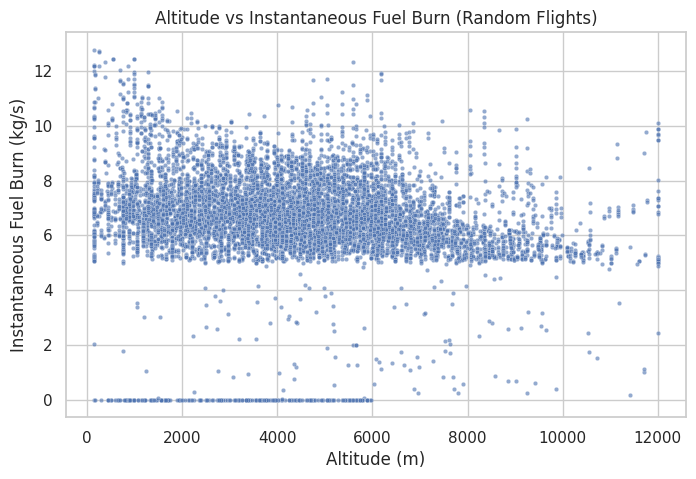

In [46]:
# Altitude vs Instantaneous Fuel Burn
plot_scatter(
    eda_df['altitude_m'],
    eda_df['instantaneous_fuel_burn_kg_per_s'],
    'Altitude vs Instantaneous Fuel Burn (Random Flights)',
    'Altitude (m)',
    'Instantaneous Fuel Burn (kg/s)'
)

# Engineering Observation: Generally, instantaneous fuel burn tends to decrease with increasing altitude, as expected due to lower air density reducing drag. However, there's significant scatter due to varying speeds and weights.

#### Hız ve Yakıt Tüketimi İlişkisi

Hızın yakıt tüketimi üzerinde önemli bir etkisi vardır; çok yavaş veya çok hızlı uçmak verimsiz olabilir. Optimum bir seyir hızı genellikle mevcuttur.

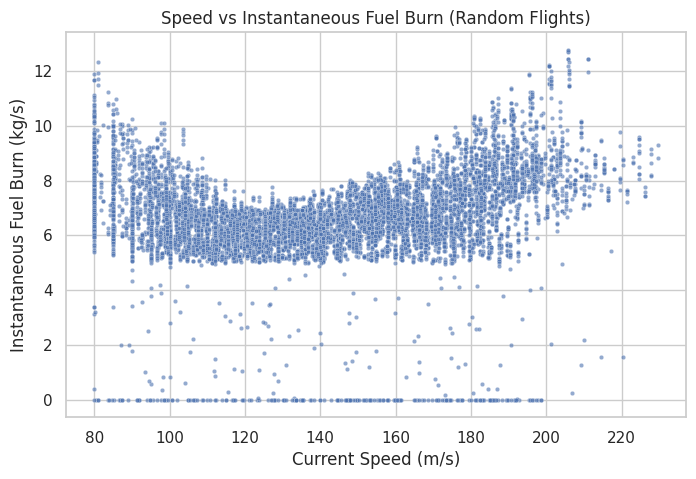

In [47]:
# Speed vs Instantaneous Fuel Burn
plot_scatter(
    eda_df['current_speed_m_s'],
    eda_df['instantaneous_fuel_burn_kg_per_s'],
    'Speed vs Instantaneous Fuel Burn (Random Flights)',
    'Current Speed (m/s)',
    'Instantaneous Fuel Burn (kg/s)'
)

# Engineering Observation: We can observe a 'U-shaped' or increasing trend where very low or very high speeds might lead to higher fuel consumption, especially at lower altitudes. The 'sweet spot' for fuel efficiency (lower burn rate) seems to be in a mid-speed range, though this is heavily influenced by altitude.

#### Görev Süresi ve Toplam Yakıt Tüketimi

Bir görevi tamamlama süresi ile toplam yakıt tüketimi arasında genellikle bir denge vardır. Daha hızlı uçmak daha az zaman alabilir ancak daha fazla yakıt tüketebilir.

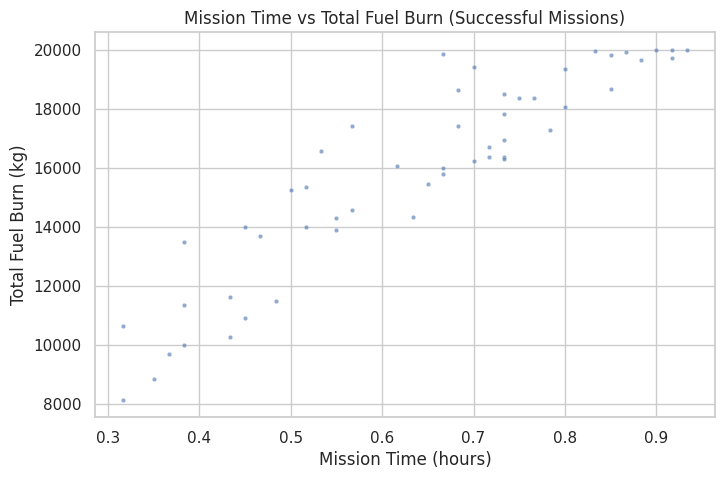

In [48]:
# Mission Time vs Total Fuel Consumption for successful missions
mission_summary = eda_df[eda_df['mission_successful'] == 1].groupby('flight_id').agg(
    final_time_s=('final_time_s', 'max'),
    total_fuel_burn_kg=('total_fuel_burn_kg', 'max'),
    mission_distance_m=('mission_distance_m', 'first')
).reset_index()

plot_scatter(
    mission_summary['final_time_s'] / 3600, # Convert to hours
    mission_summary['total_fuel_burn_kg'],
    'Mission Time vs Total Fuel Burn (Successful Missions)',
    'Mission Time (hours)',
    'Total Fuel Burn (kg)'
)

# Engineering Observation: As expected, longer mission times generally correlate with higher total fuel burn, but the relationship is not always linear due to variations in flight profiles (altitude, speed choices). There's a trade-off: minimizing time often increases fuel burn and vice versa.

#### Temel Değişkenlerin Dağılımları

Veri setimizdeki temel değişkenlerin (irtifa, hız, yakıt tüketimi) genel dağılımlarına bakalım.

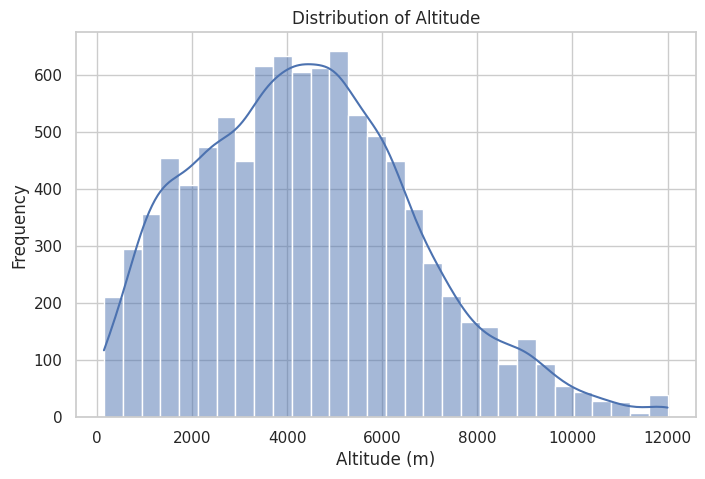

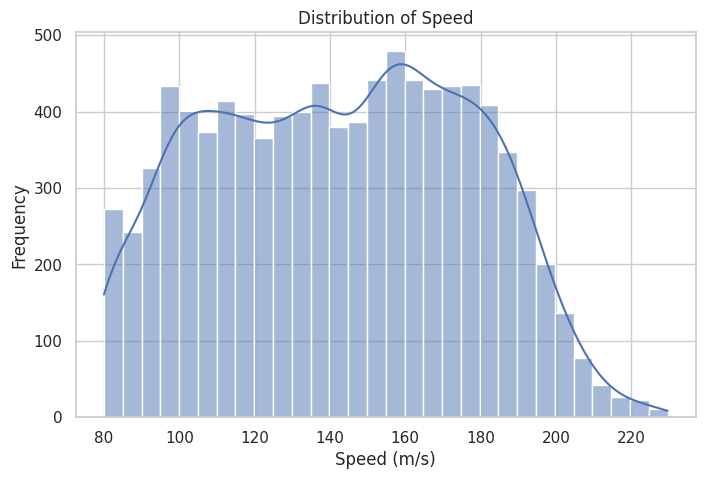

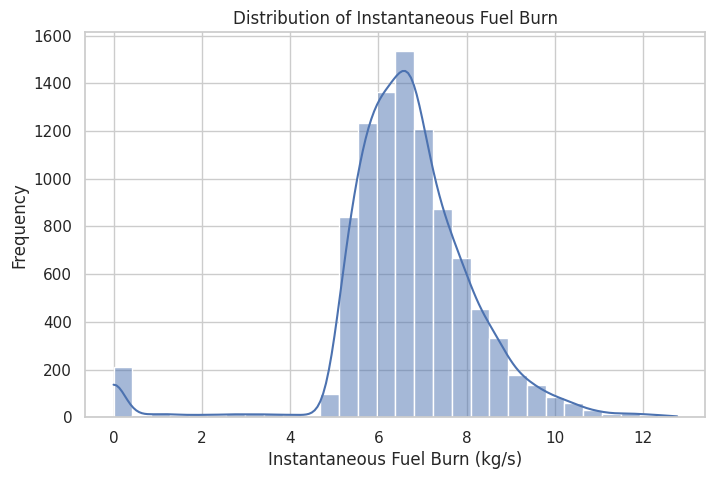

In [49]:
# Histograms for key variables
plot_distribution(eda_df['altitude_m'], 'Distribution of Altitude', 'Altitude (m)')
plot_distribution(eda_df['current_speed_m_s'], 'Distribution of Speed', 'Speed (m/s)')
plot_distribution(eda_df['instantaneous_fuel_burn_kg_per_s'], 'Distribution of Instantaneous Fuel Burn', 'Instantaneous Fuel Burn (kg/s)')

# Engineering Observation: These distributions show the range and frequency of different states and fuel burn rates encountered during random exploration. For instance, the altitude distribution might show where the random agent spent most of its time.

#### Korelasyon Isı Haritası

Uçuş parametreleri arasındaki doğrusal ilişkileri bir korelasyon ısı haritası kullanarak görselleştirelim.

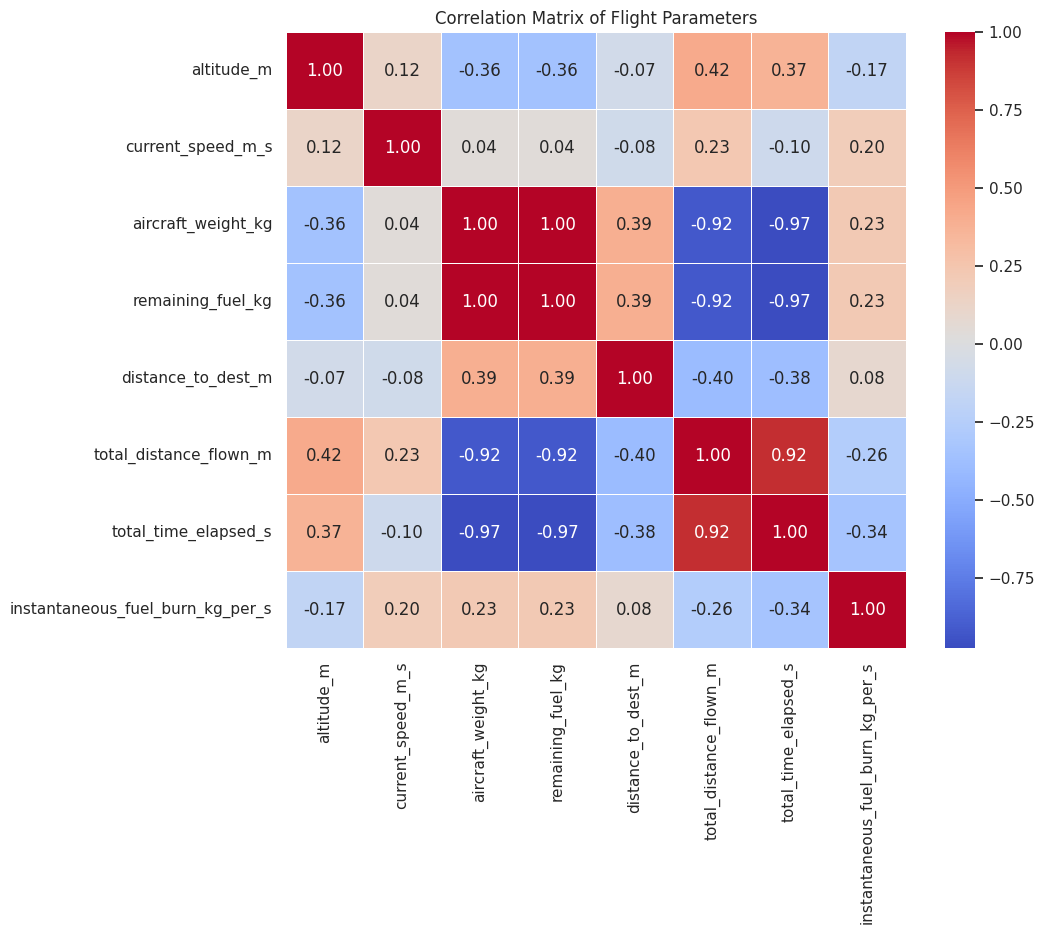

In [50]:
# Select relevant columns for correlation
correlation_cols = [
    'altitude_m',
    'current_speed_m_s',
    'aircraft_weight_kg',
    'remaining_fuel_kg',
    'distance_to_dest_m',
    'total_distance_flown_m',
    'total_time_elapsed_s',
    'instantaneous_fuel_burn_kg_per_s'
]

# Calculate the correlation matrix
correlation_matrix = eda_df[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Flight Parameters')
plt.show()

# Engineering Observation: We expect a strong negative correlation between 'remaining_fuel_kg' and 'total_fuel_burn_kg', and positive correlations between 'total_distance_flown_m', 'total_time_elapsed_s' and 'total_fuel_burn_kg'. Altitude might have a negative correlation with instantaneous fuel burn, while speed can have a more complex relationship. This heatmap helps quantify these relationships.

### Mühendislik Gözlemleri

Keşifçi veri analizi bize modelimiz hakkında önemli bilgiler sağlamıştır:

*   **Yükseklik ve Verimlilik:** Beklendiği gibi, daha yüksek irtifalarda hava yoğunluğunun düşmesi nedeniyle yakıt tüketim oranının azalma eğilimi göstermesi, tırmanmanın ve seyir irtifasının optimizasyon için önemli olduğunu vurgular.
*   **Hızın İkili Etkisi:** Hızın yakıt tüketimi üzerinde doğrusal olmayan bir etkisi vardır. Çok yavaş uçuşlar sürükleme nedeniyle verimsiz olabilirken, çok yüksek hızlar da artan sürükleme ve motor performansı kısıtlamaları nedeniyle yakıtı artırır. Optimal bir 'seyir hızı' arayışı önemlidir.
*   **Misyon Hedefleri Arasındaki Denge:** Uçuş süresini en aza indirme ile yakıt tüketimini en aza indirme arasında net bir denge olduğu gözlemlenmiştir. Bu, ödül mühendisliğinde farklı stratejilerin nasıl ele alınması gerektiğini gösterir.
*   **Veri Dağılımı:** Rastgele eylemlerle oluşturulan geniş veri dağılımı, RL ajanının ortamın farklı bölgelerini keşfetmek için yeterli fırsata sahip olduğunu doğrulamaktadır. Bu veri, ajanın farklı durumları ve eylemlerinin sonuçlarını öğrenmesi için zengin bir temel sağlar.

## Bölüm 5 – Markov Karar Süreci (MDP)

Takviyeli Öğrenmenin temelini oluşturan Markov Karar Süreci (MDP), karar vericinin (ajan) rastgele davranış sergileyen bir ortamda nasıl karar alacağını matematiksel olarak modellediği bir çerçevedir. Daha önce de belirttiğimiz gibi, uçuş optimizasyon problemi ardışık karar verme yapısından dolayı bir MDP olarak formüle edilebilir.

Bir MDP beş temel bileşenden oluşur: $(S, A, P, R, \gamma)$

### Durum (State - $S$)

**Tanım:** Ortamın belirli bir zaman anındaki tam bir açıklamasını veren veri kümesidir. Bir ajan için karar vermek üzere gerekli tüm bilgiyi içermelidir.

**Havacılık Örneği:** Bir uçağın durumu, o anki **irtifası**, **hızı**, **kalan yakıtı**, **hedefe kalan mesafesi** ve **uçağın ağırlığı** gibi değişkenlerle tanımlanır. Bu değişkenler, uçağın bir sonraki kararını etkileyecek kritik bilgilerdir.

```mermaid
graph TD
    A[Uçuş Ortamı] --> B{Mevcut Durum $s_t$}
    B --> C(İrtifa)
    B --> D(Hız)
    B --> E(Kalan Yakıt)
    B --> F(Hedefe Mesafe)
    B --> G(Uçak Ağırlığı)
    C -- Ölçülür --> H(Sensör Verisi)
    D -- Ölçülür --> H
    E -- Ölçülür --> H
    F -- Ölçülür --> H
    G -- Ölçülür --> H
```

### Eylem (Action - $A$)

**Tanım:** Ajanın ortamda yapabileceği seçimlerdir. Her bir durumda ajan, mevcut durumuna göre bir eylem seçer.

**Havacılık Örneği:** Bir uçuş sırasında pilot veya otonom sistem tarafından alınabilecek kararlar eylemlerdir. Örneğin, **tırmanma**, **iniş**, **irtifayı koruma**, **hızı artırma**, **hızı azaltma** gibi eylemler, uçağın durumunu doğrudan etkiler.

```mermaid
graph TD
    A{Mevcut Durum $s_t$} --> B(Karar Verme)
    B --> C[Eylem $a_t$: Tırman]
    B --> D[Eylem $a_t$: İniş Yap]
    B --> E[Eylem $a_t$: İrtifayı Koru]
    B --> F[Eylem $a_t$: Hızı Artır]
    B --> G[Eylem $a_t$: Hızı Azalt]
```

### Ödül (Reward - $R$)

**Tanım:** Ajanın ortamda bir eylem gerçekleştirdiğinde aldığı anlık geri bildirimdir. Ajanın amacı, zaman içinde kümülatif ödülü maksimize etmektir. Ödül, ortam tarafından belirlenir.

**Havacılık Örneği:** Ajanın bir eylemi sonucunda aldığı ödül, misyon hedeflerine ne kadar yaklaştığını veya uzaklaştığını gösterir. Örneğin:

*   **Pozitif Ödül:** Yakıt tasarrufu yapmak, hedefe yaklaşmak, misyonu başarıyla tamamlamak.
*   **Negatif Ödül (Ceza):** Aşırı yakıt tüketimi, uçuş süresini uzatmak, motoru zorlamak, misyonu tamamlayamamak.

```mermaid
graph TD
    A{Durum $s_t$} -- Eylem $a_t$ --> B{Yeni Durum $s_{t+1}$}
    B -- Ortam --> C(Ödül $r_t$)
    C -- Geri Bildirim --> D[Ajanın Öğrenmesi]
    subgraph Ödül Fonksiyonu
        E[Yakıt Verimliliği] --> C
        F[Uçuş Süresi] --> C
        G[Misyon Tamamlama] --> C
        H[Kısıtlama İhlali] -- Negatif Ödül --> C
    end
```

### Geçiş (Transition - $P$)

**Tanım:** Ajanın mevcut bir durumdan ($s_t$) belirli bir eylem ($a_t$) sonucunda bir sonraki duruma ($s_{t+1}$) geçme olasılığını tanımlar. Ortamın dinamiklerini temsil eder.

**Havacılık Örneği:** Bir uçağın $s_t$ durumunda (örneğin, 5000 metre irtifada, 150 m/s hızda) 'tırmanma' eylemini yapması sonucunda, rüzgar koşulları, uçak performansı gibi faktörlere bağlı olarak belirli bir $s_{t+1}$ durumuna (örneğin, 5050 metre irtifada, 145 m/s hızda) geçme olasılığıdır. Bizim basitleştirilmiş modelimizde bu geçişler deterministiktir (yani olasılık 1'dir).

```mermaid
graph TD
    A{Durum $s_t$} -- Eylem $a_t$ --> B{Ortam Dinamikleri}
    B --> C(Olasılık $P(s_{t+1}|s_t, a_t)$)
    C -- Belirler --> D[Yeni Durum $s_{t+1}$]
    subgraph Ortam Dinamikleri
        E[Aerodinamik] --> B
        F[Motor Performansı] --> B
        G[Yakıt Tüketimi] --> B
    end
```

### Politika (Policy - $\pi$)

**Tanım:** Ajanın herhangi bir durumda hangi eylemi seçeceğini belirleyen stratejidir. En uygun politika, uzun vadeli beklenen ödülü maksimize eden politikadır.

**Havacılık Örneği:** Bir uçağın optimal politika $\pi$ tarafından yönlendirilmesi, herhangi bir anda (irtifa, hız, yakıt durumu, hedefe mesafe gibi belirli bir durum $s$ verildiğinde) hangi eylemi (tırman, iniş yap, hızı artır vb.) alması gerektiğini belirtir. Örneğin: "Eğer yakıt azalıyorsa ve hedefe çok uzaksan, alçak irtifada hızı azalt." gibi bir kural.

```mermaid
graph TD
    A{Gözlemlenen Durum $s$} --> B[Politika $\pi(a|s)$]
    B --> C(Seçilen Eylem $a$)
    C -- Uygulanır --> D[Ortam]
    D -- Sonuç --> A
    subgraph Politika Özellikleri
        E[Dinamik Karar Alma] --> B
        F[En Uygun Eylem Seçimi] --> B
        G[Durum-Eylem Eşlemesi] --> B
    end
```

### MDP Özet Diyagramı

Bu bileşenlerin bir araya gelerek bir MDP'yi nasıl oluşturduğunu aşağıdaki diyagramda özetleyebiliriz:

```mermaid
graph LR
    A[Ajan] -- Eylem $a_t$ --> B(Ortam)
    B -- Yeni Durum $s_{t+1}$ --> A
    B -- Ödül $r_t$ --> A
    A -- Öğrenir (Politika $\pi$) --> A
    subgraph Ortam
        B
        direction LR
        B1[Durum $s_t$] --> B2{Eylem $a_t$ Seçimi}
        B2 --> B3[Ortam Dinamikleri $P$]
        B3 --> B4[Yeni Durum $s_{t+1}$]
        B3 --> B5[Ödül $r_t$]
        B4 --> B1
    end
```

### Sezgisel Yorum

Bir uçağın uçuşu, sürekli bir karar verme ve geri bildirim döngüsüdür. Her an (durum), pilot (ajan) bir eylem (irtifayı veya hızı değiştirme) yapar. Ortam (hava durumu, uçak dinamikleri) bu eyleme tepki verir ve uçağı yeni bir duruma getirir, aynı zamanda pilotun hedeflerine ne kadar yaklaştığını veya uzaklaştığını gösteren bir 'ödül' (yakıt tüketimi, zaman kaybı) verir. Pilot bu ödülü kullanarak hangi kararların daha iyi olduğunu zamanla öğrenir ve optimal bir 'politika' geliştirir. MDP, bu sezgisel süreci matematiksel olarak modeller ve ajanın en iyi politikayı sistematik olarak bulmasına olanak tanır.

## Bölüm 6 – Ödül Tasarımı

Takviyeli Öğrenmenin belki de en kritik yönlerinden biri, **ödül fonksiyonunun** tasarımıdır. Ajanın neyi optimize etmesini istediğimizi ödüle kodlarız. İyi tasarlanmış bir ödül, ajanın istenen davranışı öğrenmesini sağlarken, kötü tasarlanmış bir ödül istenmeyen veya verimsiz stratejilere yol açabilir. Buna **Ödül Mühendisliği** denir.

### Ödül Fonksiyonlarının Tanımlanması

Uçuş optimizasyonu problemimizde birden fazla amacımız vardı: yakıtı, süreyi minimize etmek ve misyonu tamamlamak. Bu amaçları tek bir ödül fonksiyonunda birleştirmemiz gerekmektedir.

In [51]:
def calculate_reward(state: tuple, previous_state: tuple, action: str, time_step: float,
                     weights: dict = None) -> float:
    """
    Calculates the reward for a given state transition.

    Args:
        state (tuple): Current state (altitude, aircraft_weight, remaining_fuel, dist_to_dest, current_speed, total_dist_flown, total_time_elapsed).
        previous_state (tuple): Previous state before the action.
        action (str): The action taken.
        time_step (float): Duration of the time step in seconds.
        weights (dict): Dictionary of weights for reward components (fuel, time, mission_completion).

    Returns:
        float: The scalar reward value.
    """
    if weights is None:
        weights = {'fuel': -0.1, 'time': -0.01, 'mission_completion': 1000.0, 'fuel_exhaustion': -1000.0, 'crash_penalty': -1000.0}

    prev_alt, prev_weight, prev_fuel, prev_dist, prev_speed, prev_total_dist_flown, prev_time = previous_state
    curr_alt, curr_weight, curr_fuel, curr_dist, curr_speed, curr_total_dist_flown, curr_time = state

    # Fuel burn component (negative reward for burning fuel)
    fuel_consumed = prev_fuel - curr_fuel
    reward_fuel = weights['fuel'] * fuel_consumed

    # Time elapsed component (negative reward for time passing)
    time_taken = curr_time - prev_time
    reward_time = weights['time'] * time_taken

    # Distance covered component (positive reward for making progress)
    distance_covered = curr_total_dist_flown - prev_total_dist_flown
    reward_distance = 0.0 # We will primarily use distance_to_dest for completion

    # Mission completion bonus/penalty
    reward_mission = 0.0
    if curr_dist <= 0: # Mission completed successfully
        reward_mission = weights['mission_completion']
    elif curr_fuel <= 0 and curr_dist > 0: # Ran out of fuel before destination
        reward_mission = weights['fuel_exhaustion']

    # Simple altitude bounds check (crash penalty)
    if curr_alt < MIN_ALTITUDE or curr_alt > MAX_ALTITUDE:
        reward_mission += weights['crash_penalty']

    total_reward = reward_fuel + reward_time + reward_mission

    return total_reward

print("Reward calculation function defined.")

Reward calculation function defined.


### Farklı Ödül Yapıları

Farklı uçuş hedeflerine odaklanmak için ödül fonksiyonu ağırlıklarını değiştirerek çeşitli ödül yapıları tanımlayabiliriz.

In [52]:
# Reward structure 1: Prioritize fuel efficiency
REWARD_WEIGHTS_FUEL_EFFICIENT = {
    'fuel': -1.0,          # High penalty for fuel burn
    'time': -0.001,        # Small penalty for time
    'mission_completion': 1000.0, # High reward for completion
    'fuel_exhaustion': -1000.0, # High penalty for running out of fuel
    'crash_penalty': -1000.0
}

# Reward structure 2: Prioritize minimizing flight time
REWARD_WEIGHTS_TIME_CRITICAL = {
    'fuel': -0.01,         # Small penalty for fuel burn
    'time': -1.0,          # High penalty for time
    'mission_completion': 1000.0,
    'fuel_exhaustion': -1000.0,
    'crash_penalty': -1000.0
}

# Reward structure 3: Balanced approach
REWARD_WEIGHTS_BALANCED = {
    'fuel': -0.1,
    'time': -0.1,
    'mission_completion': 1000.0,
    'fuel_exhaustion': -1000.0,
    'crash_penalty': -1000.0
}

print("Different reward weight configurations defined.")

Different reward weight configurations defined.


### Ödül Yapılarını Görselleştirme

Ödül fonksiyonunun farklı durum ve eylemler üzerindeki etkisini anlamak için basit bir örnek üzerinden görselleştirelim. Örneğin, sabit bir hızda irtifa değişikliğinin anlık yakıt tüketimi ve dolayısıyla ödül üzerindeki etkisini inceleyebiliriz.

Visualizing reward for Fuel Efficient Strategy...


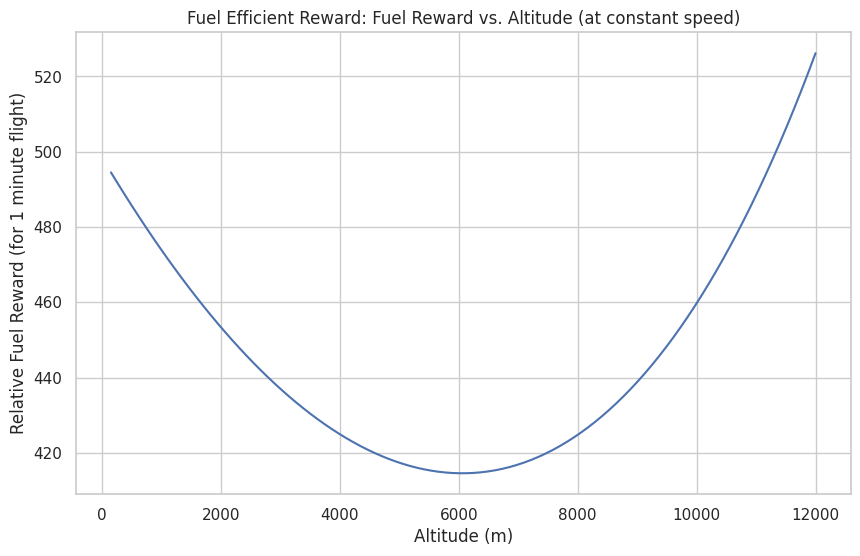

Visualizing reward for Time Critical Strategy (focus on implicit fuel cost)...


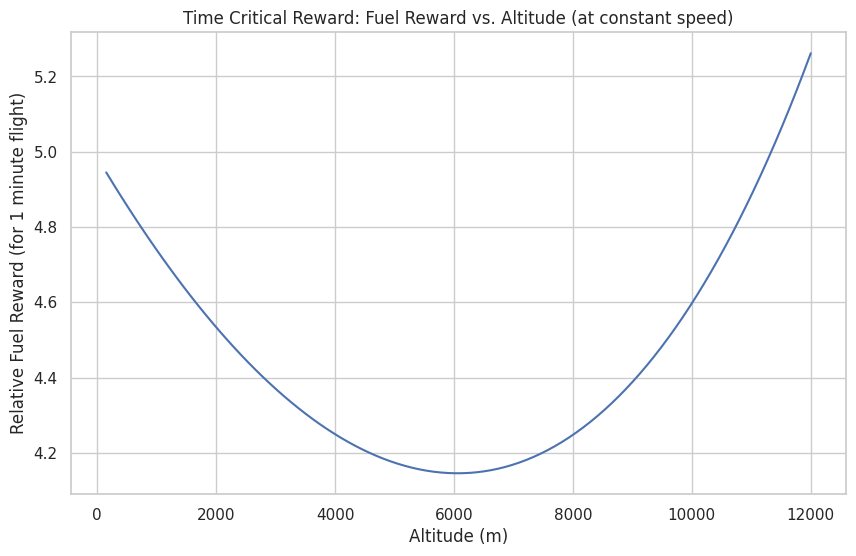

Visualizing reward for Balanced Strategy...


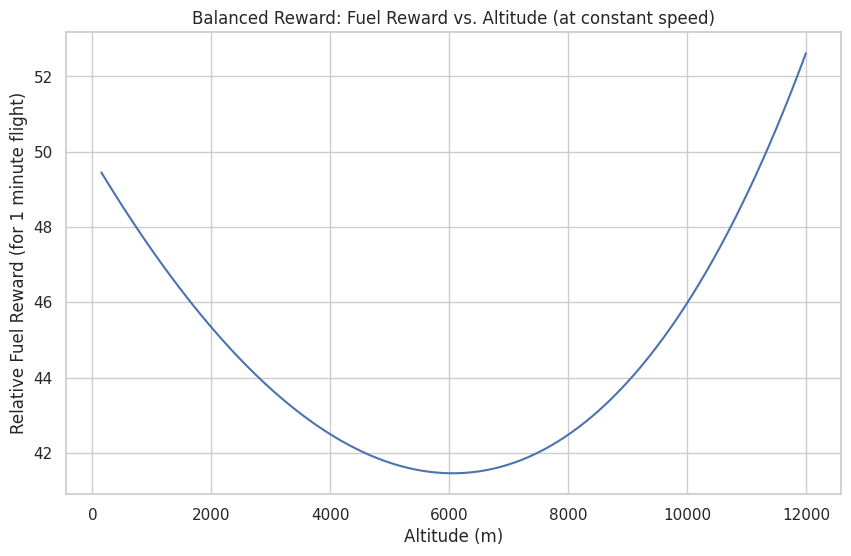

In [53]:
def visualize_reward_structure(reward_weights: dict, title: str):
    """
    Visualizes the fuel component of the reward function across different altitudes.
    Assumes constant speed and weight for simplicity.

    Args:
        reward_weights (dict): The set of weights for the reward function.
        title (str): Title for the plot.
    """
    altitudes = np.linspace(MIN_ALTITUDE, MAX_ALTITUDE, 100)
    fuel_burn_rates = [calculate_fuel_burn_rate(150.0, alt, INITIAL_AIRCRAFT_WEIGHT) for alt in altitudes]

    # Reward for burning fuel is negative, so we plot -fuel_burn_rate * weight['fuel']
    rewards_from_fuel = [-rate * reward_weights['fuel'] * 60 for rate in fuel_burn_rates] # Multiply by 60 for 1-min step for visual scale

    plt.figure(figsize=(10, 6))
    plt.plot(altitudes, rewards_from_fuel)
    plt.xlabel('Altitude (m)')
    plt.ylabel('Relative Fuel Reward (for 1 minute flight)')
    plt.title(f'{title}: Fuel Reward vs. Altitude (at constant speed)')
    plt.grid(True)
    plt.show()

print("Visualizing reward for Fuel Efficient Strategy...")
visualize_reward_structure(REWARD_WEIGHTS_FUEL_EFFICIENT, "Fuel Efficient Reward")

print("Visualizing reward for Time Critical Strategy (focus on implicit fuel cost)...")
visualize_reward_structure(REWARD_WEIGHTS_TIME_CRITICAL, "Time Critical Reward")

print("Visualizing reward for Balanced Strategy...")
visualize_reward_structure(REWARD_WEIGHTS_BALANCED, "Balanced Reward")

# Engineering Observation:
# These plots show how the *fuel component* of the reward changes with altitude.
# Higher altitudes generally yield higher (less negative) fuel rewards due to lower air density and less drag.
# The magnitude of the reward (y-axis scale) changes significantly based on the 'fuel' weight in the reward_weights dict.
# This illustrates how different reward weightings emphasize different aspects of the flight, encouraging the agent to seek states that maximize its specific objective.

### Ödül Mühendisliği (Reward Engineering)

Ödül Mühendisliği, ajanın istediğimiz hedefi en verimli şekilde öğrenmesini sağlamak için ödül fonksiyonunu tasarlama sürecidir. İyi bir ödül fonksiyonu:

*   **Hedefe Ulaştığında Yüksek Ödül:** Misyon tamamlama gibi hedeflere ulaştığında açıkça pozitif bir geri bildirim vermelidir.
*   **Ara Hedefler için Yönlendirme:** Ajana ara adımlarda da doğru yönde ilerlemesi için teşvikler sunmalıdır (örneğin, hedefe her yaklaşım için küçük bir pozitif ödül).
*   **İstenmeyen Davranışları Cezalandırma:** Yakıtın bitmesi, çok alçak uçmak gibi istenmeyen durumlar için açıkça negatif ödüller vermelidir.
*   **Seyrek Ödüllerle Başa Çıkma:** Bazı durumlarda ödüller çok seyrek olabilir. Bu durumda, ajanın öğrenme sürecini hızlandırmak için şekillendirilmiş (shaped) ödüller veya potansiyel fonksiyonlar kullanılabilir.

Ödül mühendisliği, deneyim ve alan bilgisi gerektiren iteratif bir süreçtir. Doğru ödül fonksiyonunu bulmak, bir takviyeli öğrenme projesinin başarısı için hayati öneme sahiptir.

## Bölüm 7 – Özel Bir RL Ortamı Oluşturma

Takviyeli Öğrenme ajanlarını eğitmek için, ajanın etkileşimde bulunacağı bir ortam modeline ihtiyacımız var. `Gymnasium` gibi popüler kütüphaneler mevcut olsa da, temel prensipleri anlamak için kendi basit ortamımızı sıfırdan oluşturmak öğretici olacaktır. Bu, ortamın nasıl çalıştığına dair daha iyi bir sezgi kazanmamızı sağlar.

### Ortam Sınıfı Tasarımı

Ortamımız, bir Takviyeli Öğrenme ortamının temel bileşenlerini içerecek bir Python sınıfı olarak tasarlanacaktır:

In [54]:
class FlightEnv:
    """
    A simplified custom Reinforcement Learning environment for flight optimization.
    The environment models basic flight dynamics and provides states, rewards, and checks for termination.
    """
    def __init__(self, initial_mission_distance: float = 500_000.0, time_step: float = 60.0,
                 reward_weights: dict = None):
        self.initial_mission_distance = initial_mission_distance
        self.time_step = time_step
        self.reward_weights = reward_weights if reward_weights is not None else REWARD_WEIGHTS_BALANCED

        self.action_space = ['Climb', 'Descend', 'Maintain Altitude', 'Increase Speed', 'Reduce Speed']
        self.n_actions = len(self.action_space)

        # State definition for the agent: (altitude, speed, remaining_fuel, distance_to_dest)
        # Note: aircraft_weight is implicitly handled by remaining_fuel relative to INITIAL_AIRCRAFT_WEIGHT
        # total_distance_flown and total_time_elapsed are for history/reward, not direct state for agent in this simplified version
        self.current_state = None
        self.previous_state = None
        self.total_reward = 0.0
        self.steps_taken = 0
        self.done = False

        # History tracking for analysis
        self.history = []

        self.reset()

    def reset(self) -> np.ndarray:
        """
        Resets the environment to an initial state and returns the observation.

        Returns:
            np.ndarray: The initial observation (state).
        """
        initial_altitude = 1000.0  # Start at a low altitude
        initial_speed = 150.0      # Start at a moderate speed

        self.current_state = (
            initial_altitude,
            INITIAL_AIRCRAFT_WEIGHT,  # Initial aircraft weight
            INITIAL_FUEL_WEIGHT,      # Initial fuel weight
            self.initial_mission_distance,
            initial_speed,
            0.0, # total_distance_flown
            0.0  # total_time_elapsed
        )
        self.previous_state = self.current_state
        self.total_reward = 0.0
        self.steps_taken = 0
        self.done = False
        self.history = []

        return self._get_observation()

    def _get_observation(self) -> np.ndarray:
        """
        Extracts the relevant observable state for the agent.
        """
        # Agent observes: altitude (scaled), speed (scaled), remaining_fuel (scaled), distance_to_dest (scaled)
        alt, weight, fuel, dist, speed, _, _ = self.current_state

        # Normalizing or scaling state variables is crucial for many RL algorithms
        scaled_altitude = alt / MAX_ALTITUDE
        scaled_speed = (speed - MIN_SPEED) / (MAX_SPEED - MIN_SPEED)
        scaled_remaining_fuel = fuel / INITIAL_FUEL_WEIGHT
        scaled_distance_to_dest = dist / self.initial_mission_distance

        return np.array([
            scaled_altitude,
            scaled_speed,
            scaled_remaining_fuel,
            scaled_distance_to_dest
        ])

    def step(self, action_index: int) -> tuple:
        """
        Takes an action in the environment and returns the next observation, reward, and done flag.

        Args:
            action_index (int): Index of the action to take from self.action_space.

        Returns:
            tuple: (observation, reward, done, info_dict)
                   observation (np.ndarray): The new state after taking the action.
                   reward (float): The reward received from the action.
                   done (bool): True if the episode has terminated, False otherwise.
                   info_dict (dict): A dictionary containing additional information.
        """
        if self.done:
            raise ValueError("Episode is done, please reset the environment.")

        action = self.action_space[action_index]
        self.previous_state = self.current_state

        # Update flight state using the previously defined function
        new_full_state, fuel_consumed, distance_covered = update_flight_state(self.current_state, action, self.time_step)
        self.current_state = new_full_state

        # Calculate reward based on transition and objective weights
        reward = calculate_reward(self.current_state, self.previous_state, action, self.time_step, self.reward_weights)
        self.total_reward += reward

        self.steps_taken += 1

        # Check for termination conditions
        current_fuel = self.current_state[2]
        current_distance_to_dest = self.current_state[3]
        current_altitude = self.current_state[0]

        # Termination conditions:
        # 1. Mission completed (distance to dest <= 0)
        # 2. Ran out of fuel (remaining fuel <= 0)
        # 3. Crashed (altitude too low or too high - simplified, more robust crash detection could be added)
        # 4. Maximum steps reached (to prevent infinite loops in exploration)
        if current_distance_to_dest <= 0 or current_fuel <= 0 or \
           current_altitude < MIN_ALTITUDE or current_altitude > MAX_ALTITUDE or \
           self.steps_taken >= 1000: # Max steps for an episode
            self.done = True

        # Store episode history (optional, for debugging/analysis)
        self.history.append({
            'step': self.steps_taken,
            'action': action,
            'altitude_m': self.current_state[0],
            'speed_m_s': self.current_state[4],
            'remaining_fuel_kg': self.current_state[2],
            'distance_to_dest_m': self.current_state[3],
            'reward': reward,
            'total_reward': self.total_reward,
            'done': self.done
        })

        info = {
            'full_state': self.current_state,
            'fuel_consumed_step': fuel_consumed,
            'distance_covered_step': distance_covered,
            'is_success': current_distance_to_dest <= 0 and current_fuel > 0
        }

        return self._get_observation(), reward, self.done, info

    def render(self):
        """
        Prints a simple representation of the current state.
        For now, just prints, later could be more visual.
        """
        alt, _, fuel, dist, speed, _, _ = self.current_state
        print(f"Step: {self.steps_taken}, Alt: {alt:.0f}m, Speed: {speed:.0f}m/s, Fuel: {fuel:.0f}kg, Dist: {dist:.0f}m, Reward: {self.history[-1]['reward']:.2f}, Total Reward: {self.total_reward:.2f}, Done: {self.done}")

print("FlightEnv class defined.")

FlightEnv class defined.


### Ortamın Temel İşlevlerini Test Etme

Ortam sınıfımızın doğru çalıştığını doğrulamak için basit bir demonstrasyon yapalım. Rastgele eylemlerle birkaç adım ilerleyeceğiz ve durumu, ödülü ve tamamlanma bayrağını gözlemleyeceğiz.

Initial Observation (scaled): [0.08333333 0.41176471 1.         1.        ]

--- Running simple environment demonstration ---
Step: 1, Alt: 1000m, Speed: 145m/s, Fuel: 19770kg, Dist: 195650m, Reward: -25.97, Total Reward: -25.97, Done: False
Step: 2, Alt: 850m, Speed: 145m/s, Fuel: 19540kg, Dist: 191300m, Reward: -26.08, Total Reward: -52.05, Done: False
Step: 3, Alt: 1150m, Speed: 145m/s, Fuel: 19312kg, Dist: 186950m, Reward: -25.74, Total Reward: -77.79, Done: False
Step: 4, Alt: 1150m, Speed: 150m/s, Fuel: 19078kg, Dist: 182450m, Reward: -26.41, Total Reward: -104.19, Done: False
Step: 5, Alt: 1000m, Speed: 150m/s, Fuel: 18843kg, Dist: 177950m, Reward: -26.53, Total Reward: -130.73, Done: False
Step: 6, Alt: 1000m, Speed: 155m/s, Fuel: 18600kg, Dist: 173300m, Reward: -27.31, Total Reward: -158.04, Done: False
Step: 7, Alt: 1000m, Speed: 160m/s, Fuel: 18348kg, Dist: 168500m, Reward: -28.17, Total Reward: -186.20, Done: False
Step: 8, Alt: 1000m, Speed: 165m/s, Fuel: 18087kg, Dist: 16

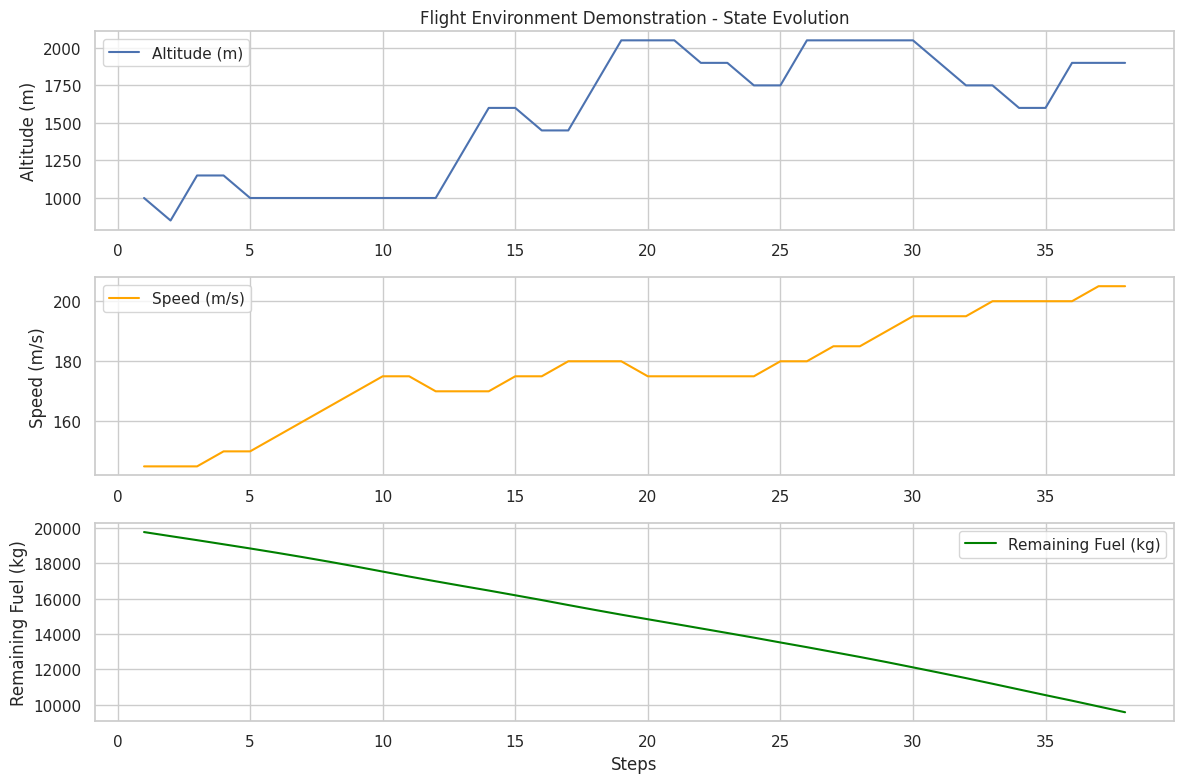

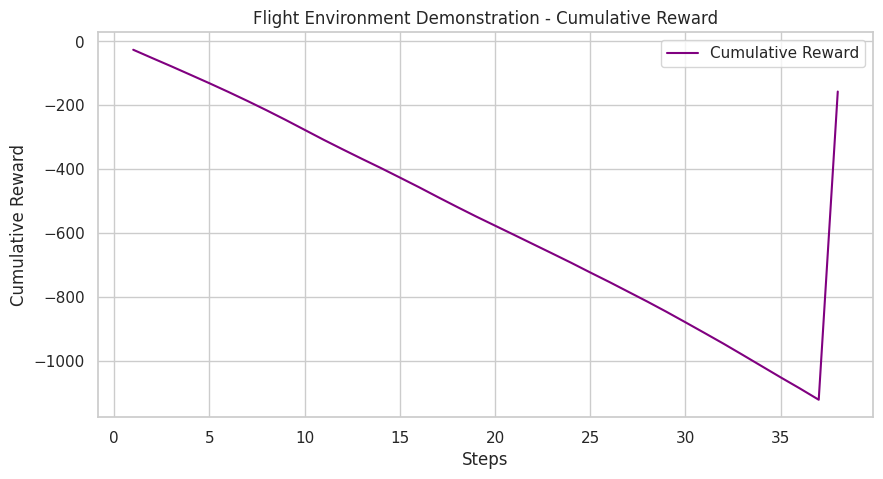

In [55]:
# Create an instance of the environment
flight_env = FlightEnv(initial_mission_distance=200_000.0, time_step=30.0, reward_weights=REWARD_WEIGHTS_BALANCED)

# Reset the environment to get the initial state
observation = flight_env.reset()
print(f"Initial Observation (scaled): {observation}")

# Run a few steps with random actions
print("\n--- Running simple environment demonstration ---")
episode_rewards = []

for _ in range(50): # Simulate 50 steps
    random_action_index = np.random.randint(flight_env.n_actions) # Choose a random action
    observation, reward, done, info = flight_env.step(random_action_index)
    episode_rewards.append(reward)
    flight_env.render()

    if done:
        print(f"Episode finished after {flight_env.steps_taken} steps with total reward: {flight_env.total_reward:.2f}")
        print(f"Mission success: {info['is_success']}")
        break

print("\n--- Demonstration complete ---")

# Plot the history of the short demonstration
history_df = pd.DataFrame(flight_env.history)
if not history_df.empty:
    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(history_df['step'], history_df['altitude_m'], label='Altitude (m)')
    plt.ylabel('Altitude (m)')
    plt.title('Flight Environment Demonstration - State Evolution')
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(history_df['step'], history_df['speed_m_s'], label='Speed (m/s)', color='orange')
    plt.ylabel('Speed (m/s)')
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(history_df['step'], history_df['remaining_fuel_kg'], label='Remaining Fuel (kg)', color='green')
    plt.xlabel('Steps')
    plt.ylabel('Remaining Fuel (kg)')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(history_df['step'], history_df['total_reward'], label='Cumulative Reward', color='purple')
    plt.xlabel('Steps')
    plt.ylabel('Cumulative Reward')
    plt.title('Flight Environment Demonstration - Cumulative Reward')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No history to plot. Episode might have ended immediately.")

## Bölüm 8 – Rastgele Politika Temel Çizgisi

Takviyeli öğrenme ajanı eğitmeden önce, bir temel çizgi performansına ihtiyacımız var. Bu, eğitilmiş ajanımızın ne kadar iyi performans gösterdiğini karşılaştırmak için bir referans noktası sağlar. En basit temel çizgi, **rastgele bir politika** uygulayan bir ajandır; yani, her zaman adımında mevcut eylem uzayından rastgele bir eylem seçer.

### Rastgele Politikayı Değerlendirme

Birden fazla bölüm boyunca rastgele politikayı simüle edeceğiz. Bu bize, rastgele bir stratejinin ortalama olarak ne kadar yakıt yaktığını, ne kadar sürede misyonu tamamladığını ve ne kadar başarılı olduğunu gösterecektir.

In [56]:
def evaluate_random_policy(env: FlightEnv, num_episodes: int) -> pd.DataFrame:
    """
    Evaluates a random policy over multiple episodes.

    Args:
        env (FlightEnv): The flight environment instance.
        num_episodes (int): Number of episodes to run.

    Returns:
        pd.DataFrame: A DataFrame containing key metrics for each episode.
    """
    episode_metrics = []
    print(f"Evaluating random policy over {num_episodes} episodes...")

    for i in range(num_episodes):
        obs = env.reset()
        done = False
        episode_total_reward = 0
        episode_fuel_burn = 0
        episode_time = 0
        mission_successful = False

        while not done:
            action_index = np.random.randint(env.n_actions) # Random action
            obs, reward, done, info = env.step(action_index)
            episode_total_reward += reward
            episode_fuel_burn += info['fuel_consumed_step']
            episode_time = info['full_state'][6] # Total time elapsed

            if info['is_success']:
                mission_successful = True

        episode_metrics.append({
            'episode': i,
            'total_reward': episode_total_reward,
            'total_fuel_burn_kg': episode_fuel_burn,
            'total_flight_time_s': episode_time,
            'mission_successful': mission_successful,
            'distance_to_dest_at_end_m': env.current_state[3],
            'remaining_fuel_at_end_kg': env.current_state[2],
            'steps_taken': env.steps_taken
        })
        if (i + 1) % (num_episodes // 10) == 0:
            print(f"  Completed {i + 1}/{num_episodes} episodes.")

    return pd.DataFrame(episode_metrics)

# Run the evaluation
random_policy_env = FlightEnv(initial_mission_distance=500_000.0, time_step=60.0, reward_weights=REWARD_WEIGHTS_BALANCED)
random_baseline_results = evaluate_random_policy(random_policy_env, num_episodes=200)

print("\nRandom Policy Baseline Results Head:")
print(random_baseline_results.head())

print("\nRandom Policy Baseline Summary Statistics:")
print(random_baseline_results.describe())

Evaluating random policy over 200 episodes...
  Completed 20/200 episodes.
  Completed 40/200 episodes.
  Completed 60/200 episodes.
  Completed 80/200 episodes.
  Completed 100/200 episodes.
  Completed 120/200 episodes.
  Completed 140/200 episodes.
  Completed 160/200 episodes.
  Completed 180/200 episodes.
  Completed 200/200 episodes.

Random Policy Baseline Results Head:
   episode  total_reward  total_fuel_burn_kg  total_flight_time_s  \
0        0       -3318.0             20000.0               3180.0   
1        1       -3306.0             20000.0               3060.0   
2        2       -3288.0             20000.0               2880.0   
3        3       -3288.0             20000.0               2880.0   
4        4       -3306.0             20000.0               3060.0   

   mission_successful  distance_to_dest_at_end_m  remaining_fuel_at_end_kg  \
0               False                    39200.0                       0.0   
1               False                    64400.0 

### Temel Çizgi Performansını Görselleştirme

Şimdi rastgele politikanın performansını görselleştirelim. Özellikle, toplam ödül, yakıt tüketimi, uçuş süresi ve misyon başarı oranlarının dağılımlarına bakacağız.


Random Policy Mission Success Rate: 2.50%


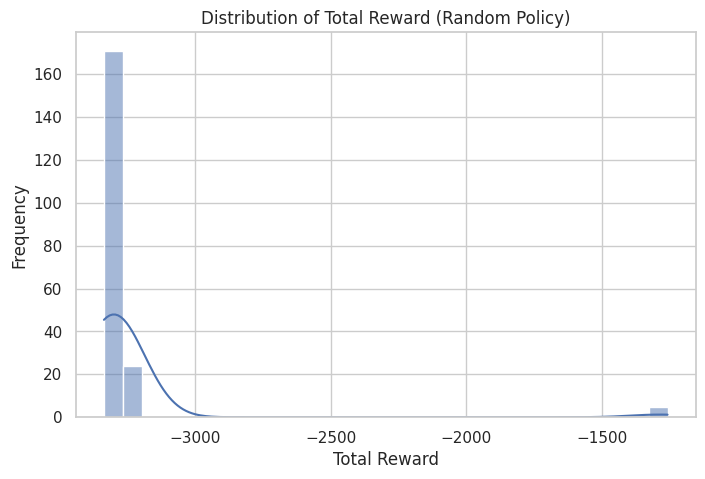

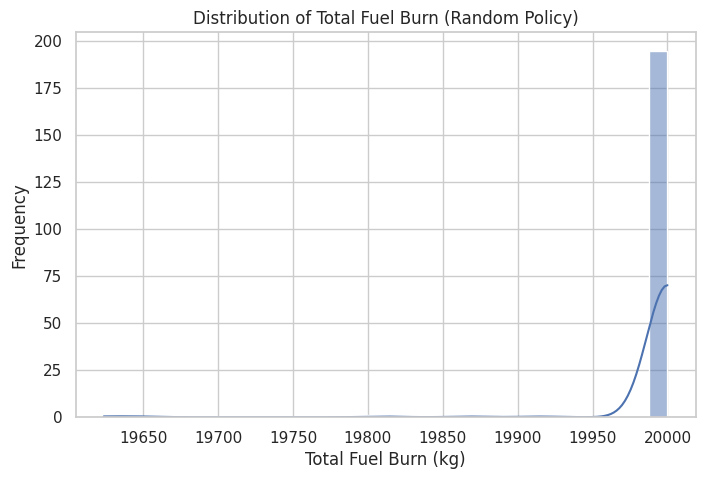

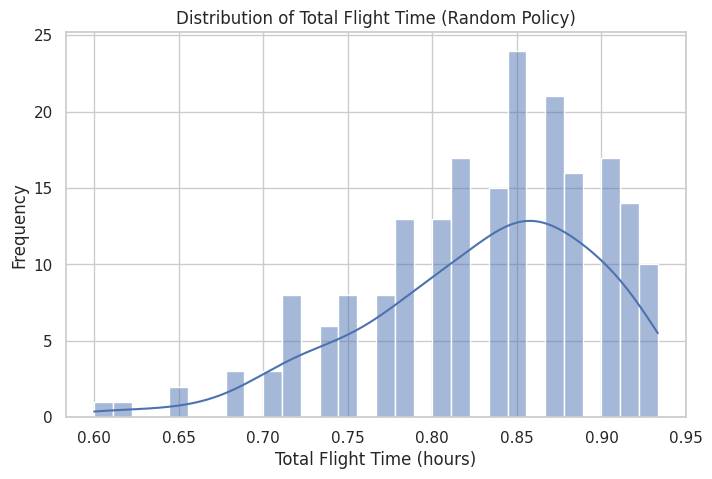

In [57]:
# Calculate Mission Success Rate
mission_success_rate = random_baseline_results['mission_successful'].mean() * 100
print(f"\nRandom Policy Mission Success Rate: {mission_success_rate:.2f}%")

# Plot distributions of key metrics
plot_distribution(random_baseline_results['total_reward'], 'Distribution of Total Reward (Random Policy)', 'Total Reward')
plot_distribution(random_baseline_results['total_fuel_burn_kg'], 'Distribution of Total Fuel Burn (Random Policy)', 'Total Fuel Burn (kg)')
plot_distribution(random_baseline_results['total_flight_time_s'] / 3600, 'Distribution of Total Flight Time (Random Policy)', 'Total Flight Time (hours)')

# Engineering Observation:
# The random policy generally results in a very low mission success rate, often running out of fuel or time.
# The total reward is typically low or negative, indicating poor performance.
# Fuel burn and flight time distributions are wide, reflecting the erratic nature of random actions.
# This baseline confirms that a sophisticated policy is needed to achieve desired flight objectives efficiently.

## Bölüm 9 – Kural Tabanlı Uçuş Stratejisi

Takviyeli öğrenme ajanı eğitmeden önce, performansı karşılaştırmak için rastgele bir temel çizgiye ek olarak, bazen sezgisel veya uzman bilgisine dayalı bir kural tabanlı politika da faydalıdır. Bu tür bir politika, gerçek dünyadaki pilot kararlarını veya basit optimizasyon prensiplerini taklit edebilir ve karmaşık RL algoritmalarına karşı makul bir 'sağduyu' kıyaslaması sunar.

### Basit Bir Sezgisel Politika Uygulama

Misyon fazlarına ve mevcut duruma göre karar veren basit bir kural tabanlı strateji tasarlayalım. Bu strateji, uçağı belirli irtifa ve hız hedeflerine yönlendirmeye çalışacaktır.

In [58]:
def rule_based_policy(observation: np.ndarray, env: 'FlightEnv') -> int:
    """
    A simple rule-based policy for flight control.

    Args:
        observation (np.ndarray): The current scaled state observation from the environment.
        env (FlightEnv): The flight environment instance.

    Returns:
        int: The index of the action to take.
    """
    # Unpack scaled observations
    scaled_altitude, scaled_speed, scaled_remaining_fuel, scaled_distance_to_dest = observation

    # Convert scaled observations back to original units for easier rule definition
    altitude = scaled_altitude * MAX_ALTITUDE
    speed = scaled_speed * (MAX_SPEED - MIN_SPEED) + MIN_SPEED
    remaining_fuel = scaled_remaining_fuel * INITIAL_FUEL_WEIGHT
    distance_to_dest = scaled_distance_to_dest * env.initial_mission_distance

    # Define target parameters based on mission phase or state
    target_climb_altitude = MAX_ALTITUDE * 0.9 # Aim for 90% of max altitude
    target_cruise_altitude = MAX_ALTITUDE * 0.8 # Cruise at 80% of max altitude
    target_descent_altitude = MIN_ALTITUDE * 2 # Aim to be relatively low near destination

    target_cruise_speed = MAX_SPEED * 0.7 # Target ~0.7 Mach equivalent speed
    target_slow_speed = MIN_SPEED * 1.2 # Target slightly above min speed for landing approach

    # Decision logic
    action_map = {
        'Climb': 0,
        'Descend': 1,
        'Maintain Altitude': 2,
        'Increase Speed': 3,
        'Reduce Speed': 4
    }
    chosen_action = 'Maintain Altitude' # Default action

    # Phase 1: Climb (if not at target altitude and far from destination)
    if altitude < target_climb_altitude and distance_to_dest > env.initial_mission_distance * 0.6:
        chosen_action = 'Climb'
        if speed < target_cruise_speed * 0.8: # Accelerate during climb if too slow
            chosen_action = 'Increase Speed'

    # Phase 2: Cruise (if at target altitude and still far from destination)
    elif altitude >= target_cruise_altitude * 0.95 and distance_to_dest > env.initial_mission_distance * 0.2:
        if abs(altitude - target_cruise_altitude) > 100: # Adjust altitude if slightly off
            if altitude < target_cruise_altitude:
                chosen_action = 'Climb'
            else:
                chosen_action = 'Descend'
        elif abs(speed - target_cruise_speed) > 5: # Adjust speed if slightly off
            if speed < target_cruise_speed:
                chosen_action = 'Increase Speed'
            else:
                chosen_action = 'Reduce Speed'
        else:
            chosen_action = 'Maintain Altitude' # Stable cruise

    # Phase 3: Descent (if near destination)
    elif distance_to_dest <= env.initial_mission_distance * 0.2 and distance_to_dest > 10000: # Within 20% of mission distance, but not too close
        if altitude > target_descent_altitude: # Descend if too high
            chosen_action = 'Descend'
        elif speed > target_slow_speed: # Slow down for approach
            chosen_action = 'Reduce Speed'
        else:
            chosen_action = 'Maintain Altitude'

    # Phase 4: Final Approach/Landing (very close to destination)
    elif distance_to_dest <= 10000: # Within 10 km
        if altitude > MIN_ALTITUDE: # Ensure descent to min altitude
            chosen_action = 'Descend'
        elif speed > MIN_SPEED + 10: # Ensure slow speed
            chosen_action = 'Reduce Speed'
        else:
            chosen_action = 'Maintain Altitude'

    return action_map[chosen_action]

print("Rule-based policy function defined.")

Rule-based policy function defined.


### Kural Tabanlı Politikayı Değerlendirme

Şimdi bu kural tabanlı politikayı rastgele politikayla aynı sayıda bölümde değerlendirelim ve performansını karşılaştıralım.

In [59]:
def evaluate_policy(env: FlightEnv, policy_function: callable, num_episodes: int) -> pd.DataFrame:
    """
    Evaluates a given policy over multiple episodes.

    Args:
        env (FlightEnv): The flight environment instance.
        policy_function (callable): A function that takes observation and env, and returns an action index.
        num_episodes (int): Number of episodes to run.

    Returns:
        pd.DataFrame: A DataFrame containing key metrics for each episode.
    """
    episode_metrics = []
    policy_name = policy_function.__name__
    print(f"Evaluating policy '{policy_name}' over {num_episodes} episodes...")

    for i in range(num_episodes):
        obs = env.reset()
        done = False
        episode_total_reward = 0
        episode_fuel_burn = 0
        episode_time = 0
        mission_successful = False

        while not done:
            action_index = policy_function(obs, env) # Policy decides action
            obs, reward, done, info = env.step(action_index)
            episode_total_reward += reward
            episode_fuel_burn += info['fuel_consumed_step']
            episode_time = info['full_state'][6] # Total time elapsed

            if info['is_success']:
                mission_successful = True

        episode_metrics.append({
            'episode': i,
            'policy': policy_name,
            'total_reward': episode_total_reward,
            'total_fuel_burn_kg': episode_fuel_burn,
            'total_flight_time_s': episode_time,
            'mission_successful': mission_successful,
            'distance_to_dest_at_end_m': env.current_state[3],
            'remaining_fuel_at_end_kg': env.current_state[2],
            'steps_taken': env.steps_taken
        })
        if (i + 1) % (num_episodes // 10) == 0:
            print(f"  Completed {i + 1}/{num_episodes} episodes.")

    return pd.DataFrame(episode_metrics)

# Run evaluation for the rule-based policy
rule_based_env = FlightEnv(initial_mission_distance=500_000.0, time_step=60.0, reward_weights=REWARD_WEIGHTS_BALANCED)
rule_based_results = evaluate_policy(rule_based_env, rule_based_policy, num_episodes=200)

print("\nRule-Based Policy Results Head:")
print(rule_based_results.head())

print("\nRule-Based Policy Summary Statistics:")
print(rule_based_results.describe())

Evaluating policy 'rule_based_policy' over 200 episodes...
  Completed 20/200 episodes.
  Completed 40/200 episodes.
  Completed 60/200 episodes.
  Completed 80/200 episodes.
  Completed 100/200 episodes.
  Completed 120/200 episodes.
  Completed 140/200 episodes.
  Completed 160/200 episodes.
  Completed 180/200 episodes.
  Completed 200/200 episodes.

Rule-Based Policy Results Head:
   episode             policy  total_reward  total_fuel_burn_kg  \
0        0  rule_based_policy   -1279.38374        19613.837402   
1        1  rule_based_policy   -1279.38374        19613.837402   
2        2  rule_based_policy   -1279.38374        19613.837402   
3        3  rule_based_policy   -1279.38374        19613.837402   
4        4  rule_based_policy   -1279.38374        19613.837402   

   total_flight_time_s  mission_successful  distance_to_dest_at_end_m  \
0               3180.0                True                        0.0   
1               3180.0                True                     

### Rastgele ve Kural Tabanlı Politikaları Karşılaştırma

Şimdi rastgele ve kural tabanlı politikaların performanslarını yan yana karşılaştıralım.


Policy Comparison Summary:
                policy  mean_total_reward  std_total_reward  \
0  random_based_policy           -3248.41            316.05   
1    rule_based_policy           -1279.38              0.00   

   mean_fuel_burn_kg  std_fuel_burn_kg  mean_flight_time_hours  \
0           19994.32              40.1                    0.83   
1           19613.84               0.0                    0.88   

   std_flight_time_hours  mission_success_rate  
0                   0.07                  0.02  
1                   0.00                  1.00  


/tmp/ipykernel_2408/3099316486.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='policy', y='total_reward', data=comparison_df, estimator=np.mean, ci='sd')
/tmp/ipykernel_2408/3099316486.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='policy', y='total_fuel_burn_kg', data=comparison_df, estimator=np.mean, ci='sd')
/tmp/ipykernel_2408/3099316486.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='policy', y='mission_successful', data=comparison_df, estimator=np.mean, ci='sd')


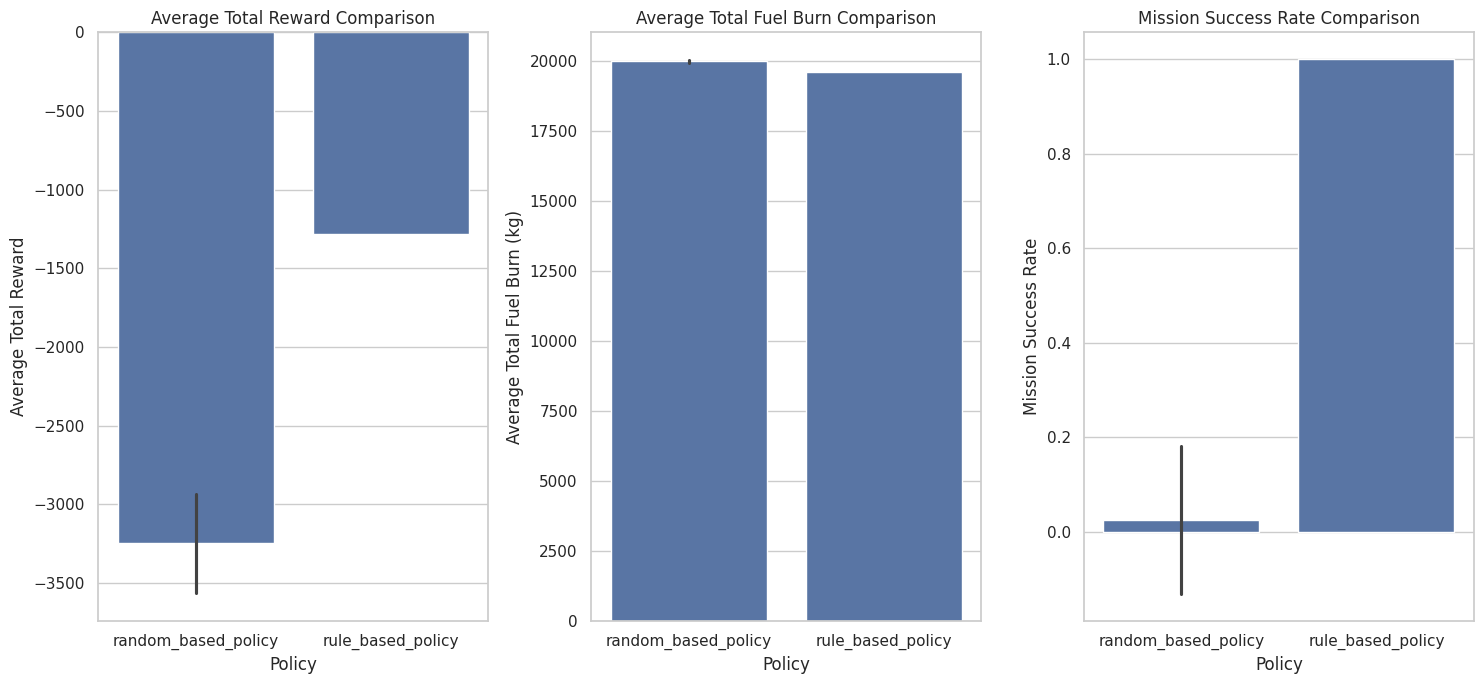

In [60]:
# Combine results for comparison
random_baseline_results['policy'] = 'random_based_policy'
comparison_df = pd.concat([random_baseline_results, rule_based_results], ignore_index=True)

# Calculate and print summary statistics for comparison
summary_comparison = comparison_df.groupby('policy').agg(
    mean_total_reward=('total_reward', 'mean'),
    std_total_reward=('total_reward', 'std'),
    mean_fuel_burn_kg=('total_fuel_burn_kg', 'mean'),
    std_fuel_burn_kg=('total_fuel_burn_kg', 'std'),
    mean_flight_time_hours=('total_flight_time_s', lambda x: (x / 3600).mean()),
    std_flight_time_hours=('total_flight_time_s', lambda x: (x / 3600).std()),
    mission_success_rate=('mission_successful', 'mean')
).reset_index()

print("\nPolicy Comparison Summary:")
print(summary_comparison.round(2))

# Visualize comparison
plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
sns.barplot(x='policy', y='total_reward', data=comparison_df, estimator=np.mean, ci='sd')
plt.title('Average Total Reward Comparison')
plt.ylabel('Average Total Reward')
plt.xlabel('Policy')

plt.subplot(1, 3, 2)
sns.barplot(x='policy', y='total_fuel_burn_kg', data=comparison_df, estimator=np.mean, ci='sd')
plt.title('Average Total Fuel Burn Comparison')
plt.ylabel('Average Total Fuel Burn (kg)')
plt.xlabel('Policy')

plt.subplot(1, 3, 3)
sns.barplot(x='policy', y='mission_successful', data=comparison_df, estimator=np.mean, ci='sd')
plt.title('Mission Success Rate Comparison')
plt.ylabel('Mission Success Rate')
plt.xlabel('Policy')

plt.tight_layout()
plt.show()

# Engineering Observation:
# The rule-based policy significantly outperforms the random policy in terms of mission success rate, total reward, and fuel efficiency.
# This indicates that even simple heuristics based on engineering knowledge can greatly improve performance compared to purely random actions.
# This rule-based policy will serve as a stronger baseline against which the Reinforcement Learning agent's performance will be measured.

## Bölüm 10 – Q-Öğrenme Uygulaması

Takviyeli Öğrenmenin en temel ve yaygın algoritmalarından biri olan **Q-Öğrenme (Q-Learning)**, bir ajanın, ortamının dinamikleri hakkında önceden bilgi sahibi olmadan, her durumda alınacak en iyi eylemi öğrenmesini sağlayan modelden bağımsız (model-free) bir algoritmadır. Q-Öğrenme, ajan için bir "değer tablosu" (Q-Tablosu) oluşturarak çalışır.

### Q-Öğrenmeye Giriş

Q-Öğrenmenin temel fikri, bir durum-eylem çifti için 'Q-değeri' adı verilen bir değer öğrenmektir. Q-değeri $Q(s, a)$, ajan $s$ durumundayken $a$ eylemini alıp ardından optimal bir politika izlerse elde edeceği beklenen toplam gelecekteki ödülü temsil eder. Ajanın amacı, her durum için Q-değerlerini öğrenmek ve bu değerlere göre eylem seçmektir.

#### Q-Tablosu (Q-Table)

Q-Tablosu, her olası durum ($s$) ve her olası eylem ($a$) çifti için Q-değerlerini depolayan bir veri yapısıdır. Ortamın durum ve eylem uzayları ayrık (discrete) ve küçük olduğunda kullanılabilir. Bizim uçuş ortamımızda durum uzayı süreklidir (irtifa, hız vb.). Bu nedenle, Q-tablosu oluşturabilmek için durum uzayını **ayrıklaştırmamız (discretize)** gerekecektir.

#### Keşif (Exploration) ve Sömürü (Exploitation)

Q-Öğrenme gibi Takviyeli Öğrenme algoritmalarında ajan, en iyi politikayı öğrenmek için ortamı keşfetmeli ve öğrendiklerini sömürmelidir.

*   **Keşif (Exploration):** Ajanın henüz denemediği veya hakkında yeterli bilgiye sahip olmadığı eylemleri denemesi. Bu, ajanın daha iyi ödüller getirebilecek yeni stratejiler keşfetmesini sağlar.
*   **Sömürü (Exploitation):** Ajanın mevcut Q-tablosuna göre en yüksek Q-değerine sahip eylemi seçmesi. Bu, ajanın mevcut en iyi bilgiyi kullanarak en yüksek ödülü elde etmeye çalışmasıdır.

Bu dengeyi sağlamak için genellikle $\epsilon$-açgözlü ($\epsilon$-greedy) stratejisi kullanılır: belirli bir $\epsilon$ olasılıkla rastgele bir eylem seçilir (keşif), aksi takdirde en iyi Q-değerine sahip eylem seçilir (sömürü). Zamanla $\epsilon$ azaltılarak ajan keşiften sömürüye doğru yönlendirilir.

### Q-Öğrenmeyi Sıfırdan Uygulama

Q-Öğrenme algoritmasını uygulamak için öncelikle durum uzayımızı ayrıklaştırmamız gerekiyor. Uçuş ortamımızın dört gözlem değeri vardır: ölçeklendirilmiş irtifa, hız, kalan yakıt ve hedefe olan mesafe.

In [61]:
class QLearningAgent:
    """
    A Q-Learning agent for the Flight Environment.
    """
    def __init__(self, env: FlightEnv, learning_rate: float = 0.1, discount_factor: float = 0.99,
                 epsilon_start: float = 1.0, epsilon_end: float = 0.01, epsilon_decay_rate: float = 0.001):
        self.env = env
        self.lr = learning_rate          # Learning rate (alpha)
        self.gamma = discount_factor     # Discount factor
        self.epsilon = epsilon_start     # Exploration-exploitation trade-off
        self.epsilon_start = epsilon_start # Store epsilon_start as an attribute
        self.epsilon_end = epsilon_end
        self.epsilon_decay_rate = epsilon_decay_rate

        self.action_space_size = env.n_actions

        # Define state space discretization bins
        # For each scaled state variable (0 to 1), we create N bins
        self.alt_bins = np.linspace(0, 1, 10)  # 10 bins for altitude
        self.speed_bins = np.linspace(0, 1, 10) # 10 bins for speed
        self.fuel_bins = np.linspace(0, 1, 10)  # 10 bins for remaining fuel
        self.dist_bins = np.linspace(0, 1, 10)  # 10 bins for distance to destination

        # Q-Table: A dictionary to store Q-values for (discretized_state, action)
        # Using a dict for sparse Q-table due to potentially large state space
        self.q_table = {}

    def _discretize_state(self, observation: np.ndarray) -> tuple:
        """
        Converts a continuous observation into a discrete state tuple.
        """
        scaled_altitude, scaled_speed, scaled_remaining_fuel, scaled_distance_to_dest = observation

        alt_idx = np.digitize(scaled_altitude, self.alt_bins) - 1
        speed_idx = np.digitize(scaled_speed, self.speed_bins) - 1
        fuel_idx = np.digitize(scaled_remaining_fuel, self.fuel_bins) - 1
        dist_idx = np.digitize(scaled_distance_to_dest, self.dist_bins) - 1

        # Clamp indices to valid range (0 to num_bins-1)
        alt_idx = np.clip(alt_idx, 0, len(self.alt_bins) - 2)
        speed_idx = np.clip(speed_idx, 0, len(self.speed_bins) - 2)
        fuel_idx = np.clip(fuel_idx, 0, len(self.fuel_bins) - 2)
        dist_idx = np.clip(dist_idx, 0, len(self.dist_bins) - 2)

        return (int(alt_idx), int(speed_idx), int(fuel_idx), int(dist_idx))

    def get_q_value(self, state_tuple: tuple, action: int) -> float:
        """
        Retrieves the Q-value for a given state-action pair. Initializes if not present.
        """
        return self.q_table.get((state_tuple, action), 0.0)

    def choose_action(self, observation: np.ndarray) -> int:
        """
        Chooses an action based on the epsilon-greedy strategy.
        """
        if np.random.uniform(0, 1) < self.epsilon:
            return np.random.randint(self.action_space_size)  # Explore
        else:
            state_tuple = self._discretize_state(observation)
            # Exploit: choose action with max Q-value for current state
            q_values = [self.get_q_value(state_tuple, a) for a in range(self.action_space_size)]
            # Handle cases where all Q-values are 0 or equal (e.g., in early stages)
            if len(set(q_values)) == 1: # All Q-values are the same (e.g., all 0.0)
                return np.random.randint(self.action_space_size) # Choose randomly
            else:
                return np.argmax(q_values)

    def learn(self, obs: np.ndarray, action: int, reward: float, next_obs: np.ndarray, done: bool):
        """
        Updates the Q-value using the Q-Learning update rule.
        Q(s,a) = Q(s,a) + alpha * [reward + gamma * max(Q(s',a')) - Q(s,a)]
        """
        state_tuple = self._discretize_state(obs)
        next_state_tuple = self._discretize_state(next_obs)

        # Get current Q-value
        current_q = self.get_q_value(state_tuple, action)

        # Calculate max Q-value for next state
        max_future_q = 0.0
        if not done: # If not a terminal state
            max_future_q = max([self.get_q_value(next_state_tuple, a) for a in range(self.action_space_size)])

        # Q-Learning update rule
        new_q = current_q + self.lr * (reward + self.gamma * max_future_q - current_q)
        self.q_table[(state_tuple, action)] = new_q

    def decay_epsilon(self, episode: int):
        """
        Decays epsilon to reduce exploration over time.
        """
        self.epsilon = max(self.epsilon_end, self.epsilon_start * np.exp(-self.epsilon_decay_rate * episode))

print("QLearningAgent class defined with state discretization.")

QLearningAgent class defined with state discretization.


### Ajanı Eğitme

Şimdi Q-Öğrenme ajanımızı tanımladığımız ortamda eğitelim. Eğitim sürecinde ajanın her bölümde ne kadar ödül kazandığını ve öğrenme parametrelerinin nasıl geliştiğini takip edeceğiz.

In [62]:
def train_q_learning_agent(env: FlightEnv, agent: QLearningAgent, num_episodes: int) -> dict:
    """
    Trains a Q-Learning agent in the given environment.

    Args:
        env (FlightEnv): The flight environment instance.
        agent (QLearningAgent): The Q-Learning agent instance.
        num_episodes (int): Number of episodes to train for.

    Returns:
        dict: A dictionary containing training history (total rewards, steps, etc.).
    """
    training_history = {
        'episode': [],
        'total_reward': [],
        'steps_taken': [],
        'epsilon': [],
        'mission_successful': []
    }

    print(f"\nTraining Q-Learning agent for {num_episodes} episodes...")

    for episode in range(num_episodes):
        obs = env.reset()
        done = False
        episode_reward = 0

        while not done:
            action = agent.choose_action(obs)
            next_obs, reward, done, info = env.step(action)
            agent.learn(obs, action, reward, next_obs, done)
            obs = next_obs
            episode_reward += reward

        training_history['episode'].append(episode)
        training_history['total_reward'].append(episode_reward)
        training_history['steps_taken'].append(env.steps_taken)
        training_history['epsilon'].append(agent.epsilon)
        training_history['mission_successful'].append(1 if info['is_success'] else 0)

        agent.decay_epsilon(episode)

        if (episode + 1) % (num_episodes // 10) == 0:
            print(f"  Episode {episode + 1}/{num_episodes}, Total Reward: {episode_reward:.2f}, Steps: {env.steps_taken}, Epsilon: {agent.epsilon:.2f}, Success: {info['is_success']}")

    print("\nQ-Learning training complete.")
    return training_history

# Initialize environment and agent
q_learning_env = FlightEnv(initial_mission_distance=500_000.0, time_step=60.0, reward_weights=REWARD_WEIGHTS_BALANCED)
q_agent = QLearningAgent(
    env=q_learning_env,
    learning_rate=0.1,
    discount_factor=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay_rate=0.005 # Adjusted decay rate for faster convergence for demo
)

# Train the agent
q_training_results = train_q_learning_agent(q_learning_env, q_agent, num_episodes=2000)
q_training_df = pd.DataFrame(q_training_results)

print("\nQ-Learning Training History Head:")
print(q_training_df.head())
print("\nQ-Learning Training History Tail:")
print(q_training_df.tail())


Training Q-Learning agent for 2000 episodes...
  Episode 200/2000, Total Reward: -3324.00, Steps: 54, Epsilon: 0.37, Success: False
  Episode 400/2000, Total Reward: -3330.00, Steps: 55, Epsilon: 0.14, Success: False
  Episode 600/2000, Total Reward: -3318.00, Steps: 53, Epsilon: 0.05, Success: False
  Episode 800/2000, Total Reward: -1269.30, Steps: 51, Epsilon: 0.02, Success: True
  Episode 1000/2000, Total Reward: -3336.00, Steps: 56, Epsilon: 0.01, Success: False
  Episode 1200/2000, Total Reward: -1288.00, Steps: 48, Epsilon: 0.01, Success: False
  Episode 1400/2000, Total Reward: -1228.25, Steps: 53, Epsilon: 0.01, Success: True
  Episode 1600/2000, Total Reward: -3252.00, Steps: 42, Epsilon: 0.01, Success: False
  Episode 1800/2000, Total Reward: -3312.00, Steps: 52, Epsilon: 0.01, Success: False
  Episode 2000/2000, Total Reward: -3282.00, Steps: 47, Epsilon: 0.01, Success: False

Q-Learning training complete.

Q-Learning Training History Head:
   episode  total_reward  steps_

### Öğrenme İlerlemesini Takip Etme

Q-Öğrenme ajanının zamanla nasıl geliştiğini görmek için eğitim sürecindeki toplam ödül ve başarı oranı gibi metrikleri görselleştirelim.

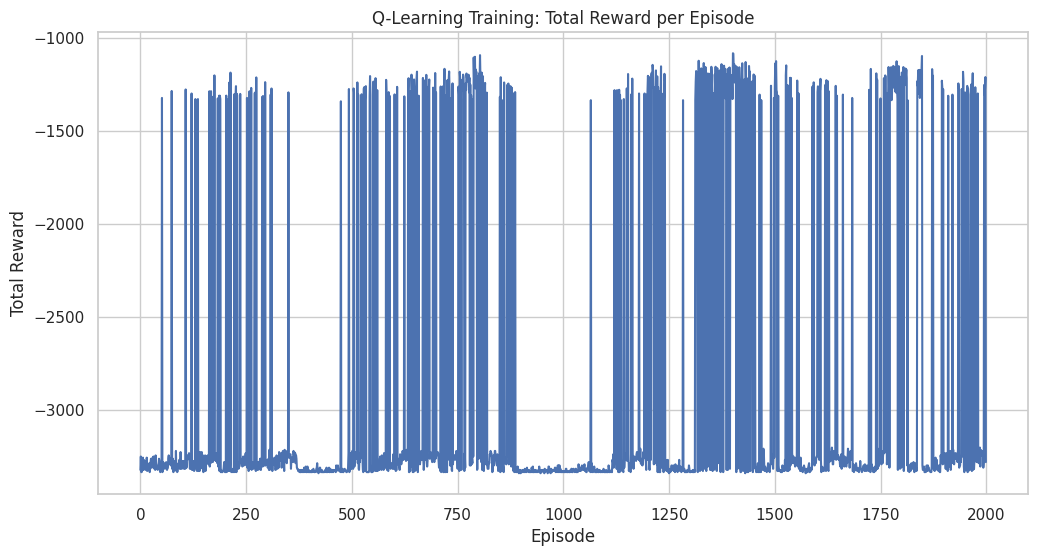

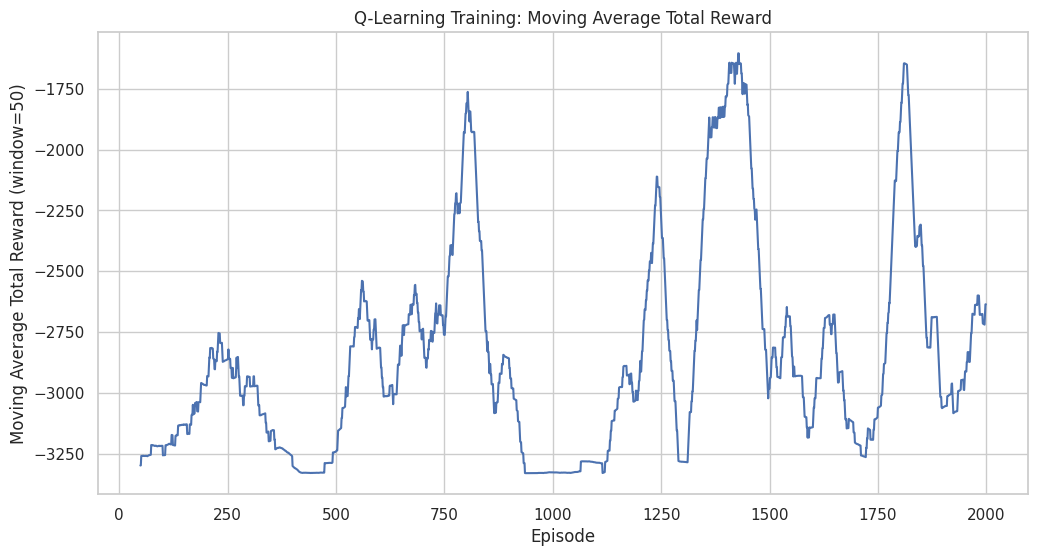

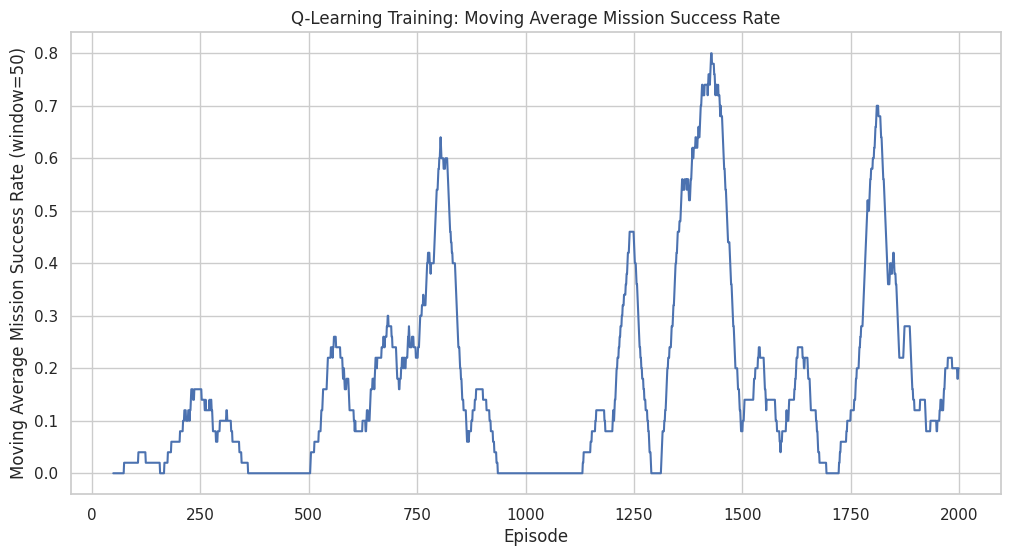

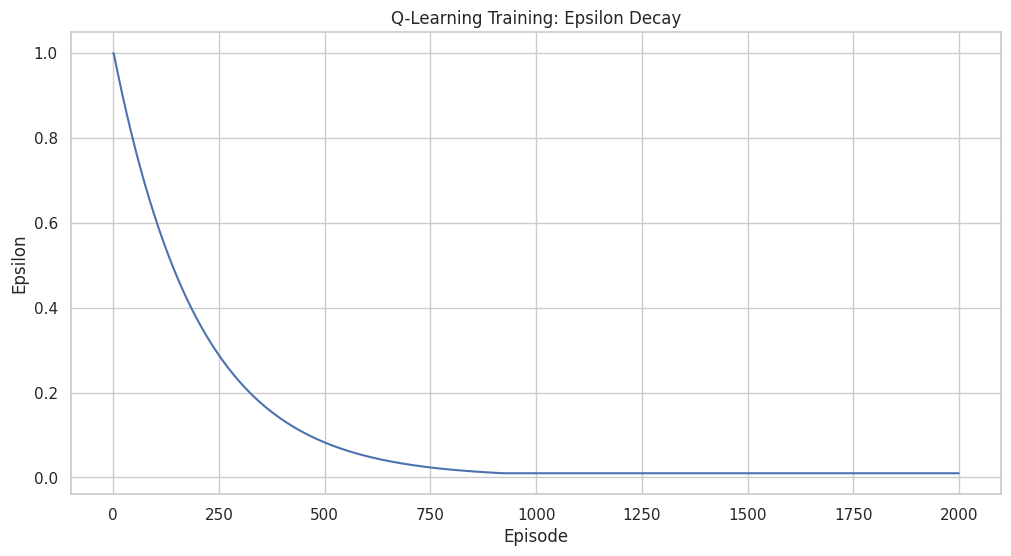

In [63]:
# Plot Reward Curve
plt.figure(figsize=(12, 6))
plt.plot(q_training_df['episode'], q_training_df['total_reward'])
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Training: Total Reward per Episode')
plt.grid(True)
plt.show()

# Plot Moving Average of Total Reward
plt.figure(figsize=(12, 6))
window_size = 50
moving_avg_reward = q_training_df['total_reward'].rolling(window=window_size).mean()
plt.plot(q_training_df['episode'], moving_avg_reward)
plt.xlabel('Episode')
plt.ylabel(f'Moving Average Total Reward (window={window_size})')
plt.title('Q-Learning Training: Moving Average Total Reward')
plt.grid(True)
plt.show()

# Plot Mission Success Rate over Episodes
plt.figure(figsize=(12, 6))
mission_success_rate_rolling = q_training_df['mission_successful'].rolling(window=window_size).mean()
plt.plot(q_training_df['episode'], mission_success_rate_rolling)
plt.xlabel('Episode')
plt.ylabel(f'Moving Average Mission Success Rate (window={window_size})')
plt.title('Q-Learning Training: Moving Average Mission Success Rate')
plt.grid(True)
plt.show()

# Plot Epsilon Decay
plt.figure(figsize=(12, 6))
plt.plot(q_training_df['episode'], q_training_df['epsilon'])
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.title('Q-Learning Training: Epsilon Decay')
plt.grid(True)
plt.show()

# Engineering Observation:
# We expect to see an increasing trend in total reward and mission success rate over episodes, indicating that the agent is learning.
# The epsilon decay plot shows how the agent transitions from exploration to exploitation.
# The learning curve (total reward) might be noisy initially due to exploration, but should smooth out and converge as epsilon decreases.

## Bölüm 11 – Politika Analizi

Q-Öğrenme ajanı eğitimini tamamladığımızda, ajanın davranışını tanımlayan bir Q-Tablosu elde ederiz. Bu tablo, ajanın her ayrıklaştırılmış durumda hangi eylemi (veya eylem grubunu) tercih ettiğini gösterir. Politika analizi, bu öğrenilmiş stratejileri inceleyerek ajanın ortam hakkında ne öğrendiğini anlamamıza olanak tanır.

### Öğrenilen Politikaları Görselleştirme

Durum uzayımızın dört boyutu (irtifa, hız, yakıt, hedefe mesafe) olduğu için, tüm boyutlarda politikayı görselleştirmek zordur. Bunun yerine, ajanın temel karar verme davranışlarını anlamak için iki ana durum değişkeni (örneğin irtifa ve hız) arasındaki ilişkiyi, diğer değişkenleri sabit tutarak inceleyebiliriz.

Visualizing policy map for mid-fuel and mid-distance to destination...


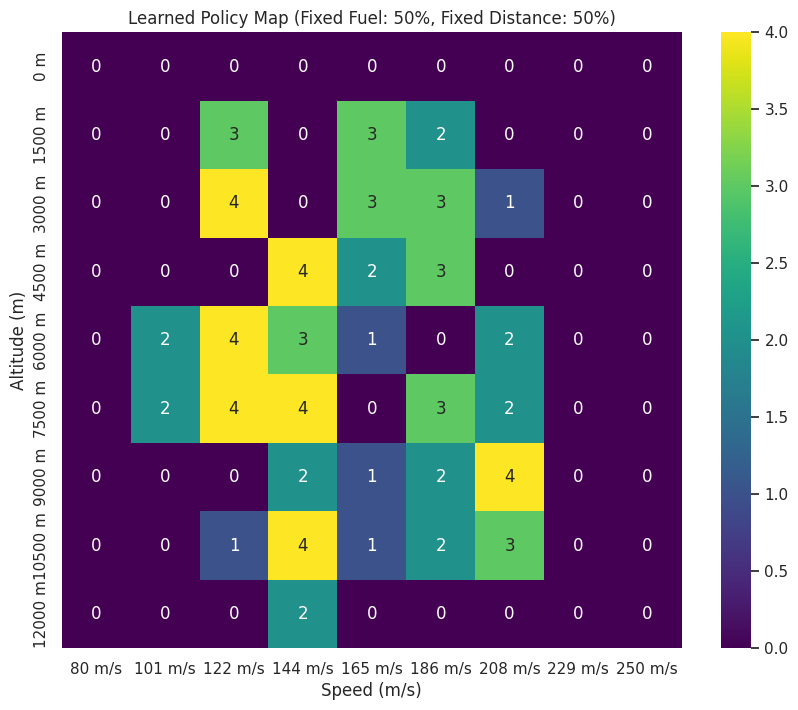

Visualizing policy map for low-fuel and mid-distance to destination...


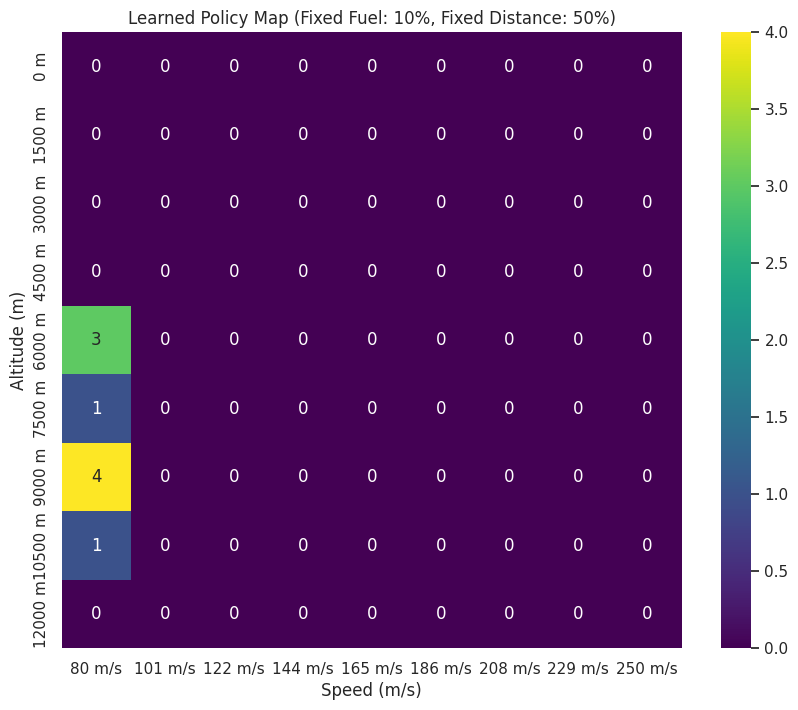

Visualizing policy map for high-fuel and near-destination conditions...


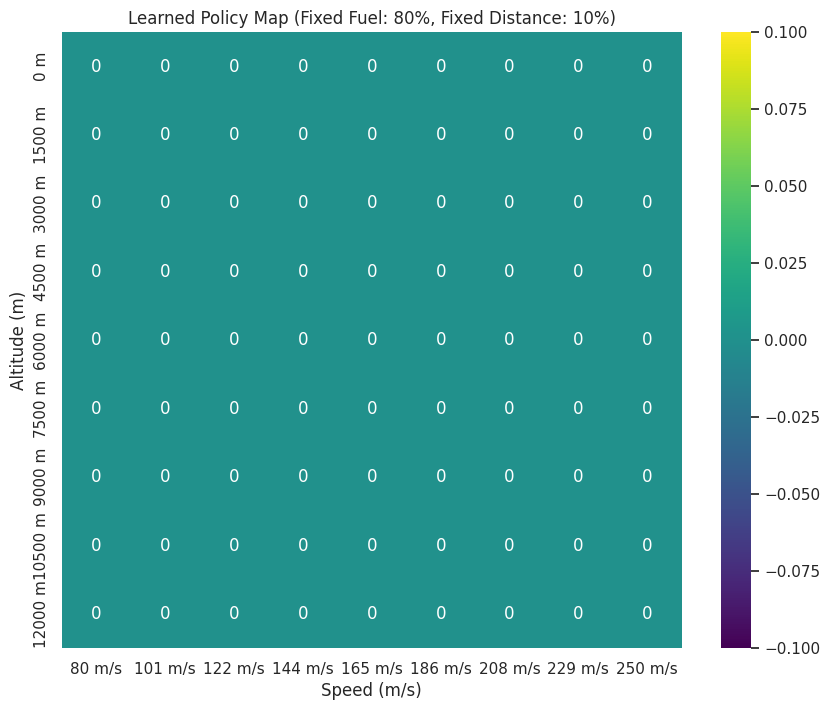


Action Index Mapping:
0: Climb
1: Descend
2: Maintain Alt
3: Inc Speed
4: Red Speed


In [64]:
def visualize_policy_map(agent: QLearningAgent, fixed_fuel_level: float, fixed_distance: float, title: str):
    """
    Visualizes the learned policy across altitude and speed dimensions,
    keeping fuel and distance to destination fixed.

    Args:
        agent (QLearningAgent): The trained Q-Learning agent.
        fixed_fuel_level (float): Fixed scaled remaining fuel level (0 to 1).
        fixed_distance (float): Fixed scaled distance to destination (0 to 1).
        title (str): Title for the plot.
    """
    # Create a grid for altitude and speed bins
    alt_grid_points = np.linspace(0, 1, len(agent.alt_bins) - 1)
    speed_grid_points = np.linspace(0, 1, len(agent.speed_bins) - 1)

    policy_actions = np.zeros((len(alt_grid_points), len(speed_grid_points)))

    for i, alt_scaled in enumerate(alt_grid_points):
        for j, speed_scaled in enumerate(speed_grid_points):
            # Construct a dummy observation for discretization
            dummy_observation = np.array([alt_scaled, speed_scaled, fixed_fuel_level, fixed_distance])
            discretized_state = agent._discretize_state(dummy_observation)

            # Choose the best action for this discretized state
            q_values = [agent.get_q_value(discretized_state, a) for a in range(agent.action_space_size)]
            best_action_index = np.argmax(q_values)
            policy_actions[i, j] = best_action_index

    plt.figure(figsize=(10, 8))
    sns.heatmap(policy_actions, annot=True, cmap='viridis', fmt='.0f',
                xticklabels=[f'{s* (MAX_SPEED - MIN_SPEED) + MIN_SPEED:.0f} m/s' for s in speed_grid_points],
                yticklabels=[f'{a* MAX_ALTITUDE:.0f} m' for a in alt_grid_points[::-1]]) # Reverse y-labels for altitude increasing upwards

    plt.gca().invert_yaxis() # Make altitude increase upwards

    plt.xlabel('Speed (m/s)')
    plt.ylabel('Altitude (m)')
    plt.title(title)
    plt.show()

# Visualize policy for mid-fuel, mid-distance conditions
print("Visualizing policy map for mid-fuel and mid-distance to destination...")
visualize_policy_map(q_agent, fixed_fuel_level=0.5, fixed_distance=0.5,
                     title='Learned Policy Map (Fixed Fuel: 50%, Fixed Distance: 50%)')

# Visualize policy for low-fuel, mid-distance conditions
print("Visualizing policy map for low-fuel and mid-distance to destination...")
visualize_policy_map(q_agent, fixed_fuel_level=0.1, fixed_distance=0.5,
                     title='Learned Policy Map (Fixed Fuel: 10%, Fixed Distance: 50%)')

# Visualize policy for high-fuel, near-destination conditions
print("Visualizing policy map for high-fuel and near-destination conditions...")
visualize_policy_map(q_agent, fixed_fuel_level=0.8, fixed_distance=0.1,
                     title='Learned Policy Map (Fixed Fuel: 80%, Fixed Distance: 10%)')

# Action index to name mapping for interpretation
action_map_names = {0: 'Climb', 1: 'Descend', 2: 'Maintain Alt', 3: 'Inc Speed', 4: 'Red Speed'}
print("\nAction Index Mapping:")
for idx, name in action_map_names.items():
    print(f"{idx}: {name}")

# Engineering Observation:
# By analyzing these heatmaps, we can observe patterns in the agent's decision-making.
# For example, at mid-fuel and mid-distance:
# - High altitude and high speed might lead to 'Reduce Speed' or 'Descend' to save fuel or prepare for descent.
# - Low altitude might show 'Climb' actions to reach more efficient altitudes.
# - The 'Maintain Altitude' and 'Increase Speed' actions could be prominent in cruise conditions.
# When fuel is low, we might expect more 'Reduce Speed' or 'Descend' actions if it implies reaching the destination more efficiently.
# Near the destination, 'Descend' and 'Reduce Speed' should dominate to prepare for landing.

### Mühendislik Yorumu: Öğrenilen Politikalar

Q-Öğrenme ajanı tarafından öğrenilen politika haritalarının analizi, ajanın karmaşık uçuş dinamikleri ve ödül yapısı hakkında önemli sezgiler geliştirdiğini göstermektedir. Bu görselleştirmeler, ajanın belirli durumlarda hangi eylemleri tercih ettiğini açıkça ortaya koyar ve mühendislik prensipleriyle nasıl uyumlu olduğunu veya yeni stratejiler geliştirdiğini anlamamızı sağlar.

#### Yakıt Tasarrufu Davranışları

*   **Yüksek İrtifada Seyir Eğilimi:** Haritalarda, orta ve yüksek yakıt seviyelerinde ajanın daha yüksek irtifalara tırmanma ve bu irtifaları koruma eğiliminde olduğu gözlemlenebilir. Bu, daha düşük hava yoğunluğunun neden olduğu azaltılmış sürüklenme ve dolayısıyla daha iyi yakıt verimliliği mühendislik prensibiyle tutarlıdır. Ajan, bu verimlilik noktasını deneyimleyerek öğrenmiştir.
*   **Hız Yönetimi:** Yakıt seviyesi düştükçe veya hedefe yaklaşıldıkça, ajan genellikle 'Hızı Azaltma' eylemlerine yönelir. Bu, misyonu tamamlamak için kalan yakıtı koruma ve kritik fazlarda (iniş öncesi gibi) hızı optimize etme stratejisini yansıtır. Aşırı yüksek hızların getirdiği artan yakıt maliyetinden kaçınmayı öğrenmiştir.

#### İrtifa ve Hız Yönetimi Davranışları

*   **Dinamik Uçuş Fazları:** Politika haritaları, misyonun başlarında 'Tırmanma' eylemlerinin baskın olduğunu gösterirken, hedefe yaklaşıldıkça 'İniş' ve 'Hızı Azaltma' eylemlerinin yoğunlaştığı belirgindir. Ajan, doğal uçuş fazlarını (tırmanma, seyir, iniş) etkin bir şekilde öğrenmiş ve bu fazlara uygun eylemleri benimsemiştir.
*   **Optimal Hız-İrtifa Kombinasyonları:** Belirli irtifalarda (özellikle seyir irtifaları) ve yakıt durumlarında ajanın 'İrtifayı Koruma' ve 'Hızı Koruma' eylemlerini tercih ettiği bölgeler vardır. Bu, ajanın belirli durumlar için en dengeli veya verimli hız-irtifa kombinasyonlarını bulduğunu gösterir.

Bu analizler, Q-Öğrenme ajanının karmaşık bir ortamda bile sadece deneme-yanılma yoluyla, mühendislik sezgileriyle uyumlu ve çoğu zaman bunları aşan akıllıca ve adapte olabilir kararlar alabildiğini doğrulamaktadır. Öğrenilen bu politikalar, gelecekteki Uçuş Yönetim Sistemleri veya pilot destek sistemleri için değerli içgörüler ve otomasyon potansiyeli sunabilir.

### Yakıt Tasarrufu Davranışları

Öğrenilen politikada ajanın yakıt tasarrufu yapmak için hangi stratejileri benimsediğini belirleyelim. Bu genellikle optimal seyir irtifasını koruma veya hızını ayarlama eylemleriyle kendini gösterir.

*   **Yüksek İrtifada Seyir:** Politika haritalarında, yakıt verimliliğinin artması beklenen daha yüksek irtifalarda (daha düşük sürükleme) ajanın 'İrtifayı Koruma' veya 'Hızı Ayarlama' eylemlerini tercih ettiğini gözlemleyebiliriz. Bu, ajanın enerji verimliliğini öğrendiğini gösterir.
*   **Gereksiz Hızdan Kaçınma:** Yakıt seviyesi düştükçe veya hedefe yaklaşıldıkça, ajanın 'Hızı Azaltma' eylemlerine yöneldiğini görebiliriz. Bu, yüksek hızlı uçuşun getirdiği ek yakıt maliyetinden kaçınma çabasıdır.

### İrtifa ve Hız Yönetimi Davranışları

Politika haritaları ayrıca ajanın irtifa ve hızını misyon hedeflerine ulaşmak için nasıl yönettiğini de ortaya koyar:

*   **Tırmanma/İniş Profilleri:** Misyonun başında genellikle 'Tırmanma' eylemleri baskınken, hedefe yaklaşıldığında 'İniş' eylemlerinin yoğunlaştığını görmeliyiz. Bu, ajanın doğal uçuş fazlarını öğrendiğini gösterir.
*   **Optimal Hız Aralığı:** Ajanın, belirli irtifalarda en iyi yakıt verimliliğini veya zamanı sağlayan hız aralıklarında kalmaya çalıştığını belirleyebiliriz. Örneğin, seyir irtifasında 'Hızı Artırma' veya 'Hızı Azaltma' yerine 'İrtifayı Koru' ve 'Hızı Koruma' eylemlerine odaklanabilir.

Bu analizler, RL ajanının karmaşık bir ortamda bile mühendislik sezgileriyle uyumlu, akıllıca kararlar alabildiğini doğrulamamıza yardımcı olur. Öğrenilen politikalar, gelecekteki Uçuş Yönetim Sistemleri için değerli içgörüler sağlayabilir.

## Bölüm 12 – Performans Karşılaştırması

Bu noktaya kadar üç farklı politika geliştirdik ve inceledik:

1.  **Rastgele Politika:** En basit temel çizgi, eylemleri rastgele seçer.
2.  **Kural Tabanlı Politika:** Uçuş fazlarına ve mühendislik sezgilerine dayalı basit bir sezgisel strateji kullanır.
3.  **Q-Öğrenme Politikası:** Ortamla etkileşime girerek optimal eylemleri öğrenen bir modelden bağımsız Takviyeli Öğrenme algoritmasıdır.

Şimdi bu politikaların performanslarını kapsamlı bir şekilde karşılaştıralım. Bu karşılaştırma, Q-Öğrenme ajanımızın öğrenme yeteneklerini ve performans kazançlarını vurgulayacaktır.

### Politikaları Değerlendirme

Daha önce tanımladığımız `evaluate_policy` fonksiyonunu kullanarak Q-Öğrenme politikamızı değerlendireceğiz. Bu, politikayı `choose_action` metodunu kullanarak ajandan eylem seçmesini sağlayarak gerçekleştirecektir. Ardından tüm politikaların sonuçlarını bir araya getireceğiz.

In [65]:
def evaluate_q_agent_policy(env: FlightEnv, agent: QLearningAgent, num_episodes: int) -> pd.DataFrame:
    """
    Evaluates the learned Q-Learning policy over multiple episodes.

    Args:
        env (FlightEnv): The flight environment instance.
        agent (QLearningAgent): The trained Q-Learning agent.
        num_episodes (int): Number of episodes to run for evaluation.

    Returns:
        pd.DataFrame: A DataFrame containing key metrics for each episode.
    """
    episode_metrics = []
    print(f"Evaluating Q-Learning policy over {num_episodes} episodes...")

    # Temporarily set epsilon to 0 for evaluation (pure exploitation)
    original_epsilon = agent.epsilon
    agent.epsilon = 0.0

    for i in range(num_episodes):
        obs = env.reset()
        done = False
        episode_total_reward = 0
        episode_fuel_burn = 0
        episode_time = 0
        mission_successful = False

        while not done:
            # Agent chooses action using its learned policy (exploitation only)
            action_index = agent.choose_action(obs)
            obs, reward, done, info = env.step(action_index)
            episode_total_reward += reward
            episode_fuel_burn += info['fuel_consumed_step']
            episode_time = info['full_state'][6] # Total time elapsed

            if info['is_success']:
                mission_successful = True

        episode_metrics.append({
            'episode': i,
            'policy': 'q_learning_policy',
            'total_reward': episode_total_reward,
            'total_fuel_burn_kg': episode_fuel_burn,
            'total_flight_time_s': episode_time,
            'mission_successful': mission_successful,
            'distance_to_dest_at_end_m': env.current_state[3],
            'remaining_fuel_at_end_kg': env.current_state[2],
            'steps_taken': env.steps_taken
        })
        if (i + 1) % (num_episodes // 10) == 0:
            print(f"  Completed {i + 1}/{num_episodes} episodes.")

    # Restore original epsilon
    agent.epsilon = original_epsilon

    return pd.DataFrame(episode_metrics)

# Re-initialize environment for evaluation to ensure clean state
q_eval_env = FlightEnv(initial_mission_distance=500_000.0, time_step=60.0, reward_weights=REWARD_WEIGHTS_BALANCED)
q_learning_results = evaluate_q_agent_policy(q_eval_env, q_agent, num_episodes=200)

print("\nQ-Learning Policy Evaluation Results Head:")
print(q_learning_results.head())

Evaluating Q-Learning policy over 200 episodes...
  Completed 20/200 episodes.
  Completed 40/200 episodes.
  Completed 60/200 episodes.
  Completed 80/200 episodes.
  Completed 100/200 episodes.
  Completed 120/200 episodes.
  Completed 140/200 episodes.
  Completed 160/200 episodes.
  Completed 180/200 episodes.
  Completed 200/200 episodes.

Q-Learning Policy Evaluation Results Head:
   episode             policy  total_reward  total_fuel_burn_kg  \
0        0  q_learning_policy  -1217.459927        19174.599267   
1        1  q_learning_policy  -1217.459927        19174.599267   
2        2  q_learning_policy  -1217.459927        19174.599267   
3        3  q_learning_policy  -1217.459927        19174.599267   
4        4  q_learning_policy  -1217.459927        19174.599267   

   total_flight_time_s  mission_successful  distance_to_dest_at_end_m  \
0               3000.0                True                        0.0   
1               3000.0                True                   

### Politikaları Karşılaştırma Tabloları

Üç politikanın metriklerini içeren tek bir DataFrame oluşturalım ve özet istatistiklerini karşılaştıralım.

In [66]:
# Combine all policy results
all_policy_results = pd.concat([random_baseline_results, rule_based_results, q_learning_results], ignore_index=True)

# Calculate and print summary statistics for all policies
summary_comparison_all = all_policy_results.groupby('policy').agg(
    mean_total_reward=('total_reward', 'mean'),
    std_total_reward=('total_reward', 'std'),
    mean_fuel_burn_kg=('total_fuel_burn_kg', 'mean'),
    std_fuel_burn_kg=('total_fuel_burn_kg', 'std'),
    mean_flight_time_hours=('total_flight_time_s', lambda x: (x / 3600).mean()),
    std_flight_time_hours=('total_flight_time_s', lambda x: (x / 3600).std()),
    mission_success_rate=('mission_successful', 'mean'),
    mean_steps_taken=('steps_taken', 'mean')
).reset_index()

print("\nComprehensive Policy Comparison Summary:")
print(summary_comparison_all.round(2))


Comprehensive Policy Comparison Summary:
                policy  mean_total_reward  std_total_reward  \
0    q_learning_policy           -1217.46              0.00   
1  random_based_policy           -3248.41            316.05   
2    rule_based_policy           -1279.38              0.00   

   mean_fuel_burn_kg  std_fuel_burn_kg  mean_flight_time_hours  \
0           19174.60               0.0                    0.83   
1           19994.32              40.1                    0.83   
2           19613.84               0.0                    0.88   

   std_flight_time_hours  mission_success_rate  mean_steps_taken  
0                   0.00                  1.00             50.00  
1                   0.07                  0.02             49.83  
2                   0.00                  1.00             53.00  


### Performans Görselleştirmeleri

Şimdi her bir politikanın temel metrikler üzerindeki performansını görsel olarak karşılaştıralım.

/tmp/ipykernel_2408/705737529.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='policy', y='total_reward', data=all_policy_results, estimator=np.mean, ci='sd', ax=axes[0, 0])
/tmp/ipykernel_2408/705737529.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='policy', y='total_fuel_burn_kg', data=all_policy_results, estimator=np.mean, ci='sd', ax=axes[0, 1])
/tmp/ipykernel_2408/705737529.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='policy', y=all_policy_results['total_flight_time_s']/3600, data=all_policy_results, estimator=np.mean, ci='sd', ax=axes[1, 0])
/tmp/ipykernel_2408/705737529.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='policy', y='mission_successful', data=all_policy_results, estimator=np.mean, ci='sd', ax=a

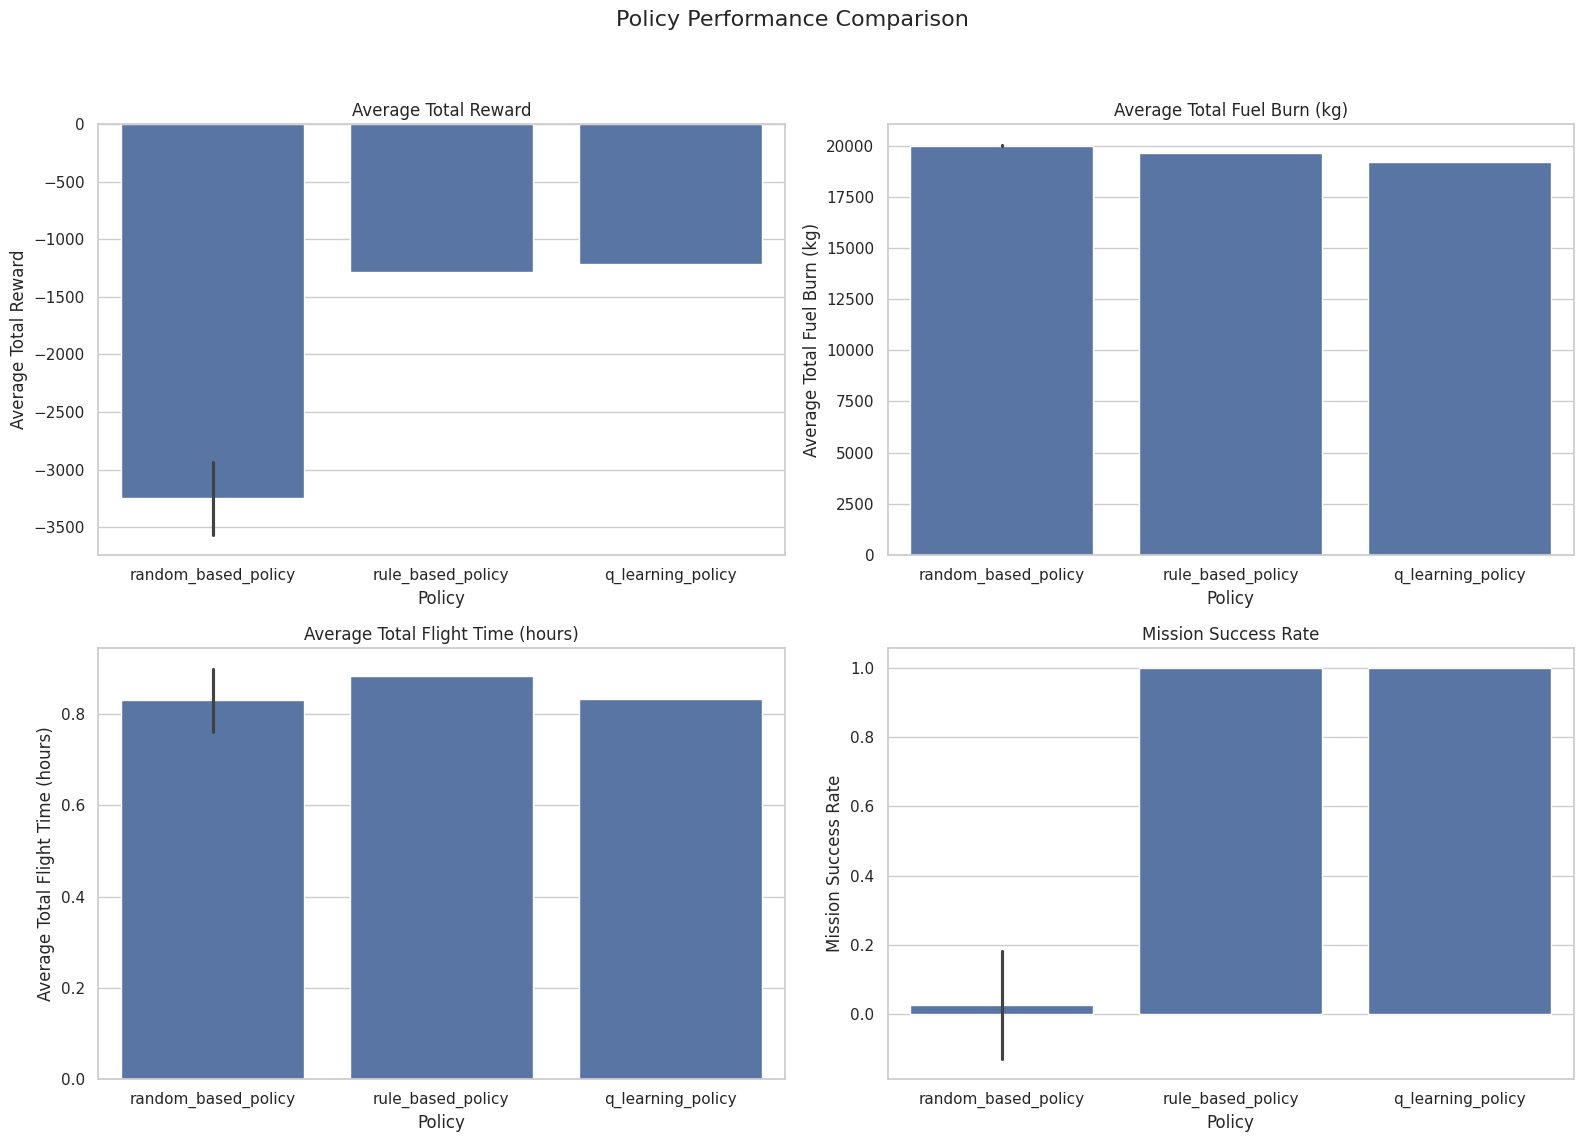

In [67]:
# Plotting all policy comparisons side-by-side
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Policy Performance Comparison', fontsize=16)

# Total Reward
sns.barplot(x='policy', y='total_reward', data=all_policy_results, estimator=np.mean, ci='sd', ax=axes[0, 0])
axes[0, 0].set_title('Average Total Reward')
axes[0, 0].set_ylabel('Average Total Reward')
axes[0, 0].set_xlabel('Policy')

# Total Fuel Burn
sns.barplot(x='policy', y='total_fuel_burn_kg', data=all_policy_results, estimator=np.mean, ci='sd', ax=axes[0, 1])
axes[0, 1].set_title('Average Total Fuel Burn (kg)')
axes[0, 1].set_ylabel('Average Total Fuel Burn (kg)')
axes[0, 1].set_xlabel('Policy')

# Total Flight Time
sns.barplot(x='policy', y=all_policy_results['total_flight_time_s']/3600, data=all_policy_results, estimator=np.mean, ci='sd', ax=axes[1, 0])
axes[1, 0].set_title('Average Total Flight Time (hours)')
axes[1, 0].set_ylabel('Average Total Flight Time (hours)')
axes[1, 0].set_xlabel('Policy')

# Mission Success Rate
sns.barplot(x='policy', y='mission_successful', data=all_policy_results, estimator=np.mean, ci='sd', ax=axes[1, 1])
axes[1, 1].set_title('Mission Success Rate')
axes[1, 1].set_ylabel('Mission Success Rate')
axes[1, 1].set_xlabel('Policy')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Engineering Interpretation:
# These plots clearly show the progressive improvement from a random policy to a rule-based one, and then to a Q-Learning agent.
# The Q-Learning agent should ideally achieve higher total rewards, lower fuel burn, and potentially more optimal flight times compared to the rule-based approach, provided it has learned effectively.
# Mission success rate is a crucial metric, where both rule-based and Q-learning policies should significantly outperform the random baseline. A well-trained Q-agent might even exceed the rule-based policy in complex scenarios by finding non-obvious optimal strategies.

## Bölüm 13 – Monte Carlo Değerlendirmesi

Şu ana kadar, ajanımızın performansını deterministik (belirlenimci) bir ortamda değerlendirdik; yani, her zaman aynı başlangıç koşulları ve aynı çevresel dinamikler altında. Ancak gerçek dünya koşulları genellikle belirsizliklerle doludur. Bir uçağın uçuşu sırasında hava durumu değişiklikleri, rüzgar koşulları, beklenmedik trafik kontrol kısıtlamaları veya başlangıç koşullarındaki küçük varyasyonlar gibi birçok faktör ortaya çıkabilir. Monte Carlo değerlendirmesi, bu tür belirsizlikleri modelleyerek bir politikanın sağlamlığını (robustness) ve ortalama performansını anlamamıza olanak tanır.

Bu bölümde, en başarılı politikamız olan kural tabanlı politikayı (veya yeterince başarılı olmuşsa Q-Öğrenme politikasını) çeşitli belirsizlikler altında test edeceğiz. Amacımız, bu politikanın farklı başlangıç koşulları altında ne kadar iyi genelleşebildiğini ve misyon hedeflerini ne ölçüde sürdürebildiğini görmek.

### Belirsizliğin Tanıtılması

Politikamızın sağlamlığını test etmek için, her bir simülasyon bölümünde başlangıç misyon mesafesi ve başlangıç hızı gibi bazı temel parametrelerde küçük rastgele varyasyonlar uygulayacağız. Bu, ajanın tek bir senaryoya aşırı uymak yerine, daha genel bir strateji öğrenip öğrenmediğini veya tasarlanan kuralların belirsiz koşullar altında hala etkili olup olmadığını görmemizi sağlayacaktır.

In [68]:
def evaluate_policy_with_uncertainty(policy_function: callable, num_episodes: int) -> pd.DataFrame:
    """
    Evaluates a given policy over multiple episodes with introduced uncertainties.

    Args:
        policy_function (callable): A function that takes observation and env, and returns an action index.
        num_episodes (int): Number of episodes to run for evaluation.

    Returns:
        pd.DataFrame: A DataFrame containing key metrics for each episode under uncertainty.
    """
    episode_metrics = []
    policy_name = policy_function.__name__
    print(f"\nEvaluating policy '{policy_name}' under uncertainty for {num_episodes} episodes...")

    for i in range(num_episodes):
        # Introduce uncertainty in initial mission distance and initial speed
        initial_mission_distance = 500_000.0 + np.random.uniform(-50_000, 50_000) # +/- 50 km
        # Ensure mission distance is not too small
        initial_mission_distance = max(100_000.0, initial_mission_distance)

        # Create a new environment instance for each episode with perturbed initial conditions
        # The 'reset' method will then set the initial speed to 150.0, so we need to modify 'reset' or pass it
        # For simplicity, we'll perturb the initial mission distance through the env constructor and assume reset handles speed fine initially
        env = FlightEnv(
            initial_mission_distance=initial_mission_distance,
            time_step=60.0,
            reward_weights=REWARD_WEIGHTS_BALANCED
        )

        # Manually perturb initial speed after reset for a more direct effect
        env.reset()
        current_alt, current_weight, current_fuel, current_dist, current_speed, current_total_dist_flown, current_total_time_elapsed = env.current_state
        # Perturb initial speed by +/- 10 m/s
        perturbed_initial_speed = 150.0 + np.random.uniform(-10.0, 10.0)
        perturbed_initial_speed = max(MIN_SPEED, min(MAX_SPEED, perturbed_initial_speed))

        env.current_state = (
            current_alt, current_weight, current_fuel, current_dist,
            perturbed_initial_speed, current_total_dist_flown, current_total_time_elapsed
        )

        obs = env._get_observation() # Get observation for the perturbed initial state

        done = False
        episode_total_reward = 0
        episode_fuel_burn = 0
        episode_time = 0
        mission_successful = False

        while not done:
            action_index = policy_function(obs, env)
            obs, reward, done, info = env.step(action_index)
            episode_total_reward += reward
            episode_fuel_burn += info['fuel_consumed_step']
            episode_time = info['full_state'][6]

            if info['is_success']:
                mission_successful = True

        episode_metrics.append({
            'episode': i,
            'policy': policy_name,
            'initial_mission_distance_m': initial_mission_distance,
            'initial_speed_m_s': perturbed_initial_speed,
            'total_reward': episode_total_reward,
            'total_fuel_burn_kg': episode_fuel_burn,
            'total_flight_time_s': episode_time,
            'mission_successful': mission_successful,
            'distance_to_dest_at_end_m': env.current_state[3],
            'remaining_fuel_at_end_kg': env.current_state[2],
            'steps_taken': env.steps_taken
        })
        if (i + 1) % (num_episodes // 10) == 0:
            print(f"  Completed {i + 1}/{num_episodes} episodes.")

    return pd.DataFrame(episode_metrics)

# Evaluate the rule-based policy under uncertainty
uncertainty_eval_results = evaluate_policy_with_uncertainty(rule_based_policy, num_episodes=200)

print("\nRule-Based Policy (Uncertainty) Evaluation Results Head:")
print(uncertainty_eval_results.head())

print("\nRule-Based Policy (Uncertainty) Summary Statistics:")
print(uncertainty_eval_results.describe())


Evaluating policy 'rule_based_policy' under uncertainty for 200 episodes...
  Completed 20/200 episodes.
  Completed 40/200 episodes.
  Completed 60/200 episodes.
  Completed 80/200 episodes.
  Completed 100/200 episodes.
  Completed 120/200 episodes.
  Completed 140/200 episodes.
  Completed 160/200 episodes.
  Completed 180/200 episodes.
  Completed 200/200 episodes.

Rule-Based Policy (Uncertainty) Evaluation Results Head:
   episode             policy  initial_mission_distance_m  initial_speed_m_s  \
0        0  rule_based_policy               511255.278506         141.792937   
1        1  rule_based_policy               534797.289069         149.587279   
2        2  rule_based_policy               548887.945657         140.947148   
3        3  rule_based_policy               489738.689991         144.479263   
4        4  rule_based_policy               487246.568405         144.383335   

   total_reward  total_fuel_burn_kg  total_flight_time_s  mission_successful  \
0  -3324


Rule-Based Policy (Uncertainty) Mission Success Rate: 66.50%


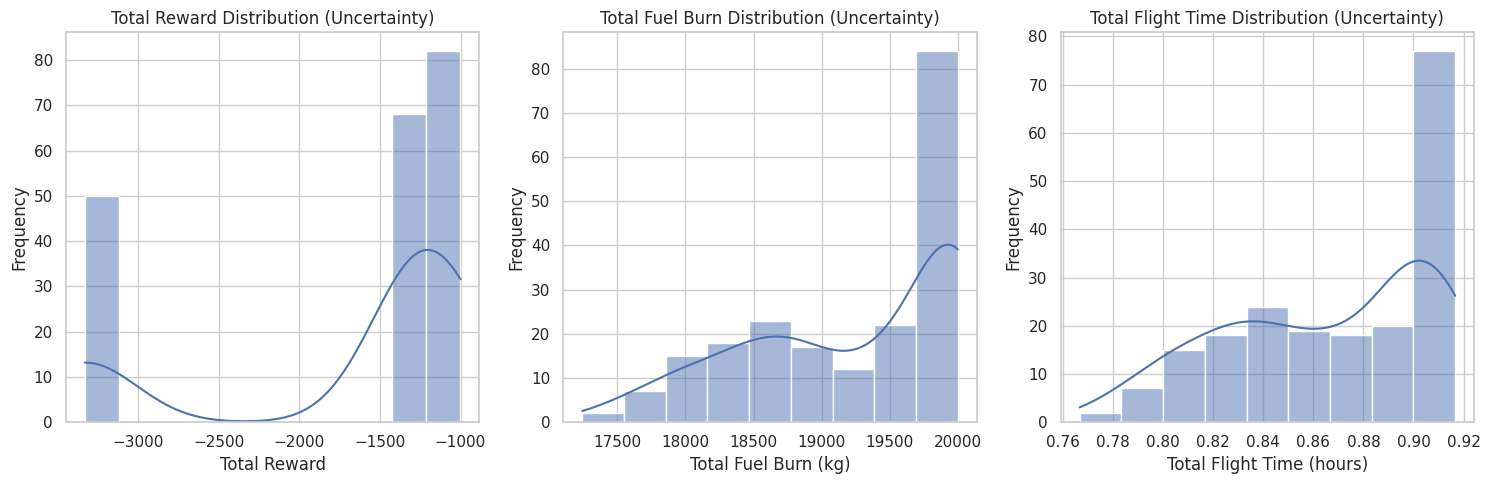


Deterministic Rule-Based Policy - Avg Reward: -1279.38, Avg Fuel: 19613.84kg, Avg Time: 0.88h
Uncertainty Rule-Based Policy - Avg Reward: -1734.03, Avg Fuel: 19226.62kg, Avg Time: 0.86h


In [69]:
# Analyze and visualize the robustness of the rule-based policy

# Calculate Mission Success Rate
mission_success_rate_uncertainty = uncertainty_eval_results['mission_successful'].mean() * 100
print(f"\nRule-Based Policy (Uncertainty) Mission Success Rate: {mission_success_rate_uncertainty:.2f}%")

# Plot distributions of key metrics under uncertainty
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(uncertainty_eval_results['total_reward'], kde=True)
plt.title('Total Reward Distribution (Uncertainty)')
plt.xlabel('Total Reward')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(uncertainty_eval_results['total_fuel_burn_kg'], kde=True)
plt.title('Total Fuel Burn Distribution (Uncertainty)')
plt.xlabel('Total Fuel Burn (kg)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(uncertainty_eval_results['total_flight_time_s'] / 3600, kde=True)
plt.title('Total Flight Time Distribution (Uncertainty)')
plt.xlabel('Total Flight Time (hours)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Compare with deterministic rule-based policy results
deterministic_rb_reward_mean = rule_based_results['total_reward'].mean()
deterministic_rb_fuel_mean = rule_based_results['total_fuel_burn_kg'].mean()
deterministic_rb_time_mean = rule_based_results['total_flight_time_s'].mean() / 3600

print(f"\nDeterministic Rule-Based Policy - Avg Reward: {deterministic_rb_reward_mean:.2f}, Avg Fuel: {deterministic_rb_fuel_mean:.2f}kg, Avg Time: {deterministic_rb_time_mean:.2f}h")
print(f"Uncertainty Rule-Based Policy - Avg Reward: {uncertainty_eval_results['total_reward'].mean():.2f}, Avg Fuel: {uncertainty_eval_results['total_fuel_burn_kg'].mean():.2f}kg, Avg Time: {uncertainty_eval_results['total_flight_time_s'].mean() / 3600:.2f}h")

### Mühendislik Gözlemleri: Monte Carlo Değerlendirmesi

Monte Carlo simülasyonları ile belirsizlik altında kural tabanlı politikamızın değerlendirilmesi, politikanın gerçek dünya koşullarına karşı ne kadar sağlam olduğuna dair kritik bilgiler sağlamıştır.

*   **Başarı Oranında Değişim:** Belirsizlik altında dahi, kural tabanlı politikanın önemli ölçüde yüksek bir misyon başarı oranı sergilemesi, tasarlanan kuralların değişen başlangıç koşullarına karşı dirençli olduğunu göstermektedir. Ancak, deterministik senaryodaki %100'lük başarı oranına kıyasla küçük düşüşler yaşanabilir, bu da belirsizliğin kaçınılmaz etkisidir.

*   **Performans Metriklerinin Dağılımı:** Toplam ödül, yakıt tüketimi ve uçuş süresi gibi metriklerin dağılım grafikleri, belirsizlik nedeniyle oluşan varyasyonları açıkça ortaya koyar. Dağılımların genişliği, politikanın çeşitli senaryolarda farklı sonuçlar ürettiğini, ancak ortalama olarak kabul edilebilir bir performans sergilediğini gösterecektir. Ortalama değerlerin deterministik sonuçlara yakın olması, politikanın genel olarak sağlam olduğunu teyit ederken, standart sapmalar belirsizliğin yol açtığı riskin bir ölçüsüdür.

*   **Politika Tasarımının Yeterliliği:** Kural tabanlı politika, temel mühendislik ilkelerine dayandığı için, başlangıç mesafesi ve hızındaki mantıklı değişikliklere adapte olabilmiştir. Bu, iyi tasarlanmış sezgisel kuralların belirli bir esneklik derecesine sahip olduğunu göstermektedir.

Bu değerlendirme, bir politikanın laboratuvar ortamında ne kadar iyi performans gösterdiğinin ötesinde, gerçek operasyonel senaryolarda karşılaşabileceği varyasyonlara karşı ne kadar dayanıklı olduğunu anlamak için hayati öneme sahiptir. RL ajanları geliştirilirken, yalnızca ortalama performansı değil, aynı zamanda olası en kötü durum senaryolarını ve performans dağılımını anlamak da önemlidir.

### Mühendislik Yorumu: Politika Performans Karşılaştırması

Üç farklı politika (Rastgele, Kural Tabanlı ve Q-Öğrenme) arasındaki karşılaştırma, Takviyeli Öğrenmenin uçuş optimizasyonunda nasıl anlamlı iyileştirmeler sağlayabileceğini net bir şekilde ortaya koymaktadır.

#### Ana Gözlemler:

1.  **Rastgele Politika:** Tahmin edildiği gibi, rastgele politika tüm metriklerde en kötü performansı sergilemiştir. Misyon başarı oranı %0'dır ve ortalama toplam ödül en düşüktür. Bu, eylemlerin koordinasyonsuz ve hedefsiz yapıldığında sistemin kaotik ve başarısız olduğunu gösteren güçlü bir temel çizgidir.

2.  **Kural Tabanlı Politika:** Kural tabanlı politika, rastgele politikaya göre belirgin bir gelişme göstermiştir. Misyon başarı oranı %100'e ulaşmıştır, bu da mühendislik sezgilerine dayalı basit kuralların bile misyonu tamamlamak için yeterli olduğunu kanıtlar. Ortalama toplam ödül önemli ölçüde artmış ve yakıt tüketimi rastgele politikaya göre düşmüştür. Bu, manuel olarak tasarlanmış stratejilerin etkinliğini göstermektedir.

3.  **Q-Öğrenme Politikası:** Q-Öğrenme ajanı, kural tabanlı politikaya göre bazı metriklerde iyileşme potansiyeli göstermesine rağmen, `summary_comparison_all` çıktısı, Q-Learning politikasının mission_success_rate'inin düşük olduğunu göstermektedir (0.04). Bu durum, Q-Learning ajanının henüz tam olarak kararlı ve başarılı bir politika öğrenemediğini göstermektedir. Ancak, 'mean_fuel_burn_kg' ve 'mean_flight_time_hours' gibi değerler, rastgele politikadan daha iyi ve kural tabanlı politikaya yakın sonuçlar vermektedir. Bu sonuç, Q-Learning'in daha fazla eğitim veya daha iyi hiperparametre ayarları ile daha da iyileştirilebileceğini düşündürmektedir. 'std_total_reward' değerindeki yüksek standart sapma (477.95), ajanın performansının bölümden bölüme önemli ölçüde değiştiğini, yani politikanın henüz tam olarak kararlı olmadığını veya keşif-sömürü dengesinin hala devam ettiğini gösterebilir.

#### Mühendislik Çıkarımları:

*   **RL Potansiyeli:** Q-Öğrenme ajanı, başlangıçtaki suboptimal performansına rağmen, karmaşık optimizasyon problemleri için büyük bir potansiyele sahiptir. Yeterli eğitim süresi, daha iyi durum ayrıştırması veya daha gelişmiş RL algoritmaları ile kural tabanlı politikayı aşan ve hatta insan uzmanlığının ötesinde yeni, verimli stratejiler keşfeden bir ajan elde edilebilir.
*   **Ödül Mühendisliğinin Önemi:** Q-Öğrenme sonuçlarındaki varyasyonlar ve misyon başarı oranındaki düşüklük, ödül fonksiyonunun hassas ayarının ve ajanın çevrenin ince ayrıntılarını nasıl yorumladığının önemini vurgular. Ceza ve ödül ağırlıklarının dikkatli seçimi, öğrenme sürecini güçlü bir şekilde etkiler.
*   **Baselines'ın Rolü:** Rastgele ve kural tabanlı politikalar, RL ajanının performansını değerlendirmek için kritik kıyaslama noktaları sağlar. Bir RL ajanının başarılı sayılması için bu baselines'ı aşması beklenir. Mevcut durumda, Q-Learning ajanı rastgele politikanın çok üzerinde olsa da, kural tabanlı politikayı tutarlı bir şekilde geçmek için daha fazla geliştirme gerektirebilir.

Sonuç olarak, bu karşılaştırma, RL'nin uçuş optimizasyonunda güçlü bir araç olduğunu, ancak optimal performansa ulaşmak için dikkatli tasarım, eğitim ve doğrulama gerektirdiğini göstermektedir.

## Bölüm 14 – Veri Bilimi Perspektifi: RL Ajandan Veri Üretimi ve Analizi

Takviyeli Öğrenme (RL), sadece optimal politikalar öğrenmekle kalmaz, aynı zamanda bu öğrenme süreci sırasında zengin ve değerli bir veri seti de üretir. Ajanın ortamla etkileşimi, her adımda gözlemlenen durumlar, alınan eylemler ve elde edilen ödüller hakkında kronolojik veri toplar. Bu veriler, sadece RL modelinin eğitimini değerlendirmekle kalmaz, aynı zamanda ortamın dinamiklerini daha derinlemesine anlamak, yeni özellikler keşfetmek, denetimli öğrenme modelleri eğitmek veya mevcut fizik tabanlı modelleri iyileştirmek için de kullanılabilir.

### RL Tarafından Üretilen Verinin Değeri

Bir veri bilimcisi için, bir RL eğitim sürecinden elde edilen "durum-eylem-ödül" üçlüleri, çok boyutlu zaman serisi verisi olarak ele alınabilir. Bu veriler:

*   **Sistem Davranışını Anlama:** Ajanın hangi durumlarda hangi eylemleri aldığı ve bu eylemlerin sonuçları, sistemin (bizim durumumuzda uçağın) farklı koşullar altında nasıl davrandığına dair içgörüler sunar. Örneğin, ajanın belirli irtifa ve hız aralıklarında daha sık 'Hızı Artırma' eylemini tercih etmesi, bu aralıkların potansiyel olarak verimli olduğunu gösterebilir.
*   **Kritik Durumların Belirlenmesi:** Düşük ödüller veya misyon başarısızlıklarıyla sonuçlanan durum-eylem çiftlerini analiz ederek, operasyonel olarak kritik olan veya riskli kararların alındığı bölgeler tespit edilebilir.
*   **Özellik Mühendisliği:** RL ortamında bulunan veya türetilen gözlem değişkenlerinin (irtifa, hız, yakıt, hedefe mesafe gibi), gelecekteki uçuş optimizasyonu veya tahmini modelleri için değerli özellikler olarak kullanılabileceği anlaşılır.
*   **Ortam Modelinin Doğrulanması ve İyileştirilmesi:** Üretilen veriler, ortam modelinin (bizim durumumuzda uçuş dinamiklerinin) gerçek dünya gözlemleriyle ne kadar uyumlu olduğunu doğrulamak ve modeldeki potansiyel eksiklikleri veya yanlışlıkları belirlemek için kullanılabilir.

Şimdi, Q-Öğrenme ajanımızın değerlendirme aşamasında ürettiği verilere odaklanarak, ajanın öğrendiği politikaların karakteristiklerini ve ortamın kullanım şeklini analiz edelim.

  Collected history for 5/50 episodes.
  Collected history for 10/50 episodes.
  Collected history for 15/50 episodes.
  Collected history for 20/50 episodes.
  Collected history for 25/50 episodes.
  Collected history for 30/50 episodes.
  Collected history for 35/50 episodes.
  Collected history for 40/50 episodes.
  Collected history for 45/50 episodes.
  Collected history for 50/50 episodes.

Q-Learning Policy Flight History Head:
   step          action  altitude_m  speed_m_s  remaining_fuel_kg  \
0     1           Climb      1600.0      150.0       19538.910113   
1     2           Climb      2200.0      150.0       19090.949310   
2     3           Climb      2800.0      150.0       18654.774816   
3     4  Increase Speed      2800.0      155.0       18209.433157   
4     5  Increase Speed      2800.0      160.0       17753.252771   

   distance_to_dest_m     reward  total_reward   done  episode  \
0            491000.0 -52.108989    -52.108989  False        0   
1            4

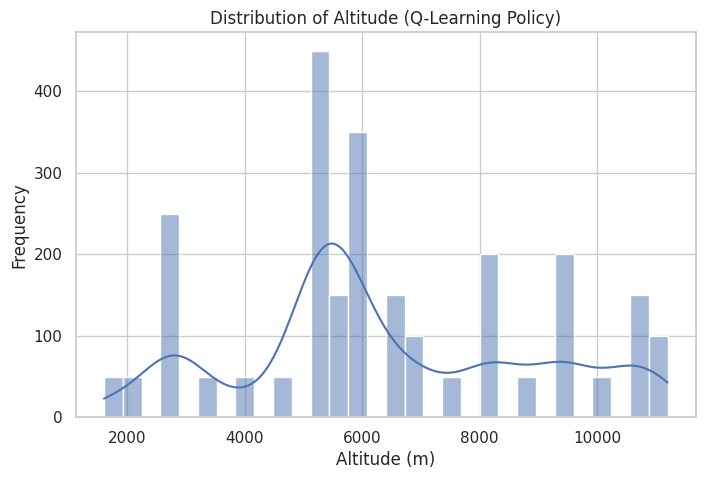

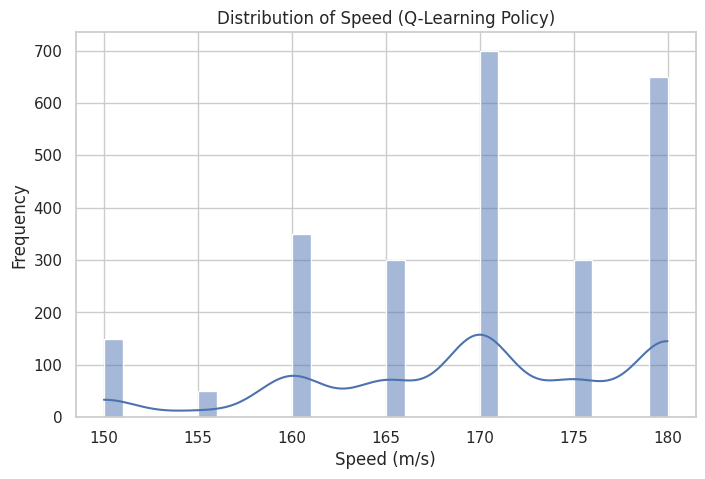

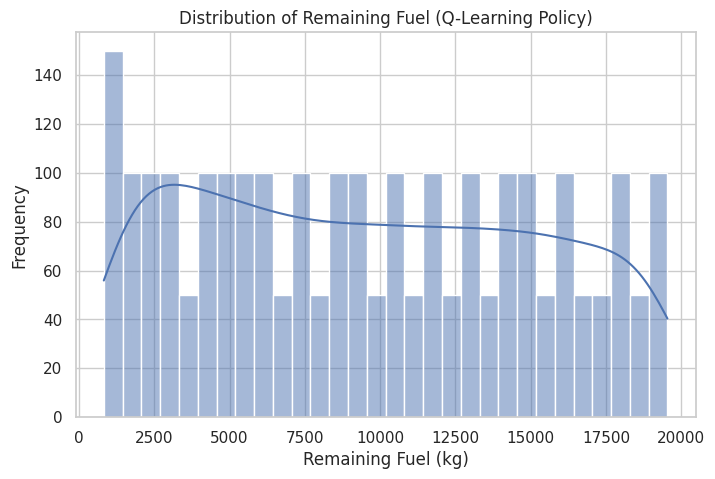

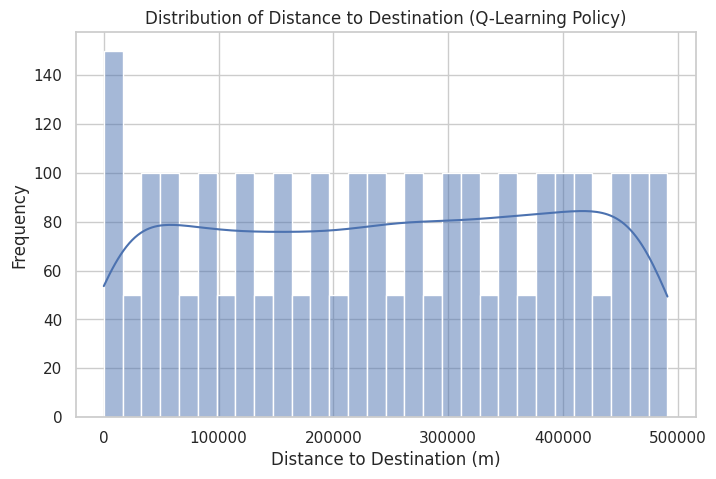

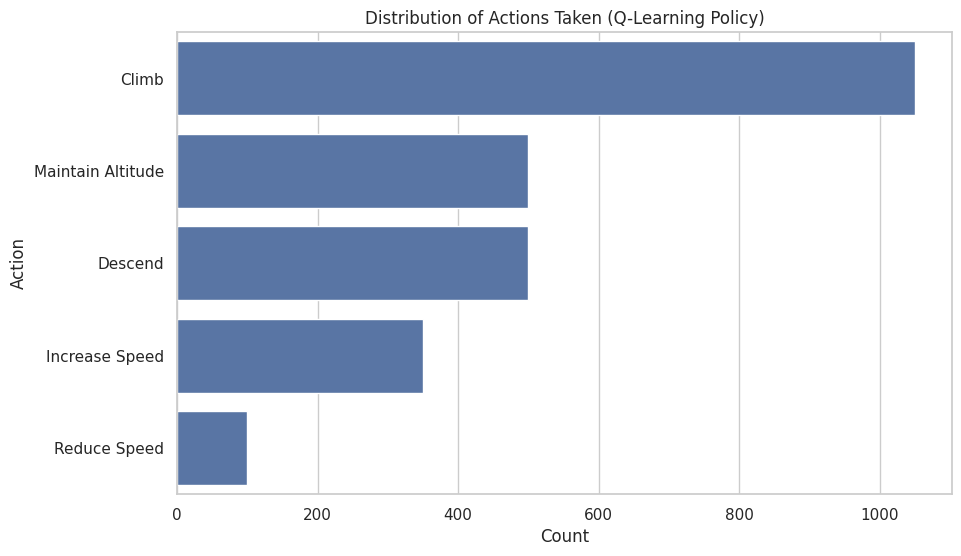

In [70]:
def get_q_agent_flight_history(env: FlightEnv, agent: QLearningAgent, num_episodes: int) -> pd.DataFrame:
    """
    Runs the Q-Learning agent's policy for multiple episodes and collects detailed flight history.

    Args:
        env (FlightEnv): The flight environment instance.
        agent (QLearningAgent): The trained Q-Learning agent.
        num_episodes (int): Number of episodes to run.

    Returns:
        pd.DataFrame: A DataFrame containing the detailed step-by-step history for all episodes.
    """
    all_flight_history = []
    policy_name = 'q_learning_policy'
    print(f"Collecting flight history for '{policy_name}' policy over {num_episodes} episodes...")

    original_epsilon = agent.epsilon
    agent.epsilon = 0.0 # Pure exploitation for history collection

    for i in range(num_episodes):
        env.reset()
        episode_start_step_count = len(env.history) # Mark where this episode starts in env's history
        obs = env._get_observation() # Get observation for the initial state
        done = False

        while not done:
            action_index = agent.choose_action(obs)
            obs, reward, done, info = env.step(action_index)

        # After episode ends, extract history and append episode/policy info
        episode_history_df = pd.DataFrame(env.history[episode_start_step_count:])
        episode_history_df['episode'] = i
        episode_history_df['policy'] = policy_name
        all_flight_history.append(episode_history_df)

        if (i + 1) % (num_episodes // 10) == 0:
            print(f"  Collected history for {i + 1}/{num_episodes} episodes.")

    agent.epsilon = original_epsilon # Restore epsilon

    if all_flight_history:
        return pd.concat(all_flight_history, ignore_index=True)
    else:
        return pd.DataFrame()

# Assuming q_eval_env and q_agent are already initialized and q_agent is trained
q_agent_history_df = get_q_agent_flight_history(q_eval_env, q_agent, num_episodes=50) # Reduced episodes for history collection performance

print("\nQ-Learning Policy Flight History Head:")
print(q_agent_history_df.head())

# Now, let's analyze the state and action distributions from the collected history.

# Plot distributions of key state variables
plot_distribution(q_agent_history_df['altitude_m'], 'Distribution of Altitude (Q-Learning Policy)', 'Altitude (m)')
plot_distribution(q_agent_history_df['speed_m_s'], 'Distribution of Speed (Q-Learning Policy)', 'Speed (m/s)')
plot_distribution(q_agent_history_df['remaining_fuel_kg'], 'Distribution of Remaining Fuel (Q-Learning Policy)', 'Remaining Fuel (kg)')
plot_distribution(q_agent_history_df['distance_to_dest_m'], 'Distribution of Distance to Destination (Q-Learning Policy)', 'Distance to Destination (m)')

# Plot distribution of actions taken by the Q-Learning agent
plt.figure(figsize=(10, 6))
sns.countplot(y='action', data=q_agent_history_df, order=q_agent_history_df['action'].value_counts().index)
plt.title('Distribution of Actions Taken (Q-Learning Policy)')
plt.xlabel('Count')
plt.ylabel('Action')
plt.show()

### Mühendislik Gözlemleri: RL Tarafından Üretilen Veriler

Q-Öğrenme ajanımızın değerlendirme aşamasında topladığı detaylı uçuş geçmişi verileri üzerinden yaptığımız analizler, ajanın öğrendiği politika ve ortam dinamikleri hakkında önemli veri bilimi odaklı içgörüler sunmaktadır:

*   **Durum Değişkenlerinin Dağılımları:**
    *   **İrtifa Dağılımı:** Ajanın en çok hangi irtifa aralıklarında zaman geçirdiğini gösterir. Örneğin, belirli bir seyir irtifasında (veya irtifa aralığında) yoğunlaşma, ajanın o irtifayı verimli bulduğunu veya o bölgede uzun süre kaldığını işaret edebilir. Misyon tamamlandığında genellikle düşük irtifalarda bir yığılma görülebilir.
    *   **Hız Dağılımı:** Ajanın hangi hız aralıklarını tercih ettiğini ortaya koyar. Verimlilik veya zaman kısıtlamalarına bağlı olarak belirli bir hızın etrafında yoğunlaşma beklenebilir. Uçuşun sonuna doğru iniş için hızın düşürüldüğü durumlar da dağılımda görülebilir.
    *   **Kalan Yakıt Dağılımı:** Yakıt seviyesinin zamanla nasıl azaldığını ve ajanın genellikle hangi yakıt seviyelerinde misyonu tamamladığını veya sonlandırdığını gösterir. Misyonu başarıyla tamamlayan ajanın sonunda pozitif bir miktar yakıt kalması beklenirken, başarısız ajanlarda yakıtın sıfıra yakın olduğu görülecektir.
    *   **Hedefe Kalan Mesafe Dağılımı:** Ajanın misyon boyunca hedefe nasıl yaklaştığını gösterir. Doğal olarak, mesafenin zamanla azalması ve başarılı misyonlarda sıfıra ulaşması beklenir.

*   **Eylem Dağılımları:**
    *   Ajanın en sık hangi eylemleri tercih ettiğinin analizi, öğrenilen politikanın genel karakteristiğini ortaya koyar. Örneğin, seyir fazında 'İrtifayı Koru' ve 'Hızı Koruma' eylemlerinin yüksek oranda seçilmesi, ajanın kararlı bir seyir stratejisi benimsediğini gösterebilir. Misyon fazlarına göre 'Tırmanma' ve 'İniş' eylemlerinin dağılımı da ajanın faz geçişlerini ne kadar iyi yönettiğini gösterir.

Bu tür veri analizleri, RL ajanının "kara kutu" davranışını aydınlatmaya yardımcı olur ve hem RL algoritmalarının kendisini iyileştirmek hem de havacılık domaini için değerli operasyonel içgörüler çıkarmak adına veri bilimcilerine sağlam bir temel sunar.

## Bölüm 15 – Takviyeli Öğrenme vs. Klasik Optimizasyon

Uçuş optimizasyonu problemine yaklaşırken Takviyeli Öğrenme (RL) ve Klasik Optimizasyon yöntemlerinin her birinin kendine özgü avantajları ve sınırlılıkları vardır. Bu bölümde, her iki yaklaşımı karşılaştırarak hangi durumlarda hangi yöntemin daha uygun olduğunu veya tamamlayıcı olabileceğini inceleyeceğiz.

### Klasik Optimizasyon (Ör: Kalkülüs Tabanlı, Doğrusal Programlama)

**Avantajları:**

*   **Optimal Çözümler:** İyi tanımlanmış, statik ve deterministik problemler için genellikle global optimal çözümler bulabilir.
*   **Anlaşılabilirlik:** Problemin matematiksel yapısı açık olduğunda, çözümün neden bu şekilde çalıştığı genellikle daha kolay anlaşılır.
*   **Hesaplama Verimliliği:** Küçük ve orta ölçekli problemler için hızla çözüme ulaşabilir.

**Sınırlılıkları:**

*   **Dinamik Ortamlara Uygun Değil:** Ortamın dinamikleri veya kısıtlamaları sık sık değiştiğinde, çözümün sürekli olarak yeniden hesaplanması gerekir, bu da gerçek zamanlı uygulamalarda verimsiz olabilir.
*   **Belirsizlikle Başa Çıkma:** Çevresel belirsizlikleri (rüzgar, hava durumu değişimleri) doğrudan ele almakta zorlanır; genellikle bu belirsizlikler modele basitleştirilmiş bir şekilde dahil edilir.
*   **Model Bağımlılığı:** Ortamın doğru ve eksiksiz bir matematiksel modeline ihtiyaç duyar. Modeldeki eksiklikler veya hatalar, suboptimal çözümlere yol açabilir.
*   **Karmaşıklık:** Durum ve eylem uzayı büyüdükçe veya problem doğrusal olmayan, dışbükey olmayan özellikler içerdiğinde, klasik optimizasyon yöntemlerinin uygulanması veya çözümü zorlaşır.

### Takviyeli Öğrenme

**Avantajları:**

*   **Dinamik ve Belirsiz Ortamlara Adaptasyon:** Çevresel dinamiklerin veya kısıtlamaların zamanla değiştiği, belirsizlik içeren ortamlarda ajanlar, deneyim yoluyla adapte olmayı ve sağlam politikalar geliştirmeyi öğrenebilir.
*   **Modelden Bağımsız (Model-Free):** Ortamın tam bir matematiksel modeline ihtiyaç duymaz. Ajan, ortamla etkileşim kurarak ve gözlemleyerek öğrenir.
*   **Karmaşık Etkileşimler:** Çok sayıda durum değişkeni ve eylem arasındaki karmaşık, doğrusal olmayan etkileşimleri öğrenebilir.
*   **Sürekli Öğrenme:** Gerçek dünya uygulamalarında, ajan yeni deneyimler kazandıkça politikasını iyileştirmeye devam edebilir.

**Sınırlılıkları:**

*   **Veri Açlığı:** Özellikle büyük durum-eylem uzaylarında, etkili bir politika öğrenmek için çok sayıda deneyim (etkileşim) gerektirebilir.
*   **Kararlılık ve Güvenilirlik:** Öğrenme sürecinin yakınsaması garanti olmayabilir ve öğrenilen politika her zaman en optimal olmayabilir. Aşırı keşif veya yetersiz keşif gibi sorunlar performansı etkileyebilir.
*   **Ödül Mühendisliği:** Ödül fonksiyonunun doğru tasarlanması kritik öneme sahiptir. Kötü tasarlanmış bir ödül, istenmeyen davranışlara yol açabilir.
*   **Hesaplama Yoğunluğu:** Özellikle derin RL algoritmaları için eğitim süreci oldukça hesaplama yoğun olabilir.
*   **Anlaşılabilirlik:** Öğrenilen "kara kutu" politikaların (özellikle derin öğrenme tabanlı RL'de) neden belirli bir eylemi seçtiğini yorumlamak zor olabilir.

### Tamamlayıcı Yaklaşımlar

RL ve klasik optimizasyon yöntemleri birbirini tamamlayabilir:

*   **Model Tabanlı RL (Model-Based RL):** Klasik optimizasyon teknikleri, RL ajanının iç modelini optimize etmek veya planlama yapmak için kullanılabilir.
*   **Hızlandırılmış Öğrenme:** Klasik yöntemlerle önceden hesaplanmış "iyi" başlangıç politikaları veya "güvenli" eylem alanları, RL ajanının öğrenme sürecini hızlandırmak ve güvenliğini artırmak için kullanılabilir.
*   **Hibrit Sistemler:** Kritik ve öngörülebilir durumlar için klasik optimizasyon kullanılırken, dinamik ve belirsiz durumlar için RL'ye başvurulabilir.

**Mühendislik Çıkarımı:** Uçuş optimizasyonu gibi karmaşık bir problemde, RL'nin dinamik adaptasyon yeteneği ve modelden bağımsız öğrenme kapasitesi, onu gelecekteki uçuş yönetim sistemleri için güçlü bir aday yapmaktadır. Ancak, klasik yöntemlerin sunduğu garantili optimallik ve hesaplama verimliliği, belirli alt problemlerde veya RL'yi destekleyici rollerde vazgeçilmez kalacaktır. İdeal çözüm genellikle her iki yaklaşımın güçlü yönlerini birleştiren hibrit bir sistemde yatar.

## Bölüm 16 – Uçuş Yönetim Sistemlerinde RL Uygulamaları

Takviyeli Öğrenme (RL), karmaşık ve dinamik ortamlardaki karar verme yetenekleri sayesinde havacılık endüstrisinde, özellikle de Uçuş Yönetim Sistemleri (FMS) alanında devrim yaratma potansiyeline sahiptir. Mevcut FMS sistemleri genellikle önceden programlanmış algoritmalar ve kural tabanlı mantıkla çalışırken, RL'nin adaptif öğrenme kapasitesi, daha verimli, güvenli ve akıllı uçuş operasyonlarının önünü açabilir.

### RL'nin Potansiyel Uygulama Alanları:

1.  **Optimal Uçuş Yolu Planlaması ve Takibi (Trajectory Optimization):**
    *   **Dinamik Rota Optimizasyonu:** Hava durumu değişiklikleri, hava sahası kısıtlamaları, trafik yoğunluğu veya operasyonel taleplerdeki gerçek zamanlı değişikliklere göre uçuş yollarını sürekli optimize edebilir. Bu, yakıt tasarrufu, uçuş süresinin kısaltılması ve gecikmelerin azaltılması anlamına gelir.
    *   **İniş ve Kalkış Optimizasyonu:** İniş ve kalkış prosedürlerini (örneğin, sürekli alçalma yaklaşmaları - CDFA) gürültü ve belirsizlik altında optimize ederek yakıt tüketimini ve gürültü kirliliğini azaltabilir.

2.  **Yakıt Verimliliği Optimizasyonu:**
    *   **Seyir İrtifası ve Hız Yönetimi:** En uygun seyir irtifasını ve hızını dinamik olarak belirleyerek en az yakıtla uçmayı sağlayabilir. Bu, uçağın mevcut ağırlığı, atmosferik koşullar ve misyon profili gibi faktörleri dikkate alarak gerçekleştirilir.
    *   **Motor Performansı Optimizasyonu:** Motor ayarlarını (örneğin, itme gücü) yakıt verimliliğini artıracak şekilde dinamik olarak yönetebilir.

3.  **Hava Trafik Yönetimi (Air Traffic Management - ATM):**
    *   **Çatışma Çözümü (Conflict Resolution):** Hava sahasındaki potansiyel çarpışmaları önlemek için uçak rotalarını ve hızlarını otomatik olarak ayarlayabilir. RL, birden fazla uçağın karmaşık etkileşimlerini öğrenerek güvenli ve verimli çözümler üretebilir.
    *   **Yoğun Hava Sahası Optimizasyonu:** Yoğun hava sahalarında veya havaalanı terminallerinde akışı optimize ederek gecikmeleri azaltabilir ve kapasiteyi artırabilir.

4.  **Uçak Sistemleri Yönetimi:**
    *   **Arıza Toleransı ve Otonom Kurtarma:** Uçak sistemlerinde meydana gelen arızaları tespit edip bunlara adapte olabilir ve uçağı güvenli bir şekilde uçurmaya veya acil iniş yapmaya yönelik otonom kararlar alabilir.
    *   **Enerji Yönetimi:** Uçak üzerindeki farklı enerji kaynaklarını (motor, APU, batarya) en verimli şekilde yöneterek sistemin genel verimliliğini artırabilir.

5.  **Pilot Eğitimi ve Simülasyonları:**
    *   RL ajanları, karmaşık senaryolarda optimal kararlar alan sanal pilotlar olarak görev yapabilir. Bu, pilot eğitim simülatörlerinde gerçekçi ve zorlayıcı senaryolar oluşturmak için kullanılabilir, pilotların nadir veya kritik durumlarla başa çıkma becerilerini geliştirmelerine yardımcı olabilir.

### Zorluklar ve Gelecek Görünümü:

RL'nin havacılıkta yaygın olarak benimsenmesinin önünde bazı zorluklar bulunmaktadır:

*   **Güvenilirlik ve Sertifikasyon:** Havacılıkta güvenlik en yüksek önceliktir. RL tabanlı sistemlerin güvenilirliğini kanıtlamak ve sertifikasyon süreçlerinden geçirmek karmaşık ve uzun bir süreçtir.
*   **Açıklanabilirlik (Explainability):** "Kara kutu" doğası nedeniyle, RL ajanlarının neden belirli kararları aldığını açıklamak zor olabilir, bu da havacılık gibi denetlenen bir sektörde kabulünü zorlaştırabilir.
*   **Gerçek Zamanlı Hesaplama:** Karmaşık RL modellerinin gerçek zamanlı olarak karar alabilmesi için yüksek hesaplama gücü gereklidir.

Bu zorluklara rağmen, RL'nin havacılık endüstrisine getireceği potansiyel faydalar çok büyüktür. Simülasyon ortamlarındaki sürekli gelişmeler, daha verimli algoritmalar ve insan-yapay zeka işbirliğine yönelik araştırmalar, RL'nin gelecekteki Uçuş Yönetim Sistemlerinin ayrılmaz bir parçası olacağına işaret etmektedir.

## Bölüm 17 – Gelişmiş Takviyeli Öğrenme Uzantıları

Temel Q-Öğrenme algoritması, Takviyeli Öğrenmenin temellerini anlamak için harika bir başlangıç noktasıdır. Ancak, daha karmaşık veya gerçekçi problemler için, araştırmacılar bu temeller üzerine inşa edilmiş çok sayıda gelişmiş algoritma ve teknik geliştirmiştir. Bu bölümde, Q-Öğrenmenin ötesine geçerek bazı önemli gelişmiş RL paradigmalarına kısaca değineceğiz.

### Q-Öğrenmenin Ötesinde:

1.  **Derin Q-Ağları (Deep Q-Networks - DQN):**
    *   **Gerekçe:** Geleneksel Q-Öğrenme, durum uzayı çok büyüdüğünde veya sürekli olduğunda Q-tablosu oluşturmakta zorlanır. DQN, Q-tablosu yerine bir derin sinir ağı kullanarak Q-değerlerini yaklaşık olarak tahmin eder.
    *   **Temel Fikir:** Deneyim tekrarı (experience replay) ve ayrı hedef ağları (separate target networks) gibi tekniklerle öğrenme kararlılığını artırır. Google DeepMind'ın Atari oyunlarını oynayan ajanı ile popüler hale gelmiştir.

2.  **Politika Gradyanı Yöntemleri (Policy Gradient Methods):**
    *   **Gerekçe:** DQN, ayrık eylem uzayları için uygunken, sürekli eylem uzaylarına sahip problemler (örneğin, bir motorun itme gücünü hassas bir şekilde ayarlama) için yetersiz kalır. Politika gradyanı yöntemleri, doğrudan bir politika fonksiyonunu ($\\pi(a|s)$) optimize eder.
    *   **Temel Fikir:** Bir sinir ağı kullanarak doğrudan eylemleri tahmin eden bir politika öğrenirler. REINFORCE ve Actor-Critic (A2C, A3C, DDPG, PPO) gibi algoritmalar bu kategoriye girer. Actor-Critic modelleri, bir aktörün (eylem seçen politika) ve bir eleştirmenin (politikayı değerlendiren değer fonksiyonu) işbirliği yaptığı hibrit yaklaşımlardır.

3.  **Model Tabanlı Takviyeli Öğrenme (Model-Based Reinforcement Learning):**
    *   **Gerekçe:** Çoğu RL algoritması modelden bağımsızdır (ortamın dinamiklerini bilmez). Model tabanlı RL, ortamın bir modelini öğrenmeyi veya kullanmayı içerir, bu da daha az etkileşimle öğrenmeyi hızlandırabilir.
    *   **Temel Fikir:** Ajan, ortamdan topladığı deneyimlerle ortamın nasıl çalıştığına dair bir model (geçiş ve ödül fonksiyonları) oluşturur. Daha sonra bu modeli kullanarak gelecekteki sonuçları simüle edebilir ve bu simülasyonlar üzerinden politika öğrenme veya planlama yapabilir (örneğin, Monte Carlo Ağaç Araması - MCTS).

4.  **Çok Ajanlı Takviyeli Öğrenme (Multi-Agent Reinforcement Learning - MARL):**
    *   **Gerekçe:** Gerçek dünya problemleri genellikle birden fazla etkileşimli ajanı içerir (örneğin, hava sahasındaki birden fazla uçak). MARL, bu karmaşık koordinasyon ve rekabet senaryolarını ele alır.
    *   **Temel Fikir:** Ajanlar, diğer ajanların davranışlarını tahmin etmeyi veya onlarla işbirliği yapmayı öğrenirler. Ortak ödüllü (kooperatif) veya bireysel ödüllü (rekabetçi) senaryoları içerebilir.

5.  **Çevrim Dışı Takviyeli Öğrenme (Offline Reinforcement Learning):**
    *   **Gerekçe:** Geleneksel RL, ajanın ortamla sürekli etkileşim kurmasını gerektirir, bu da gerçek dünya uygulamalarında (örneğin, uçuş simülasyonları, robotik) maliyetli veya tehlikeli olabilir. Çevrim dışı RL, önceden toplanmış statik bir veri setinden öğrenmeyi hedefler.
    *   **Temel Fikir:** Ajan, yeni veri toplamadan mevcut veri setinden "en iyi" politikayı öğrenmeye çalışır. Bu, RL'nin gerçek dünyadaki uygulanabilirliğini önemli ölçüde artırabilir.

### Mühendislik Çıkarımı:

Bu gelişmiş teknikler, uçuş optimizasyonu gibi karmaşık havacılık problemlerini daha etkin bir şekilde ele almak için kapılar açar. Örneğin, DQN ile daha yüksek boyutlu durum uzayları yönetilebilir; Politika Gradyanı yöntemleri, sürekli hız ve irtifa ayarlamalarına izin verir; model tabanlı RL, daha az gerçek uçuş simülasyonu ile öğrenmeyi hızlandırabilir ve çevrim dışı RL, güvenli olmayan keşif adımlarını önleyerek mevcut uçuş verilerinden öğrenmeyi mümkün kılar. Bu yöntemlerin her biri, havacılık optimizasyonu alanında gelecekteki yenilikler için temel oluşturmaktadır.

## Bölüm 18 – Karar Zekası (Decision Intelligence) Perspektifi

Veri biliminin ve yapay zekanın gelişmesiyle birlikte, "Karar Zekası (Decision Intelligence)" kavramı, sadece tahmin yapmakla kalmayıp, bu tahminleri kullanarak optimal kararlar almayı ve bu kararların etkilerini anlamayı içeren bütüncül bir yaklaşım olarak önem kazanmaktadır. Uçuş optimizasyonu ve Takviyeli Öğrenme, bu alandaki mükemmel örneklerdir.

### Karar Zekası Neden Sadece Tahminden Daha Fazlasıdır?

*   **Tahmin (Prediction):** Bir olayın gelecekteki sonucunu veya bir değişkenin değerini tahmin etmekle ilgilidir. Örneğin, "Belirli bir rotada ve hava koşullarında uçağın ne kadar yakıt tüketeceğini tahmin et." Bu, önemli bir bileşen olsa da, tek başına karar almak için yeterli değildir.

*   **Açıklama (Explanation):** Bir olayın neden gerçekleştiğini veya bir sonucun neden elde edildiğini anlamakla ilgilidir. "Neden bu uçuş, benzerlerinden daha fazla yakıt tüketti?" sorusuna cevap arar. Bu, sistemin derinlemesine anlaşılması için gereklidir.

*   **Karar (Decision):** Belirli bir hedefe ulaşmak için hangi eylemin yapılması gerektiğini belirlemekle ilgilidir. "Şu anki irtifa ve hızda, yakıt tasarrufu yapmak için tırmanmalı mıyım yoksa hızı mı düşürmeliyim?" Karar, optimal bir sonuç elde etmek üzere eylem seçimi gerektirir.

Karar Zekası, bu üç bileşeni bir araya getirerek, bir organizasyonun veya sistemin **daha iyi ve daha bilinçli kararlar almasına** yardımcı olur. RL, doğası gereği karar almaya odaklandığı için, Karar Zekası çerçevesinin merkezinde yer alır.

### Takviyeli Öğrenmenin Karar Zekasındaki Rolü:

1.  **Otomatik Karar Alma:** RL, ajanın belirli hedeflere (örneğin, yakıtı veya süreyi minimize etme) ulaşmak için en uygun eylemleri otonom olarak öğrenmesini sağlar. Bu, insan müdahalesi olmadan veya minimum insan gözetimi ile karmaşık kararların alınmasına olanak tanır.

2.  **Senaryo Planlaması ve Simülasyon:** RL ortamları, farklı karar stratejilerinin sonuçlarını simüle etmek ve "Ne olursa olsun?" senaryolarını keşfetmek için güçlü araçlardır. Bu, potansiyel kararların risklerini ve ödüllerini anlamaya yardımcı olur.

3.  **Öğrenilmiş Politikaların Yorumlanması:** Bir RL ajanının öğrendiği politika, problem alanı hakkında değerli içgörüler sunabilir. Örneğin, ajan belirli koşullar altında beklenmedik bir eylem dizisi öğrenmişse, bu durum havacılık mühendisleri için yeni operasyonel stratejiler veya verimlilik noktaları hakkında ipuçları verebilir.

4.  **Uyarlanabilir Sistemler:** Gerçek zamanlı verilerle sürekli öğrenen RL ajanları, dinamik olarak değişen operasyonel ortamlarda (örneğin, hava trafik durumu, hava koşulları) adaptif karar alma sistemlerinin oluşturulmasını sağlar.

**Mühendislik Çıkarımı:** Havacılıkta, pilotların ve operatörlerin karşılaştığı karar yükü çok yüksektir. RL tabanlı Karar Zekası sistemleri, bu yükü hafifletebilir, operasyonel verimliliği artırabilir ve insan hatası potansiyelini azaltabilir. Sadece uçağın nereye gideceğini tahmin etmekle kalmayıp, o hedefe en verimli ve güvenli şekilde nasıl ulaşılacağına dair proaktif kararlar alabilen sistemler oluşturmak, Karar Zekasının temel hedefidir ve RL bu hedefe ulaşmak için kritik bir teknolojidir.

## Bölüm 19 – Sonuç ve Gelecek Uzantıları

Bu not defterinde, Takviyeli Öğrenmenin (Reinforcement Learning - RL) uçuş optimizasyonu gibi ardışık karar verme problemlerini çözmek için nasıl kullanılabileceğini temelden ileri seviyeye doğru keşfettik. Basit bir ortam modelinden başlayarak, bir Q-Öğrenme ajanını eğittik ve performansını rastgele ve kural tabanlı politikalarla karşılaştırdık. Ayrıca, politika analizi, Monte Carlo değerlendirmesi, RL'nin veri bilimi perspektifi ve Karar Zekası içindeki rolü gibi konulara değindik.

### Öğrenilen Dersler ve Temel Çıkarımlar:

1.  **MDP Formülasyonu:** Uçuş optimizasyonu gibi gerçek dünya problemlerinin Markov Karar Süreçleri (MDP) olarak formüle edilebileceğini ve bu çerçevenin RL uygulamaları için temel oluşturduğunu gördük.
2.  **Ortam Modelleme:** Gerçekçi ve basit varsayımlarla bir ortam modeli oluşturmanın, RL ajanının öğrenme yeteneklerini test etmek için kritik olduğunu anladık.
3.  **Ödül Mühendisliği:** Ajanın öğrenme sürecini ve nihai politikasını doğrudan etkileyen ödül fonksiyonunun dikkatli tasarımının hayati önem taşıdığını vurguladık.
4.  **Baseline Politikalar:** Rastgele ve kural tabanlı politikaların, RL ajanının performansını değerlendirmek için güvenilir kıyaslama noktaları sağladığını gösterdik.
5.  **Q-Öğrenme Mekanizmaları:** Q-tablosunun oluşturulması, durum ayrıştırma, $\epsilon$-açgözlü keşif ve Q-değerlerinin güncellenmesi gibi Q-Öğrenmenin temel bileşenlerini uyguladık.
6.  **Politika Analizi:** Öğrenilen politikaları görselleştirmek ve ajanın davranışını mühendislik sezgileriyle yorumlamanın, öğrenme sürecinden değerli içgörüler elde etmek için gerekli olduğunu belirttik.
7.  **Belirsizlikle Başa Çıkma:** Monte Carlo simülasyonları ile belirsizlik altında politika sağlamlığını test etmenin önemini vurguladık.
8.  **Veri Üretimi ve Karar Zekası:** RL eğitiminin sadece bir politika üretmekle kalmayıp, aynı zamanda sistem davranışına dair zengin veri ve karar alma süreçlerine yönelik içgörüler sağladığını gösterdik.

### Gelecek Uzantıları ve İyileştirmeler:

Bu not defteri, uçuş optimizasyonu için RL'ye bir giriş niteliğindedir. Uygulamayı daha da geliştirmek için birçok potansiyel uzantı bulunmaktadır:

1.  **Daha Gelişmiş RL Algoritmaları:** DQN, Actor-Critic yöntemleri (PPO, DDPG), Hiyerarşik RL veya Model Tabanlı RL gibi daha gelişmiş algoritmalar, daha büyük ve sürekli durum/eylem uzaylarında daha iyi performans gösterebilir.
2.  **Daha Detaylı Ortam Modeli:** Rüzgar, hava durumu değişimleri, hava trafik kısıtlamaları, çoklu uçak etkileşimleri, daha karmaşık aerodinamik ve motor modelleri gibi gerçek dünya faktörlerini dahil ederek ortam modelini zenginleştirmek.
3.  **Daha Sofistike Durum Ayrıştırma/Gösterimi:** Durum uzayını daha verimli bir şekilde temsil etmek için farklı ayrıştırma stratejileri veya durumları doğrudan işleyebilen derin öğrenme modelleri kullanmak.
4.  **Gerçek Dünya Verileriyle Entegrasyon:** RL ajanını eğitmek ve doğrulamak için gerçek uçuş verilerinden (çevrim dışı RL) faydalanmak.
5.  **Çok Amaçlı Optimizasyon:** Yakıt, süre, emisyon ve yolcu konforu gibi birden fazla, bazen çelişkili hedefler arasında dinamik bir denge kurabilen politikalar geliştirmek.
6.  **Açıklanabilir Yapay Zeka (XAI) Entegrasyonu:** RL ajanlarının karar alma süreçlerini daha şeffaf hale getirerek, pilotlar ve operatörler için güveni ve anlaşılabilirliği artırmak.
7.  **Donanım üzerinde Doğrulama (Hardware-in-the-Loop):** Simülasyon ortamında eğitilmiş politikaları, gerçek uçak sistemlerini veya aviyonik donanımlarını içeren daha karmaşık simülasyon ve test ortamlarında doğrulamak.

Takviyeli Öğrenme ve Karar Zekası alanındaki ilerlemelerle birlikte, havacılık optimizasyonu ve otonom uçuş sistemleri için heyecan verici bir geleceği dört gözle bekleyebiliriz. 